# Canadian Road Sign Zero-Shot Classification Using Vision-Language Models

**An end-to-end, reproducible Google Colab pipeline**

---

This notebook evaluates how well modern vision-language models (VLMs) — CLIP, OpenCLIP and SigLIP —
classify Canadian road signs **without any supervised training on the target sign categories**.

It is a portfolio / research-style project. It contains:

| Stage | What happens |
|---|---|
| Data engineering | Automated, cached, resumable ingestion from documented public APIs |
| Provenance | Machine-readable licensing + access record for every source |
| Taxonomy | Explicit mapping from source labels → canonical categories → Canadian sign terminology |
| Methodology | **Class-disjoint** zero-shot protocol (not a random image split) |
| Modelling | CLIP / OpenCLIP / SigLIP zero-shot + a supervised CNN baseline |
| Evaluation | Top-k accuracy, macro/weighted F1, per-class metrics, confusion matrices |
| Rigour | Prompt selection on validation only, calibration analysis, bootstrap CIs, McNemar |
| Interpretation | Occlusion-sensitivity explanations, error galleries, robustness under perturbation |
| Delivery | Reusable `predict_road_sign()` inference function + Gradio app |

**Nothing in this notebook is hard-coded from imagination.** Every metric printed below is computed at
runtime from data downloaded at runtime. If a source is unavailable, the notebook says so, records it in
the provenance file, and falls back to the next documented source in an explicit hierarchy.

---

### How to run

1. `Runtime → Change runtime type → GPU` (T4 is enough; CPU also works, slower).
2. `Runtime → Run all`.
3. Optional: add a free Mapillary client token as a Colab secret named `MAPILLARY_ACCESS_TOKEN`
   (🔑 icon in the left sidebar) to unlock **genuine Canadian street-level imagery**. Without it the
   notebook automatically falls back to a public, unauthenticated image source and clearly relabels the
   experiment as *global imagery + Canadian-compatible taxonomy*.

No manual uploads of any kind are required.

## 1. Research Question

> **How accurately can modern vision-language models recognise Canadian road signs when the target sign
> categories are never used for supervised training or for model / prompt / threshold selection?**

Sub-questions:

1. Does a VLM's zero-shot accuracy depend more on the *model* (CLIP vs OpenCLIP vs SigLIP) or on the
   *text prompt strategy*?
2. Do richer, Canada-specific class descriptions beat bare class names?
3. How does zero-shot accuracy compare to a conventional supervised CNN — and is that comparison even
   fair?
4. Are VLM similarity scores usable as *confidence*, i.e. are they calibrated?
5. How brittle are the predictions under blur, low light, compression and occlusion?

## 2. Methodology — what "zero-shot" means here

A very common mistake in portfolio projects is to split images randomly into train/test, train nothing,
run CLIP on the test half, and call it "zero-shot". That measures nothing: CLIP never saw the training
half either, so the split is meaningless.

**This notebook uses a class-disjoint protocol.**

```
                     ┌────────────────────────────────────────┐
  ALL CATEGORIES ──► │ DEVELOPMENT CLASSES                    │
                     │   • supervised baseline training       │
                     │   • prompt template selection          │
                     │   • class-description selection        │
                     │   • model selection / thresholds       │
                     │   Train / Validation / Dev-Test        │
                     └────────────────────────────────────────┘
                     ┌────────────────────────────────────────┐
                     │ ZERO-SHOT CLASSES  (held out entirely) │
                     │   • never trained on                   │
                     │   • never used to pick a prompt        │
                     │   • never used to pick a model         │
                     │   • never used to tune a threshold     │
                     │   Zero-Shot Test only                  │
                     └────────────────────────────────────────┘
```

**Why class-disjoint and not merely image-disjoint?** Zero-shot classification is the claim that a model
can recognise a *category it was never supervised on*. If the category appears in your development data,
you can (consciously or not) tune prompts, thresholds and preprocessing until that category works — the
category is no longer unseen, only the pixels are. Holding out whole classes is the only split that makes
the claim testable. Group-aware splitting is used *within* the development classes so that the same
physical sign instance or capture sequence cannot straddle train and test.

**Caveat we state honestly up front:** VLM pre-training corpora are web-scale and undisclosed. They almost
certainly contain road-sign imagery, including Canadian signs. "Zero-shot" here means *no supervision and
no model-selection signal from the held-out classes in this pipeline* — it does **not** mean the
pre-trained encoder has never encountered a stop sign. That is a limitation of every zero-shot VLM paper
and is restated in the Limitations section.

## 3. Environment Setup

Detect hardware, install only what Colab does not already ship, and record an exact environment summary
for reproducibility.

In [1]:
# --- Environment detection -------------------------------------------------------------------------
import sys, os, platform, subprocess, importlib, json
from datetime import datetime, timezone

IN_COLAB = "google.colab" in sys.modules

print("Python           :", sys.version.split()[0])
print("Platform         :", platform.platform())
print("Running in Colab :", IN_COLAB)

# GPU information (nvidia-smi is only present when a GPU runtime is attached)
try:
    smi = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                          "--format=csv,noheader"], capture_output=True, text=True, timeout=30)
    print("GPU              :", smi.stdout.strip() if smi.returncode == 0 else "none detected")
except Exception as exc:                                            # nvidia-smi absent on CPU runtimes
    print("GPU              : none detected (%s)" % type(exc).__name__)

Python           : 3.12.13
Platform         : Linux-6.6.122+-x86_64-with-glibc2.35
Running in Colab : True
GPU              : Tesla T4, 15360 MiB, 580.82.07


In [2]:
# --- Dependency installation ----------------------------------------------------------------------
# Colab already ships torch, torchvision, numpy, pandas, matplotlib, seaborn, sklearn, scipy, PIL, tqdm.
# We only install what is genuinely missing, and we never reinstall on a warm runtime.

REQUIRED = {
    # import name        : pip spec
    "open_clip":          "open_clip_torch>=2.24.0",
    "transformers":       "transformers>=4.45.0",
    "datasets":           "datasets>=2.19.0",
    "gradio":             "gradio>=4.44.0",
    "mapbox_vector_tile": "mapbox-vector-tile>=2.0.1",   # decodes Mapillary detection polygons
}

def _missing(import_name: str) -> bool:
    try:
        importlib.import_module(import_name)
        return False
    except Exception:
        return True

to_install = [spec for mod, spec in REQUIRED.items() if _missing(mod)]

if to_install:
    print("Installing:", ", ".join(to_install))
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + to_install
    proc = subprocess.run(cmd, capture_output=True, text=True)
    print("pip exit code:", proc.returncode)
    if proc.returncode != 0:
        print(proc.stdout[-2000:]); print(proc.stderr[-2000:])
else:
    print("All dependencies already present — nothing to install.")

print("\nNote: if pip upgraded a package Colab had pre-imported, restart the runtime and re-run.")

Installing: open_clip_torch>=2.24.0, mapbox-vector-tile>=2.0.1
pip exit code: 0

Note: if pip upgraded a package Colab had pre-imported, restart the runtime and re-run.


In [3]:
# --- Core imports ---------------------------------------------------------------------------------
import io, math, random, hashlib, logging, warnings, base64, zipfile, textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance
from tqdm.auto import tqdm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["savefig.dpi"] = 160
matplotlib.rcParams["figure.autolayout"] = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"          # mixed precision only where it is safe and useful

print("torch      :", torch.__version__)
print("CUDA build :", torch.version.cuda)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))
    print("GPU memory : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
print("DEVICE     :", DEVICE)

torch      : 2.11.0+cu128
CUDA build : 12.8
CUDA avail : True
GPU        : Tesla T4
GPU memory : 15.6 GB
DEVICE     : cuda


## 4. Google Drive Mount & Project Directories

Drive is used as a **persistent cache**. Large downloads survive a runtime disconnect, so re-running the
notebook after a reconnect is cheap. If Drive is unavailable (e.g. running locally), the project falls
back to a local directory and the rest of the notebook is unaffected.

In [4]:
# --- Drive mount and project tree -----------------------------------------------------------------
USE_GOOGLE_DRIVE = True     # set False to keep everything on the ephemeral Colab disk

DRIVE_MOUNTED = False
if IN_COLAB and USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount("/content/drive", force_remount=False)
        DRIVE_MOUNTED = Path("/content/drive/MyDrive").exists()
    except Exception as exc:
        print("Drive mount failed (%s) — falling back to local storage." % exc)

if DRIVE_MOUNTED:
    PROJECT_ROOT = Path("/content/drive/MyDrive/canadian_road_sign_zero_shot")
elif IN_COLAB:
    PROJECT_ROOT = Path("/content/canadian_road_sign_zero_shot")
else:
    PROJECT_ROOT = Path.cwd() / "canadian_road_sign_zero_shot"

DIRS = {
    "data":        PROJECT_ROOT / "data",
    "raw":         PROJECT_ROOT / "data" / "raw",
    "processed":   PROJECT_ROOT / "data" / "processed",
    "cache":       PROJECT_ROOT / "cache",
    "models":      PROJECT_ROOT / "models",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "outputs":     PROJECT_ROOT / "outputs",
    "figures":     PROJECT_ROOT / "outputs" / "figures",
    "splits":      PROJECT_ROOT / "outputs" / "splits",
    "logs":        PROJECT_ROOT / "logs",
    "metadata":    PROJECT_ROOT / "metadata",
}
for _p in DIRS.values():
    _p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT   :", PROJECT_ROOT)
print("Persistent     :", DRIVE_MOUNTED)
for k, v in DIRS.items():
    print("  %-12s %s" % (k, v))

Mounted at /content/drive
PROJECT_ROOT   : /content/drive/MyDrive/canadian_road_sign_zero_shot
Persistent     : True
  data         /content/drive/MyDrive/canadian_road_sign_zero_shot/data
  raw          /content/drive/MyDrive/canadian_road_sign_zero_shot/data/raw
  processed    /content/drive/MyDrive/canadian_road_sign_zero_shot/data/processed
  cache        /content/drive/MyDrive/canadian_road_sign_zero_shot/cache
  models       /content/drive/MyDrive/canadian_road_sign_zero_shot/models
  checkpoints  /content/drive/MyDrive/canadian_road_sign_zero_shot/checkpoints
  outputs      /content/drive/MyDrive/canadian_road_sign_zero_shot/outputs
  figures      /content/drive/MyDrive/canadian_road_sign_zero_shot/outputs/figures
  splits       /content/drive/MyDrive/canadian_road_sign_zero_shot/outputs/splits
  logs         /content/drive/MyDrive/canadian_road_sign_zero_shot/logs
  metadata     /content/drive/MyDrive/canadian_road_sign_zero_shot/metadata


## 5. Configuration

Every knob lives here. `RUN_MODE="quick"` exercises the whole pipeline on a small dataset (minutes);
`RUN_MODE="full"` collects a larger dataset for the headline numbers.

In [5]:
# --- Central configuration ------------------------------------------------------------------------
RUN_MODE = "quick"          # "quick" (fast end-to-end smoke run) | "full" (final evaluation)

FORCE_REDOWNLOAD = False    # ignore cached raw downloads
REBUILD_CACHE    = False    # ignore cached embeddings / trained baseline
RANDOM_SEED      = 42

_MODE_PRESETS = {
    "quick": dict(MAX_IMAGES_PER_CLASS=60,  MAX_TOTAL_IMAGES=1200,   SUPERVISED_EPOCHS=4,
                  MAPILLARY_TILES_PER_CITY=4,  ROBUSTNESS_MAX_IMAGES=150, OCCLUSION_STRIDE=24),
    "full":  dict(MAX_IMAGES_PER_CLASS=400, MAX_TOTAL_IMAGES=8000,  SUPERVISED_EPOCHS=12,
                  MAPILLARY_TILES_PER_CITY=16, ROBUSTNESS_MAX_IMAGES=600, OCCLUSION_STRIDE=16),
}
assert RUN_MODE in _MODE_PRESETS, "RUN_MODE must be 'quick' or 'full'"
_P = _MODE_PRESETS[RUN_MODE]

MAX_IMAGES_PER_CLASS     = _P["MAX_IMAGES_PER_CLASS"]
MAX_TOTAL_IMAGES         = _P["MAX_TOTAL_IMAGES"]
SUPERVISED_EPOCHS        = _P["SUPERVISED_EPOCHS"]
MAPILLARY_TILES_PER_CITY = _P["MAPILLARY_TILES_PER_CITY"]
ROBUSTNESS_MAX_IMAGES    = _P["ROBUSTNESS_MAX_IMAGES"]
OCCLUSION_STRIDE         = _P["OCCLUSION_STRIDE"]

MIN_IMAGES_PER_CLASS = 12   # a class with fewer usable images is dropped (documented, not silent)
MIN_CROP_PIXELS      = 28   # reject sign crops smaller than this on the short side

BATCH_SIZE  = 32 if DEVICE == "cuda" else 8
NUM_WORKERS = 2
IMAGE_SIZE  = 224

# Vision-language models. Checked for availability at load time; failures degrade gracefully.
VLM_REGISTRY = {
    "clip":     dict(kind="hf_clip",    model_id="openai/clip-vit-base-patch32", pretrained=None),
    "openclip": dict(kind="open_clip",  model_id="ViT-B-32",  pretrained="laion2b_s34b_b79k"),
    "siglip":   dict(kind="hf_siglip",  model_id="google/siglip-base-patch16-224", pretrained=None),
}
SUPERVISED_BACKBONE = "resnet18"

# ---- The zero-shot hold-out. Declared HERE, before any data is seen, and never revised. ----
# Chosen for semantic and visual diversity (one regulatory octagon, two warning-triangle/diamond
# pictograms, one prohibition circle, one work-zone sign) and NOT because of any measured result.
ZERO_SHOT_CLASSES = ["stop", "pedestrian_crossing", "road_work", "wildlife_warning", "no_entry"]

# Geographic query regions used when Mapillary imagery is available (city, province, centre lon/lat).
CANADIAN_REGIONS = [
    ("Toronto",       "Ontario",           -79.3832, 43.6532),
    ("Montreal",      "Quebec",            -73.5673, 45.5019),
    ("Vancouver",     "British Columbia", -123.1207, 49.2827),
    ("Calgary",       "Alberta",          -114.0719, 51.0447),
    ("Ottawa",        "Ontario",           -75.6972, 45.4215),
    ("Quebec City",   "Quebec",            -71.2080, 46.8139),
    ("Edmonton",      "Alberta",          -113.4938, 53.5461),
    ("Winnipeg",      "Manitoba",          -97.1385, 49.8951),
    ("Halifax",       "Nova Scotia",       -63.5752, 44.6488),
    ("Victoria",      "British Columbia", -123.3656, 48.4284),
]

CONFIG = dict(
    run_mode=RUN_MODE, random_seed=RANDOM_SEED, device=DEVICE,
    max_images_per_class=MAX_IMAGES_PER_CLASS, max_total_images=MAX_TOTAL_IMAGES,
    min_images_per_class=MIN_IMAGES_PER_CLASS, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    supervised_epochs=SUPERVISED_EPOCHS, supervised_backbone=SUPERVISED_BACKBONE,
    vlm_registry=VLM_REGISTRY, zero_shot_classes=ZERO_SHOT_CLASSES,
    project_root=str(PROJECT_ROOT), drive_mounted=DRIVE_MOUNTED,
)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "vlm_registry"}, indent=2))

{
  "run_mode": "quick",
  "random_seed": 42,
  "device": "cuda",
  "max_images_per_class": 60,
  "max_total_images": 1200,
  "min_images_per_class": 12,
  "batch_size": 32,
  "image_size": 224,
  "supervised_epochs": 4,
  "supervised_backbone": "resnet18",
  "zero_shot_classes": [
    "stop",
    "pedestrian_crossing",
    "road_work",
    "wildlife_warning",
    "no_entry"
  ],
  "project_root": "/content/drive/MyDrive/canadian_road_sign_zero_shot",
  "drive_mounted": true
}


## 6. Reproducibility & Logging

Global seeds, deterministic kernels where they do not cost too much, and a log file written to Drive.

In [6]:
# --- Seeding and logging --------------------------------------------------------------------------
def set_global_seed(seed: int = RANDOM_SEED, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch, and request deterministic cuDNN kernels."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed()

LOG_PATH = DIRS["logs"] / ("run_%s.log" % datetime.now().strftime("%Y%m%d_%H%M%S"))
logger = logging.getLogger("crs")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")
_fh = logging.FileHandler(LOG_PATH, encoding="utf-8"); _fh.setFormatter(_fmt)
_sh = logging.StreamHandler(sys.stdout); _sh.setFormatter(_fmt); _sh.setLevel(logging.INFO)
logger.addHandler(_fh); logger.addHandler(_sh)
logger.propagate = False

logger.info("Log file: %s", LOG_PATH)
logger.info("Seed=%d | device=%s | run_mode=%s", RANDOM_SEED, DEVICE, RUN_MODE)

def env_summary() -> Dict[str, Any]:
    """Collect an exact, machine-readable environment fingerprint."""
    def _ver(mod):
        try:
            return importlib.import_module(mod).__version__
        except Exception:
            return "not installed"
    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "in_colab": IN_COLAB,
        "device": DEVICE,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "cuda": torch.version.cuda,
        "packages": {m: _ver(m) for m in
                     ["torch", "torchvision", "transformers", "open_clip", "datasets", "numpy",
                      "pandas", "sklearn", "scipy", "PIL", "matplotlib", "seaborn", "gradio"]},
    }

ENV = env_summary()
print(json.dumps(ENV["packages"], indent=2))

15:02:43 | INFO    | Log file: /content/drive/MyDrive/canadian_road_sign_zero_shot/logs/run_20260808_150243.log
15:02:43 | INFO    | Seed=42 | device=cuda | run_mode=quick
{
  "torch": "2.11.0+cu128",
  "torchvision": "0.26.0+cu128",
  "transformers": "5.13.1",
  "open_clip": "3.3.0",
  "datasets": "4.0.0",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "sklearn": "1.6.1",
  "scipy": "1.16.3",
  "PIL": "11.3.0",
  "matplotlib": "3.10.0",
  "seaborn": "0.13.2",
  "gradio": "6.20.0"
}


## 7. Data Sources, Licensing & Provenance

Before writing any ingestion code we state exactly which sources exist, which are automatable, and under
what terms. Findings from checking the current official documentation (August 2026):

| Source | Type | Automatable? | Notes |
|---|---|---|---|
| **Mapillary Traffic Sign Dataset (MTSD)** | 100k annotated street-level images, >300 sign classes | ❌ | The research edition is distributed from `mapillary.com/dataset/trafficsign` behind an account + licence acceptance form. There is no documented unauthenticated download endpoint, so an automated notebook cannot legitimately fetch it. **We do not fake this.** |
| **Mapillary Graph API v4** | Live street-level imagery + traffic-sign map features & detections | ✅ (free token) | `graph.mapillary.com` — documented endpoints for `map_features`, `/{id}/detections` (base64 polygon, extent 4096) and image thumbnails. Requires a free client access token. This is our route to **genuine Canadian imagery**. |
| **GTSRB (German Traffic Sign Recognition Benchmark)** mirrored on the Hugging Face Hub | 43-class cropped sign images | ✅ (no auth) | Public, unauthenticated, one-line ingestion. **German** imagery — used only for the *Canadian-compatible taxonomy on global imagery* experiment, never presented as Canadian. |
| **Ville de Montréal / Données Québec — "Panneaux de signalisation"** | Geospatial sign inventory + RPA sign codification | ✅ (CKAN API) | A *point inventory and code catalogue*, **not** a photographic dataset. Used purely to ground the Canadian sign taxonomy in an official Canadian source. |

**Fallback hierarchy actually implemented below:**

```
1. Mapillary Graph API v4  (Canadian bounding boxes)   → Experiment A: Canadian imagery
        ↓ token absent / API error / too few images
2. Hugging Face public mirror of GTSRB                 → Experiment B: global imagery
        ↓ hub unreachable
3. Secondary Hugging Face GTSRB mirror
        ↓
4. Graceful, explicit failure (no synthetic substitute is ever used)
```

The notebook prints exactly which tier was used. Credentials are read from Colab secrets or environment
variables only — nothing is embedded in this file.

In [7]:
# --- Provenance register --------------------------------------------------------------------------
ACCESS_DATE = datetime.now(timezone.utc).date().isoformat()
PROVENANCE: List[Dict[str, Any]] = []

def record_source(name: str, organization: str, url: str, license_name: str, license_verified: bool,
                  attribution: str, intended_use: str, data_type: str, limitations: str,
                  status: str, notes: str = "") -> None:
    """Append one dataset/source to the machine-readable provenance register."""
    PROVENANCE.append(dict(
        dataset_name=name, organization=organization, url=url, access_date=ACCESS_DATE,
        license=license_name, license_verified=license_verified, attribution_requirements=attribution,
        intended_use=intended_use, data_type=data_type, data_limitations=limitations,
        status=status, notes=notes,
    ))

record_source(
    "Mapillary Traffic Sign Dataset (MTSD)", "Mapillary / Meta",
    "https://www.mapillary.com/dataset/trafficsign",
    "Research / commercial editions under Mapillary dataset licence (acceptance required)",
    False,
    "Attribution to Mapillary required by the dataset licence",
    "Intended primary source for annotated traffic-sign imagery",
    "annotated street-level images",
    "No documented unauthenticated download endpoint; requires an account and licence acceptance, "
    "so it cannot be ingested by an automated notebook.",
    "NOT USED - not automatable",
    notes="Documented rather than faked. Listed here because it is the canonical source a reader "
          "would expect; see the fallback hierarchy for what was actually used.")

record_source(
    "Mapillary Graph API v4 (map features, detections, images)", "Mapillary / Meta",
    "https://www.mapillary.com/developer/api-documentation/",
    "Mapillary Terms of Use; imagery is CC BY-SA 4.0 unless stated otherwise by the contributor",
    False,
    "Imagery must be credited to Mapillary and the contributing user",
    "Genuine Canadian street-level sign crops for Experiment A",
    "street-level imagery + community/AI traffic-sign detections",
    "Detections are machine-generated and imperfect; coverage is uneven across Canada; a free client "
    "access token is required; bbox queries are limited to <0.01 degrees squared.",
    "PENDING - depends on token availability",
    notes="Token read from Colab secret MAPILLARY_ACCESS_TOKEN or env var; never hard-coded.")

record_source(
    "GTSRB - German Traffic Sign Recognition Benchmark (Hugging Face mirror)",
    "Institut fuer Neuroinformatik, Ruhr-Universitaet Bochum (original); Hugging Face Hub (mirror)",
    "https://huggingface.co/datasets/tanganke/gtsrb",
    "See the dataset card and the original GTSRB terms at benchmark.ini.rub.de",
    False,
    "Cite Stallkamp et al., GTSRB (IJCNN 2011 / Neural Networks 2012)",
    "Global (German) imagery evaluated under a Canadian-compatible taxonomy - Experiment B",
    "cropped traffic-sign images, 43 classes",
    "GERMAN signage. Vienna-Convention pictograms differ from Canadian MUTCDC signage in colour, shape "
    "and text. Crops are small and low resolution. Absolutely not Canadian imagery.",
    "PENDING - fallback tier",
    notes="license_verified=False: the mirror's tag and the original benchmark terms were not "
          "independently confirmed at runtime. Treat as research-use-only and verify before any "
          "redistribution or commercial use.")

record_source(
    "Panneaux de signalisation (road-sign inventory & RPA code catalogue)",
    "Ville de Montreal (published via data.montreal.ca and Donnees Quebec)",
    "https://donnees.montreal.ca/ville-de-montreal/panneaux-de-signalisation",
    "Creative Commons Attribution 4.0 (Ville de Montreal open-data default) - verify on the portal",
    False,
    "Attribution to Ville de Montreal",
    "Grounding the Canadian sign taxonomy in an official Canadian source",
    "geospatial point inventory + sign code catalogue (NOT photographs)",
    "Contains sign locations and RPA/RTP codes, not usable imagery; Montreal-specific; French labels.",
    "PENDING - optional taxonomy reference",
    notes="Used only for taxonomy validation. This is deliberately NOT treated as an image dataset.")

pd.set_option("display.max_colwidth", 60)
display(pd.DataFrame(PROVENANCE)[["dataset_name", "data_type", "license", "status"]])

,dataset_name,data_type,license,status
0,Mapillary Traffic Sign Dataset (MTSD),annotated street-level images,Research / commercial editions under Mapillary dataset l...,NOT USED - not automatable
1,"Mapillary Graph API v4 (map features, detections, images)",street-level imagery + community/AI traffic-sign detections,Mapillary Terms of Use; imagery is CC BY-SA 4.0 unless s...,PENDING - depends on token availability
2,GTSRB - German Traffic Sign Recognition Benchmark (Huggi...,"cropped traffic-sign images, 43 classes",See the dataset card and the original GTSRB terms at ben...,PENDING - fallback tier
3,Panneaux de signalisation (road-sign inventory & RPA cod...,geospatial point inventory + sign code catalogue (NOT ph...,Creative Commons Attribution 4.0 (Ville de Montreal open...,PENDING - optional taxonomy reference


In [8]:
# --- Credential handling (never hard-coded) --------------------------------------------------------
def get_secret(name: str) -> Optional[str]:
    """Read a secret from Colab userdata, then the environment. Returns None if unavailable."""
    if IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
            if val:
                return val.strip()
        except Exception:
            pass                      # secret not set, or access not granted to this notebook
    val = os.environ.get(name)
    return val.strip() if val else None

MAPILLARY_TOKEN = get_secret("MAPILLARY_ACCESS_TOKEN")
HAS_MAPILLARY = bool(MAPILLARY_TOKEN)

if HAS_MAPILLARY:
    logger.info("Mapillary token found (length %d) - Canadian imagery tier is enabled.",
                len(MAPILLARY_TOKEN))
else:
    logger.warning("No MAPILLARY_ACCESS_TOKEN secret. Canadian-imagery tier is DISABLED; the notebook "
                   "will fall back to the public global-imagery tier and label it accordingly.")
    print(textwrap.dedent("""
        To enable Experiment A (genuine Canadian imagery):
          1. Create a free Mapillary account and a client token at
             https://www.mapillary.com/dashboard/developers
          2. In Colab, open the key icon in the left sidebar.
          3. Add a secret named MAPILLARY_ACCESS_TOKEN, paste the token, enable notebook access.
          4. Re-run this cell and the acquisition cells below.
    """))

15:03:08 | WARNING | No MAPILLARY_ACCESS_TOKEN secret. Canadian-imagery tier is DISABLED; the notebook will fall back to the public global-imagery tier and label it accordingly.

To enable Experiment A (genuine Canadian imagery):
  1. Create a free Mapillary account and a client token at
     https://www.mapillary.com/dashboard/developers
  2. In Colab, open the key icon in the left sidebar.
  3. Add a secret named MAPILLARY_ACCESS_TOKEN, paste the token, enable notebook access.
  4. Re-run this cell and the acquisition cells below.



## 8. Automated Data Acquisition

A small, defensive ingestion framework: retries with backoff, timeouts, atomic writes, checksums,
cache hits, per-item failure isolation and a persistent download manifest.

In [9]:
# --- HTTP + download framework --------------------------------------------------------------------
from requests.adapters import HTTPAdapter
try:
    from urllib3.util.retry import Retry
except Exception:
    from requests.packages.urllib3.util.retry import Retry   # very old urllib3

def make_session(total_retries: int = 4, backoff: float = 0.8) -> requests.Session:
    """A requests session with sane retry/backoff behaviour for flaky public endpoints."""
    s = requests.Session()
    retry = Retry(total=total_retries, backoff_factor=backoff,
                  status_forcelist=(429, 500, 502, 503, 504),
                  allowed_methods=frozenset(["GET", "HEAD"]))
    adapter = HTTPAdapter(max_retries=retry, pool_maxsize=16)
    s.mount("https://", adapter); s.mount("http://", adapter)
    s.headers.update({"User-Agent": "canadian-road-sign-zeroshot-notebook/1.0 (research)"})
    return s

SESSION = make_session()

CACHE_STATS = {"hit": 0, "miss": 0, "fail": 0}

def sha256_of(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def download_file(url: str, dest: Path, timeout: int = 60, min_bytes: int = 512,
                  force: bool = False) -> Tuple[bool, str]:
    """Download `url` to `dest` atomically. Returns (ok, status) where status is
    'cache' | 'downloaded' | an error string. Existing valid files are never re-fetched."""
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size >= min_bytes and not (force or FORCE_REDOWNLOAD):
        CACHE_STATS["hit"] += 1
        return True, "cache"
    tmp = dest.with_suffix(dest.suffix + ".part")
    try:
        with SESSION.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(tmp, "wb") as fh:
                for chunk in r.iter_content(chunk_size=1 << 16):
                    if chunk:
                        fh.write(chunk)
        if tmp.stat().st_size < min_bytes:
            tmp.unlink(missing_ok=True)
            CACHE_STATS["fail"] += 1
            return False, "too_small"
        tmp.replace(dest)
        CACHE_STATS["miss"] += 1
        return True, "downloaded"
    except Exception as exc:
        tmp.unlink(missing_ok=True)
        CACHE_STATS["fail"] += 1
        return False, "%s: %s" % (type(exc).__name__, str(exc)[:120])

def get_json(url: str, params: Optional[dict] = None, headers: Optional[dict] = None,
             timeout: int = 45) -> Optional[dict]:
    """GET a JSON endpoint, returning None on any failure (logged, never raised)."""
    try:
        r = SESSION.get(url, params=params, headers=headers, timeout=timeout)
        if r.status_code != 200:
            logger.debug("HTTP %s for %s", r.status_code, url)
            return None
        return r.json()
    except Exception as exc:
        logger.debug("Request failed (%s) for %s", type(exc).__name__, url)
        return None

FAILED_DOWNLOADS: List[Dict[str, str]] = []

In [10]:
# --- Canadian sign taxonomy grounding via an official Canadian open-data source --------------------
# NOTE: this is an inventory/code catalogue, NOT an image dataset. It is used only to confirm that the
# categories we evaluate correspond to signs that Canadian road authorities actually deploy.

MONTREAL_CKAN = "https://donnees.montreal.ca/api/3/action"
MONTREAL_PACKAGE = "panneaux-de-signalisation"

def fetch_canadian_sign_catalogue(limit: int = 2000) -> Optional[pd.DataFrame]:
    """Query the Ville de Montreal CKAN API for the RPA sign-code catalogue. Returns None on failure."""
    pkg = get_json("%s/package_show" % MONTREAL_CKAN, params={"id": MONTREAL_PACKAGE})
    if not pkg or not pkg.get("success"):
        logger.warning("Canadian open-data catalogue unavailable (package_show failed).")
        return None
    resources = pkg["result"].get("resources", [])
    logger.info("Montreal open-data package exposes %d resources.", len(resources))
    # Prefer a datastore-backed CSV whose name mentions the sign-code codification.
    candidates = [r for r in resources
                  if r.get("datastore_active") and "codification" in (r.get("name", "").lower())]
    if not candidates:
        candidates = [r for r in resources if r.get("datastore_active")]
    for res in candidates:
        js = get_json("%s/datastore_search" % MONTREAL_CKAN,
                      params={"resource_id": res["id"], "limit": limit})
        if js and js.get("success") and js["result"].get("records"):
            df = pd.DataFrame(js["result"]["records"])
            logger.info("Retrieved Canadian sign catalogue '%s' (%d rows, %d cols).",
                        res.get("name"), len(df), df.shape[1])
            return df
    logger.warning("No datastore-backed resource returned records.")
    return None

CANADIAN_CATALOGUE = fetch_canadian_sign_catalogue()
if CANADIAN_CATALOGUE is not None:
    CANADIAN_CATALOGUE.to_csv(DIRS["metadata"] / "canadian_sign_catalogue_montreal.csv", index=False)
    for p in PROVENANCE:
        if p["dataset_name"].startswith("Panneaux"):
            p["status"] = "USED - taxonomy reference (%d rows)" % len(CANADIAN_CATALOGUE)
    display(CANADIAN_CATALOGUE.head(8))
else:
    for p in PROVENANCE:
        if p["dataset_name"].startswith("Panneaux"):
            p["status"] = "UNAVAILABLE at access time - taxonomy grounded on published Canadian " \
                          "sign standards instead (documented in Section 10)"
    print("Canadian catalogue not reachable. The taxonomy section documents the fallback explicitly.")

15:03:08 | INFO    | Montreal open-data package exposes 9 resources.
15:03:09 | INFO    | Retrieved Canadian sign catalogue 'Signalisation-codification RPA des panneaux ' (2000 rows, 4 cols).


,_id,PANNEAU_ID_RPA,DESCRIPTION_RPA,CODE_RPA
0,1,1,\P 9H-3H EXCEPTE S3R,R-XD
1,2,2,\A 7h-19h,AD-JA
2,3,3,\A 22h-7h,AD-NM
3,4,6,\A 8h-22h30,AD-TA
4,5,7,\A 8h-21h30,AD-TB
5,6,10,\A AUX CAMIONS,AD-TE
6,7,11,\A EN TOUT TEMPS,AD-TT
7,8,12,\A POMPIER URGENCE,AD-TU


### 8.1 Tier 1 — Mapillary Graph API (genuine Canadian imagery)

Pipeline per Canadian bounding box (each strictly smaller than the documented 0.01°² limit):

```
map_features?bbox=…&object_values=<sign wildcards>   → sign instances (id, object_value, lon/lat)
      ↓
/{map_feature_id}/detections?fields=image,value,geometry → per-image detection polygons (base64 MVT)
      ↓
/{image_id}?fields=thumb_1024_url,width,height,…     → image metadata + thumbnail URL
      ↓
download thumbnail → decode polygon (extent 4096) → crop the sign with padding → save + manifest row
```

Grouping key = `map_feature_id`, i.e. one *physical sign instance*. That is what prevents two photos of
the same real-world sign from landing in different splits.

In [11]:
# --- Mapillary traffic-sign value patterns, keyed by our canonical category ------------------------
# Mapillary values follow {category}--{name}--{appearance-group}; wildcards are supported by the API.
MAPILLARY_PATTERNS: Dict[str, List[str]] = {
    "stop":                 ["regulatory--stop--*"],
    "yield_sign":           ["regulatory--yield--*"],
    "speed_limit":          ["regulatory--maximum-speed-limit-*"],
    "no_entry":             ["regulatory--no-entry--*"],
    "no_parking":           ["regulatory--no-parking--*"],
    "no_left_turn":         ["regulatory--no-left-turn--*"],
    "no_right_turn":        ["regulatory--no-right-turn--*"],
    "no_u_turn":            ["regulatory--no-u-turn--*"],
    "no_passing":           ["regulatory--no-overtaking--*"],
    "one_way":              ["regulatory--one-way-left--*", "regulatory--one-way-right--*",
                             "regulatory--one-way-straight--*"],
    "keep_right":           ["regulatory--keep-right--*"],
    "pedestrian_crossing":  ["warning--pedestrians-crossing--*", "information--pedestrians-crossing--*"],
    "children_crossing":    ["warning--children--*"],
    "railway_crossing":     ["warning--railroad-crossing--*",
                             "warning--railroad-crossing-without-barriers--*"],
    "curve_warning":        ["warning--curve-left--*", "warning--curve-right--*"],
    "road_work":            ["warning--road-widens--*", "warning--roadworks--*",
                             "warning--road-narrows--*", "warning--construction--*"],
    "traffic_signal_ahead": ["warning--traffic-signals--*"],
    "roundabout_ahead":     ["warning--roundabout--*"],
    "slippery_road":        ["warning--slippery-road-surface--*"],
    "wildlife_warning":     ["warning--wild-animals--*", "warning--deer--*"],
    "bicycle_crossing":     ["warning--bicycles-crossing--*", "regulatory--bicycles-only--*"],
}

MAPILLARY_GRAPH = "https://graph.mapillary.com"

def _mly_headers() -> dict:
    return {"Authorization": "OAuth %s" % MAPILLARY_TOKEN}

def canadian_bboxes(tiles_per_city: int) -> List[Tuple[str, str, Tuple[float, float, float, float]]]:
    """Build (city, province, bbox) tiles around each city centre.

    Each tile is 0.008 x 0.008 degrees, comfortably inside the documented 0.01 deg^2 search limit.
    Tiles are laid out on a deterministic spiral-ish grid so results are reproducible."""
    step, out = 0.008, []
    side = int(math.ceil(math.sqrt(tiles_per_city)))
    for city, province, lon, lat in CANADIAN_REGIONS:
        made = 0
        for i in range(side):
            for j in range(side):
                if made >= tiles_per_city:
                    break
                dx = (i - (side - 1) / 2) * step
                dy = (j - (side - 1) / 2) * step
                bbox = (lon + dx, lat + dy, lon + dx + step, lat + dy + step)
                out.append((city, province, bbox)); made += 1
    return out

def decode_detection_bbox(geometry_b64: str) -> Optional[Tuple[float, float, float, float]]:
    """Decode a Mapillary detection polygon (base64 Mapbox Vector Tile, extent 4096) into a
    normalised (x0, y0, x1, y1) bounding box. Returns None if decoding fails."""
    try:
        import mapbox_vector_tile
        decoded = mapbox_vector_tile.decode(base64.decodebytes(geometry_b64.encode("utf-8")))
    except Exception:
        return None
    xs, ys, extent = [], [], 4096
    for layer in decoded.values():
        extent = layer.get("extent", 4096) or 4096
        for feat in layer.get("features", []):
            geom = feat.get("geometry", {})
            def _walk(coords):
                if isinstance(coords, (list, tuple)):
                    if len(coords) == 2 and all(isinstance(c, (int, float)) for c in coords):
                        xs.append(float(coords[0])); ys.append(float(coords[1]))
                    else:
                        for c in coords:
                            _walk(c)
            _walk(geom.get("coordinates", []))
    if not xs or not ys:
        return None
    return (min(xs) / extent, min(ys) / extent, max(xs) / extent, max(ys) / extent)

def crop_sign(img: Image.Image, nbox: Tuple[float, float, float, float],
              pad_frac: float = 0.18) -> Optional[Image.Image]:
    """Crop a normalised box out of a PIL image with proportional padding."""
    w, h = img.size
    x0, y0, x1, y1 = nbox
    bw, bh = (x1 - x0) * w, (y1 - y0) * h
    if min(bw, bh) < MIN_CROP_PIXELS:
        return None
    px, py = bw * pad_frac, bh * pad_frac
    box = (max(0, int(x0 * w - px)), max(0, int(y0 * h - py)),
           min(w, int(x1 * w + px)), min(h, int(y1 * h + py)))
    if box[2] - box[0] < MIN_CROP_PIXELS or box[3] - box[1] < MIN_CROP_PIXELS:
        return None
    return img.crop(box)

In [12]:
# --- Mapillary ingestion --------------------------------------------------------------------------
MAPILLARY_MANIFEST_PATH = DIRS["metadata"] / "manifest_mapillary_canada.csv"
MAPILLARY_IMG_DIR = DIRS["raw"] / "mapillary_canada"

def ingest_mapillary_canada() -> Optional[pd.DataFrame]:
    """Build a manifest of Canadian traffic-sign crops from the Mapillary Graph API.

    Returns None when the tier is unavailable. Individual failures never abort the run; they are
    recorded in FAILED_DOWNLOADS."""
    if not HAS_MAPILLARY:
        return None
    if MAPILLARY_MANIFEST_PATH.exists() and not FORCE_REDOWNLOAD:
        df = pd.read_csv(MAPILLARY_MANIFEST_PATH)
        df = df[df["local_path"].apply(lambda p: Path(str(p)).exists())].reset_index(drop=True)
        if len(df) >= MIN_IMAGES_PER_CLASS * 4:
            logger.info("Mapillary manifest cache hit: %d crops.", len(df))
            return df
        logger.info("Cached Mapillary manifest too small (%d) - re-ingesting.", len(df))

    MAPILLARY_IMG_DIR.mkdir(parents=True, exist_ok=True)
    pattern_to_class = {p: c for c, pats in MAPILLARY_PATTERNS.items() for p in pats}
    object_values = ",".join(pattern_to_class.keys())
    tiles = canadian_bboxes(MAPILLARY_TILES_PER_CITY)
    rows: List[Dict[str, Any]] = []
    per_class: Dict[str, int] = {c: 0 for c in MAPILLARY_PATTERNS}
    seen_features: set = set()

    def classify(object_value: str) -> Optional[str]:
        """Map a Mapillary object_value onto our canonical category via longest-prefix match."""
        best, best_len = None, -1
        for pat, cls in pattern_to_class.items():
            prefix = pat.rstrip("*")
            if object_value.startswith(prefix) and len(prefix) > best_len:
                best, best_len = cls, len(prefix)
        return best

    bar = tqdm(tiles, desc="Mapillary tiles")
    for city, province, bbox in bar:
        if len(rows) >= MAX_TOTAL_IMAGES:
            break
        feats = get_json("%s/map_features" % MAPILLARY_GRAPH,
                         params={"fields": "id,object_value,geometry",
                                 "bbox": ",".join("%.6f" % v for v in bbox),
                                 "object_values": object_values, "limit": 500},
                         headers=_mly_headers())
        if not feats or "data" not in feats:
            continue
        for feat in feats["data"]:
            if len(rows) >= MAX_TOTAL_IMAGES:
                break
            fid, oval = str(feat.get("id")), feat.get("object_value", "")
            if fid in seen_features:
                continue
            cls = classify(oval)
            if cls is None or per_class[cls] >= MAX_IMAGES_PER_CLASS:
                continue
            seen_features.add(fid)
            coords = (feat.get("geometry") or {}).get("coordinates") or [None, None]

            dets = get_json("%s/%s/detections" % (MAPILLARY_GRAPH, fid),
                            params={"fields": "image,value,geometry"}, headers=_mly_headers())
            det_list = (dets or {}).get("data", []) if isinstance(dets, dict) else []
            if isinstance(dets, dict) and "value" in dets and not det_list:
                det_list = [dets]                      # single-object response shape
            got = False
            for det in det_list:
                if got:
                    break
                if det.get("value") != oval or not det.get("geometry"):
                    continue
                image_id = str(((det.get("image") or {}).get("id")) or "")
                if not image_id:
                    continue
                meta = get_json("%s/%s" % (MAPILLARY_GRAPH, image_id),
                                params={"fields": "thumb_1024_url,width,height,captured_at,is_pano,"
                                                  "sequence,geometry"},
                                headers=_mly_headers())
                if not meta or not meta.get("thumb_1024_url") or meta.get("is_pano"):
                    continue
                raw_path = MAPILLARY_IMG_DIR / ("img_%s.jpg" % image_id)
                ok, status = download_file(meta["thumb_1024_url"], raw_path, min_bytes=2048)
                if not ok:
                    FAILED_DOWNLOADS.append(dict(image_id=image_id, reason=status,
                                                 source="mapillary_thumb"))
                    continue
                nbox = decode_detection_bbox(det["geometry"])
                if nbox is None:
                    continue
                try:
                    with Image.open(raw_path) as im:
                        im = im.convert("RGB")
                        crop = crop_sign(im, nbox)
                except Exception as exc:
                    FAILED_DOWNLOADS.append(dict(image_id=image_id, reason=str(exc)[:80],
                                                 source="mapillary_crop"))
                    continue
                if crop is None:
                    continue
                out_path = MAPILLARY_IMG_DIR / cls / ("%s_%s.jpg" % (fid, image_id))
                out_path.parent.mkdir(parents=True, exist_ok=True)
                crop.save(out_path, quality=92)
                rows.append(dict(
                    image_id="mly_%s_%s" % (fid, image_id), source="mapillary_graph_api_v4",
                    source_url="%s/%s" % (MAPILLARY_GRAPH, image_id), local_path=str(out_path),
                    label=cls, original_label=oval, group_id="mlyfeat_%s" % fid,
                    latitude=coords[1], longitude=coords[0], country="Canada", region=province,
                    city=city, license="CC BY-SA 4.0 (Mapillary imagery)",
                    download_status=status, checksum=sha256_of(out_path)[:16],
                    captured_at=meta.get("captured_at"), sequence=meta.get("sequence"),
                ))
                per_class[cls] += 1
                got = True
        bar.set_postfix(crops=len(rows))

    if not rows:
        logger.warning("Mapillary tier returned 0 usable crops.")
        return None
    df = pd.DataFrame(rows)
    df.to_csv(MAPILLARY_MANIFEST_PATH, index=False)
    logger.info("Mapillary ingestion complete: %d crops across %d classes.",
                len(df), df["label"].nunique())
    return df

MANIFEST_CANADA = ingest_mapillary_canada()
if MANIFEST_CANADA is not None:
    print(MANIFEST_CANADA["label"].value_counts().to_string())
else:
    print("Canadian Mapillary tier not used (no token, or no usable crops returned).")

Canadian Mapillary tier not used (no token, or no usable crops returned).


### 8.2 Tier 2 — public Hugging Face mirror of GTSRB (no authentication)

This tier always runs when the Canadian tier yields too little data. The imagery is **German**, and the
notebook never claims otherwise: it is used to answer *"can a VLM recognise these sign concepts at all,
under a Canadian-compatible taxonomy"* while the Canadian tier answers the geographic question.

**Sampling matters more than it looks.** GTSRB stores 30 consecutive frames of each physical sign, so
taking the first N images of a class gives only N/30 distinct real-world signs. That produces
near-duplicate frames, collapses the number of groups available to a group-aware split, and can leave
whole classes out of validation. Ingestion therefore caps frames per track and gives each source class
inside a merged category (the eight GTSRB speed-limit classes, for instance) its own share of the quota.

In [13]:
# --- GTSRB ingestion via the Hugging Face Hub ------------------------------------------------------
# INGEST_VERSION is part of the cache paths, so changing the sampling strategy automatically
# invalidates any manifest written by an older version of this notebook.
INGEST_VERSION = "v2"
GTSRB_MANIFEST_PATH = DIRS["metadata"] / ("manifest_gtsrb_global_%s.csv" % INGEST_VERSION)
GTSRB_IMG_DIR = DIRS["raw"] / ("gtsrb_global_%s" % INGEST_VERSION)
GTSRB_REPOS = ["tanganke/gtsrb", "bazyl/GTSRB"]     # primary, then secondary mirror
GTSRB_TRACK_LENGTH = 30        # GTSRB ships 30 consecutive frames of each physical sign
MAX_FRAMES_PER_TRACK = 4       # keep at most 4 frames of any one real-world sign
GTSRB_SCAN_LIMIT = 120000      # how far into the stream we are willing to scan to fill quotas

# Canonical GTSRB class order (Stallkamp et al.). Index -> our canonical category, or None to EXCLUDE.
# Exclusions are deliberate: those pictograms are Vienna-Convention specific and are NOT used on
# Canadian roads (blue circular mandatory signs, priority-road diamond, derestriction signs, etc.).
GTSRB_INDEX_MAP: Dict[int, Optional[str]] = {
    0: "speed_limit", 1: "speed_limit", 2: "speed_limit", 3: "speed_limit", 4: "speed_limit",
    5: "speed_limit", 6: None, 7: "speed_limit", 8: "speed_limit",
    9: "no_passing", 10: None, 11: None, 12: None,
    13: "yield_sign", 14: "stop", 15: None, 16: None, 17: "no_entry", 18: None,
    19: "curve_warning", 20: "curve_warning", 21: None,
    22: "bumpy_road", 23: "slippery_road", 24: "road_narrows", 25: "road_work",
    26: "traffic_signal_ahead", 27: "pedestrian_crossing", 28: "children_crossing",
    29: "bicycle_crossing", 30: None, 31: "wildlife_warning", 32: None,
    33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None,
    41: None, 42: None,
}
GTSRB_EXCLUSION_REASON = {
    6: "derestriction sign - not used in Canada", 10: "vehicle-class no-passing variant - ambiguous",
    11: "priority at next intersection - Vienna Convention only", 12: "priority road - not Canadian",
    15: "no vehicles (blank red circle) - not Canadian", 16: "goods-vehicle prohibition variant",
    18: "general caution (!) - not a standard Canadian pictogram",
    21: "double curve - collapses ambiguously into curve_warning", 30: "ice/snow - not Canadian design",
    32: "end of all restrictions - not used in Canada",
    33: "blue mandatory arrow - Canadian equivalent is black-on-white",
    34: "blue mandatory arrow", 35: "blue mandatory arrow", 36: "blue mandatory arrow",
    37: "blue mandatory arrow", 38: "blue keep-right - Canadian design differs",
    39: "blue keep-left - Canadian design differs", 40: "blue roundabout - Canadian design differs",
    41: "end of no-passing - not used in Canada", 42: "end of no-passing (goods vehicles)",
}

def ingest_gtsrb_global() -> Optional[pd.DataFrame]:
    """Stream a public GTSRB mirror, keep only Canadian-compatible classes, save crops.

    Sampling is deliberately spread out rather than taken consecutively. GTSRB ships 30 consecutive
    frames of the same physical sign ("tracks"), so naively taking the first N images of a class
    yields only N/30 distinct real-world signs -- near-duplicate frames that inflate the dataset,
    collapse the number of split groups, and make any group-aware split degenerate. We therefore cap
    the number of frames taken from any one track, and give each source class within a merged
    category (e.g. the eight GTSRB speed-limit classes) its own share of the quota."""
    if GTSRB_MANIFEST_PATH.exists() and not FORCE_REDOWNLOAD:
        df = pd.read_csv(GTSRB_MANIFEST_PATH)
        df = df[df["local_path"].apply(lambda p: Path(str(p)).exists())].reset_index(drop=True)
        if len(df) >= MIN_IMAGES_PER_CLASS * 4:
            logger.info("GTSRB manifest cache hit: %d images.", len(df))
            return df

    try:
        from datasets import load_dataset
    except Exception as exc:
        logger.error("`datasets` unavailable: %s", exc)
        return None

    GTSRB_IMG_DIR.mkdir(parents=True, exist_ok=True)
    keep = {i: c for i, c in GTSRB_INDEX_MAP.items() if c is not None}
    target_classes = sorted(set(keep.values()))
    # Per-source-class quota so merged categories draw from every variant they contain.
    sources_per_class: Dict[str, int] = {c: sum(1 for v in keep.values() if v == c)
                                         for c in target_classes}
    index_quota = {i: max(4, int(math.ceil(MAX_IMAGES_PER_CLASS / sources_per_class[c])))
                   for i, c in keep.items()}

    per_class: Dict[str, int] = {c: 0 for c in target_classes}
    per_index: Dict[int, int] = {i: 0 for i in keep}
    per_track: Dict[Tuple[int, int], int] = {}
    rows: List[Dict[str, Any]] = []
    seen_ids: set = set()
    used_repo = None

    def collect_pass(ds, frame_cap: int, strict_index_quota: bool, label_names) -> None:
        """One streaming pass. Later passes relax the caps for classes that are still short."""
        bar = tqdm(desc="GTSRB pass (cap %d/track)" % frame_cap,
                   total=min(MAX_TOTAL_IMAGES, MAX_IMAGES_PER_CLASS * len(target_classes)),
                   initial=len(rows))
        for i, ex in enumerate(ds):
            if len(rows) >= MAX_TOTAL_IMAGES or i > GTSRB_SCAN_LIMIT:
                break
            if all(per_class[c] >= MAX_IMAGES_PER_CLASS for c in target_classes):
                break                                          # every quota filled - stop early
            image_id = "gtsrb_%06d" % i
            if image_id in seen_ids:
                continue
            lab = ex.get("label", ex.get("ClassId"))
            if lab is None:
                continue
            lab = int(lab)
            cls = keep.get(lab)
            if cls is None or per_class[cls] >= MAX_IMAGES_PER_CLASS:
                continue
            if strict_index_quota and per_index[lab] >= index_quota[lab]:
                continue
            track = i // GTSRB_TRACK_LENGTH
            if per_track.get((lab, track), 0) >= frame_cap:
                continue
            img = ex.get("image") or ex.get("img")
            if img is None:
                continue
            try:
                img = img.convert("RGB")
            except Exception:
                continue
            if min(img.size) < 20:
                continue
            out_path = GTSRB_IMG_DIR / cls / ("gtsrb_c%02d_t%05d_%06d.png" % (lab, track, i))
            out_path.parent.mkdir(parents=True, exist_ok=True)
            img.save(out_path)
            rows.append(dict(
                image_id=image_id, source="huggingface:%s" % repo,
                source_url="https://huggingface.co/datasets/%s" % repo,
                local_path=str(out_path), label=cls,
                original_label=(label_names[lab] if label_names and lab < len(label_names)
                                else "GTSRB class %d" % lab),
                group_id="gtsrb_c%02d_t%05d" % (lab, track),   # one physical sign = one group
                latitude=np.nan, longitude=np.nan, country="Germany", region=np.nan, city=np.nan,
                license="GTSRB original terms (see provenance); mirror card on the HF Hub",
                download_status="downloaded", checksum=sha256_of(out_path)[:16],
                captured_at=np.nan, sequence=np.nan,
            ))
            seen_ids.add(image_id)
            per_class[cls] += 1
            per_index[lab] += 1
            per_track[(lab, track)] = per_track.get((lab, track), 0) + 1
            bar.update(1)
        bar.close()

    for repo in GTSRB_REPOS:
        try:
            logger.info("Trying Hugging Face dataset '%s' ...", repo)
            label_names = None
            ds = load_dataset(repo, split="train", streaming=True)
            try:
                feat = ds.features.get("label") if ds.features else None
                label_names = list(getattr(feat, "names", []) or []) or None
            except Exception:
                pass
            # Pass 1: maximum diversity - few frames per physical sign, quota shared across variants.
            collect_pass(ds, MAX_FRAMES_PER_TRACK, True, label_names)
            # Pass 2: some GTSRB classes simply do not have enough distinct signs to fill the quota
            # under a tight per-track cap, so we relax it for those classes only.
            short = [c for c in target_classes if per_class[c] < MAX_IMAGES_PER_CLASS]
            if short and len(rows) < MAX_TOTAL_IMAGES:
                logger.info("Second pass with a relaxed per-track cap for %d under-filled classes: %s",
                            len(short), ", ".join(short))
                collect_pass(load_dataset(repo, split="train", streaming=True),
                             MAX_FRAMES_PER_TRACK * 3, False, label_names)
            if rows:
                used_repo = repo
                break
        except Exception as exc:
            logger.warning("Repo '%s' failed: %s", repo, str(exc)[:200])
            continue

    if not rows:
        logger.error("All GTSRB mirrors failed. No fallback imagery is available.")
        return None
    df = pd.DataFrame(rows)
    df.to_csv(GTSRB_MANIFEST_PATH, index=False)
    groups_per_class = df.groupby("label")["group_id"].nunique()
    logger.info("GTSRB ingestion from '%s': %d images, %d classes, %d distinct sign instances "
                "(min %d per class).", used_repo, len(df), df["label"].nunique(),
                df["group_id"].nunique(), int(groups_per_class.min()))
    if groups_per_class.min() < 5:
        logger.warning("Only %d distinct sign instances for the sparsest class - group-aware "
                       "splitting will be coarse.", int(groups_per_class.min()))
    for p in PROVENANCE:
        if p["dataset_name"].startswith("GTSRB"):
            p["status"] = "USED - %d images from %s" % (len(df), used_repo)
            p["url"] = "https://huggingface.co/datasets/%s" % used_repo
    return df

need_fallback = (MANIFEST_CANADA is None) or (MANIFEST_CANADA["label"].value_counts()
                                              .ge(MIN_IMAGES_PER_CLASS).sum() < 6)
MANIFEST_GLOBAL = ingest_gtsrb_global() if need_fallback or RUN_MODE == "full" else None

if MANIFEST_GLOBAL is not None:
    print(MANIFEST_GLOBAL["label"].value_counts().to_string())

15:03:09 | INFO    | Trying Hugging Face dataset 'tanganke/gtsrb' ...


README.md:   0%|          | 0.00/8.52k [00:00<?, ?B/s]

GTSRB pass (cap 4/track):   0%|          | 0/900 [00:00<?, ?it/s]

15:03:38 | INFO    | Second pass with a relaxed per-track cap for 8 under-filled classes: bicycle_crossing, bumpy_road, children_crossing, curve_warning, pedestrian_crossing, road_narrows, slippery_road, traffic_signal_ahead


GTSRB pass (cap 12/track):  81%|########1 | 730/900 [00:00<?, ?it/s]

15:03:51 | INFO    | GTSRB ingestion from 'tanganke/gtsrb': 900 images, 15 classes, 183 distinct sign instances (min 6 per class).
label
speed_limit             60
yield_sign              60
stop                    60
no_entry                60
curve_warning           60
bumpy_road              60
slippery_road           60
road_narrows            60
road_work               60
traffic_signal_ahead    60
pedestrian_crossing     60
children_crossing       60
bicycle_crossing        60
wildlife_warning        60
no_passing              60


In [14]:
# --- Choose the primary dataset and record which tier was actually used ----------------------------
def usable_class_count(df: Optional[pd.DataFrame]) -> int:
    if df is None or df.empty:
        return 0
    return int(df["label"].value_counts().ge(MIN_IMAGES_PER_CLASS).sum())

n_can, n_glob = usable_class_count(MANIFEST_CANADA), usable_class_count(MANIFEST_GLOBAL)

if n_can >= 6:
    PRIMARY_MANIFEST, EXPERIMENT, SOURCE_TIER = MANIFEST_CANADA, "A_canadian_imagery", 1
elif n_glob >= 6:
    PRIMARY_MANIFEST, EXPERIMENT, SOURCE_TIER = MANIFEST_GLOBAL, "B_global_imagery", 2
else:
    raise RuntimeError(
        "No documented public source yielded enough data (Canadian usable classes=%d, global=%d). "
        "The notebook deliberately does NOT substitute synthetic images. Check network access, or add "
        "a MAPILLARY_ACCESS_TOKEN secret, then re-run." % (n_can, n_glob))

SECONDARY_MANIFEST = MANIFEST_GLOBAL if EXPERIMENT.startswith("A") else None

EXPERIMENT_LABEL = {
    "A_canadian_imagery": "Experiment A - Canadian imagery (Mapillary, Canada bounding boxes) "
                          "with Canadian sign taxonomy",
    "B_global_imagery":   "Experiment B - GLOBAL (German) imagery under a Canadian-compatible "
                          "taxonomy. This is NOT Canadian imagery and is never described as such.",
}[EXPERIMENT]

print("=" * 92)
print("SOURCE TIER USED :", SOURCE_TIER)
print("EXPERIMENT       :", EXPERIMENT_LABEL)
print("Images           :", len(PRIMARY_MANIFEST))
print("Usable classes   :", usable_class_count(PRIMARY_MANIFEST))
print("Cache hits/misses/failures :", CACHE_STATS)
print("Recorded download failures :", len(FAILED_DOWNLOADS))
print("=" * 92)
logger.info("Primary source tier=%d experiment=%s", SOURCE_TIER, EXPERIMENT)

pd.DataFrame(FAILED_DOWNLOADS).to_csv(DIRS["outputs"] / "failed_downloads.csv", index=False)

SOURCE TIER USED : 2
EXPERIMENT       : Experiment B - GLOBAL (German) imagery under a Canadian-compatible taxonomy. This is NOT Canadian imagery and is never described as such.
Images           : 900
Usable classes   : 15
Cache hits/misses/failures : {'hit': 0, 'miss': 0, 'fail': 0}
Recorded download failures : 0
15:03:51 | INFO    | Primary source tier=2 experiment=B_global_imagery


## 9. Dataset Validation & Quality Report

Corrupt files, unreadable images, duplicates (average-hash), tiny crops, missing metadata, duplicate IDs
and class imbalance are all checked before anything downstream touches the data.

In [15]:
# --- Validation utilities -------------------------------------------------------------------------
def average_hash(img: Image.Image, size: int = 8) -> str:
    """Cheap perceptual hash used for duplicate detection and for grouping near-identical frames."""
    g = np.asarray(img.convert("L").resize((size, size), Image.BILINEAR), dtype=np.float32)
    bits = (g > g.mean()).flatten()
    return "".join("1" if b else "0" for b in bits)

def validate_manifest(df: pd.DataFrame, name: str) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Drop unreadable/tiny/duplicate rows and return (clean_df, quality_report)."""
    report: Dict[str, Any] = {"dataset": name, "rows_in": len(df)}
    df = df.copy()

    dup_ids = int(df["image_id"].duplicated().sum())
    df = df.drop_duplicates(subset="image_id").reset_index(drop=True)

    widths, heights, hashes, ok_flags = [], [], [], []
    for p in tqdm(df["local_path"], desc="Validating %s" % name, leave=False):
        try:
            with Image.open(p) as im:
                im.verify()
            with Image.open(p) as im:
                im = im.convert("RGB")
                widths.append(im.size[0]); heights.append(im.size[1])
                hashes.append(average_hash(im)); ok_flags.append(min(im.size) >= 20)
        except Exception:
            widths.append(0); heights.append(0); hashes.append(""); ok_flags.append(False)

    df["width"], df["height"], df["ahash"], df["readable"] = widths, heights, hashes, ok_flags
    report["unreadable"] = int((~df["readable"]).sum())
    df = df[df["readable"]].reset_index(drop=True)

    dup_mask = df.duplicated(subset=["label", "ahash"], keep="first")
    report["near_duplicates_removed"] = int(dup_mask.sum())
    df = df[~dup_mask].reset_index(drop=True)

    # Rows whose perceptual hash matches within a class share a group so they cannot straddle splits.
    if "group_id" not in df.columns or df["group_id"].isna().all():
        df["group_id"] = df["label"] + "_" + df["ahash"].str[:12]
    else:
        df["group_id"] = df["group_id"].fillna(df["label"] + "_" + df["ahash"].str[:12])

    counts = df["label"].value_counts()
    small = counts[counts < MIN_IMAGES_PER_CLASS]
    report["classes_dropped_too_small"] = {k: int(v) for k, v in small.items()}
    df = df[~df["label"].isin(small.index)].reset_index(drop=True)

    counts = df["label"].value_counts()
    report.update({
        "rows_out": len(df), "duplicate_ids": dup_ids, "classes": int(df["label"].nunique()),
        "imbalance_ratio": float(counts.max() / max(counts.min(), 1)),
        "median_width": float(np.median(df["width"])), "median_height": float(np.median(df["height"])),
        "missing_geo": int(df["latitude"].isna().sum()),
        "missing_region": int(df["region"].isna().sum()),
        "groups": int(df["group_id"].nunique()),
    })
    return df, report

DATASET, QUALITY = validate_manifest(PRIMARY_MANIFEST, EXPERIMENT)
QUALITY_REPORTS = [QUALITY]

if SECONDARY_MANIFEST is not None and len(SECONDARY_MANIFEST) > 0:
    DATASET_SECONDARY, q2 = validate_manifest(SECONDARY_MANIFEST, "B_global_imagery")
    QUALITY_REPORTS.append(q2)
else:
    DATASET_SECONDARY = None

print(json.dumps(QUALITY, indent=2))
json.dump(QUALITY_REPORTS, open(DIRS["outputs"] / "data_quality_report.json", "w"), indent=2)
DATASET.to_csv(DIRS["processed"] / "dataset_primary.csv", index=False)

Validating B_global_imagery:   0%|          | 0/900 [00:00<?, ?it/s]

{
  "dataset": "B_global_imagery",
  "rows_in": 900,
  "unreadable": 0,
  "near_duplicates_removed": 58,
  "classes_dropped_too_small": {},
  "rows_out": 842,
  "duplicate_ids": 0,
  "classes": 15,
  "imbalance_ratio": 1.1132075471698113,
  "median_width": 35.0,
  "median_height": 34.0,
  "missing_geo": 842,
  "missing_region": 842,
  "groups": 183
}


## 10. Canadian Road-Sign Taxonomy

Labels from a global dataset do not automatically correspond to Canadian signage, so we build an explicit
four-layer mapping:

```
original dataset label  →  canonical category  →  Canadian sign category  →  human-readable description
 (e.g. "regulatory--          ("stop")            ("Stop sign (ARRÊT in       "A red octagonal sign …"
  stop--g1", GTSRB #14)                            Québec)")
```

Canadian signage follows the **Manual of Uniform Traffic Control Devices for Canada (MUTCDC)**, with
provincial manuals such as the Ontario Traffic Manual and Québec's *Normes — Ouvrages routiers* (whose RPA
sign codes are what the Montréal open-data catalogue above enumerates). Canadian regulatory and warning
signs are largely North-American in style — yellow diamonds for warnings, black-on-white regulatory
plates, bilingual or pictographic in Québec — and differ substantially from Vienna-Convention signage.

That difference is exactly why several source classes are **excluded rather than force-mapped**. The
exclusion table is printed below with a reason for every dropped class. Nothing here is invented: each
retained category is a sign type deployed on Canadian roads, and the descriptions are authored for this
project (they are prompt engineering artefacts, not claims copied from a standard).

In [16]:
# --- Canonical taxonomy with Canadian terminology and authored descriptions ------------------------
# Fields: canadian_name (Canadian terminology), short (generic description),
#         canadian (Canada-specific description used for prompt strategy 3).
TAXONOMY: Dict[str, Dict[str, str]] = {
    "stop": dict(
        canadian_name="Stop sign (ARRET in Quebec)",
        short="a stop sign",
        canadian="a red octagonal STOP sign requiring a full stop, marked ARRET in Quebec"),
    "yield_sign": dict(
        canadian_name="Yield sign (CEDEZ in Quebec)",
        short="a yield sign",
        canadian="a downward-pointing red and white triangular YIELD sign"),
    "speed_limit": dict(
        canadian_name="Maximum speed limit sign (km/h)",
        short="a speed limit sign",
        canadian="a white rectangular MAXIMUM speed limit sign showing a speed in kilometres per hour"),
    "no_entry": dict(
        canadian_name="Do not enter sign",
        short="a do not enter sign",
        canadian="a DO NOT ENTER sign prohibiting vehicles from entering the roadway"),
    "no_parking": dict(
        canadian_name="No parking sign",
        short="a no parking sign",
        canadian="a Canadian no parking sign with a red circle and slash over a P"),
    "no_left_turn": dict(
        canadian_name="No left turn sign",
        short="a no left turn sign",
        canadian="a Canadian regulatory sign prohibiting a left turn, a left arrow inside a red circle "
                 "with a slash"),
    "no_right_turn": dict(
        canadian_name="No right turn sign",
        short="a no right turn sign",
        canadian="a Canadian regulatory sign prohibiting a right turn"),
    "no_u_turn": dict(
        canadian_name="No U-turn sign",
        short="a no U-turn sign",
        canadian="a Canadian regulatory sign prohibiting a U-turn"),
    "no_passing": dict(
        canadian_name="Do not pass sign",
        short="a no passing sign",
        canadian="a Canadian regulatory sign prohibiting passing other vehicles"),
    "one_way": dict(
        canadian_name="One way sign",
        short="a one way sign",
        canadian="a black and white ONE WAY sign with an arrow showing the permitted direction"),
    "keep_right": dict(
        canadian_name="Keep right sign",
        short="a keep right sign",
        canadian="a black and white Canadian KEEP RIGHT sign directing traffic around an obstruction"),
    "pedestrian_crossing": dict(
        canadian_name="Pedestrian crossing sign",
        short="a pedestrian crossing sign",
        canadian="a fluorescent yellow-green Canadian pedestrian crossing sign showing a walking "
                 "person"),
    "children_crossing": dict(
        canadian_name="School zone / children crossing sign",
        short="a children crossing sign",
        canadian="a Canadian school area sign showing children walking, used near schools"),
    "railway_crossing": dict(
        canadian_name="Railway crossing sign",
        short="a railway crossing sign",
        canadian="a Canadian railway crossing sign warning of train tracks across the road"),
    "curve_warning": dict(
        canadian_name="Curve ahead warning sign",
        short="a curve ahead warning sign",
        canadian="a yellow diamond Canadian warning sign showing the road curving ahead"),
    "road_work": dict(
        canadian_name="Construction / road work sign",
        short="a road work sign",
        canadian="an orange Canadian construction sign warning of road work ahead"),
    "traffic_signal_ahead": dict(
        canadian_name="Traffic signal ahead sign",
        short="a traffic signal ahead sign",
        canadian="a Canadian warning sign showing traffic lights ahead"),
    "roundabout_ahead": dict(
        canadian_name="Roundabout ahead sign",
        short="a roundabout ahead sign",
        canadian="a Canadian warning sign showing a roundabout ahead"),
    "slippery_road": dict(
        canadian_name="Slippery when wet sign",
        short="a slippery road sign",
        canadian="a yellow diamond Canadian warning sign showing a car skidding on a slippery road"),
    "wildlife_warning": dict(
        canadian_name="Wildlife crossing sign",
        short="a wild animal crossing sign",
        canadian="a yellow diamond Canadian wildlife crossing sign showing a deer or moose"),
    "bicycle_crossing": dict(
        canadian_name="Bicycle crossing / bicycle route sign",
        short="a bicycle crossing sign",
        canadian="a Canadian sign showing a bicycle, marking a bicycle crossing or bicycle route"),
    "bumpy_road": dict(
        canadian_name="Bump sign",
        short="a bumpy road sign",
        canadian="a yellow diamond Canadian warning sign for a bump or uneven road surface"),
    "road_narrows": dict(
        canadian_name="Road narrows sign",
        short="a road narrows sign",
        canadian="a yellow diamond Canadian warning sign showing the road narrowing ahead"),
}

def human_name(cls: str) -> str:
    return cls.replace("_", " ")

# Which taxonomy entries are actually represented in the data we obtained?
present = sorted(DATASET["label"].unique())
missing_from_taxonomy = [c for c in present if c not in TAXONOMY]
assert not missing_from_taxonomy, "Unmapped labels: %s" % missing_from_taxonomy

tax_rows = []
for cls in present:
    ex = DATASET[DATASET["label"] == cls]["original_label"].value_counts()
    tax_rows.append(dict(
        canonical_category=cls,
        canadian_sign_category=TAXONOMY[cls]["canadian_name"],
        n_images=int(len(DATASET[DATASET["label"] == cls])),
        source_labels_merged=int(ex.nunique()) if len(ex) else 0,
        example_source_label=(ex.index[0] if len(ex) else ""),
        description=TAXONOMY[cls]["canadian"][:70] + "...",
    ))
TAXONOMY_TABLE = pd.DataFrame(tax_rows).sort_values("n_images", ascending=False)
TAXONOMY_TABLE.to_csv(DIRS["outputs"] / "taxonomy_mapping.csv", index=False)
display(TAXONOMY_TABLE)

,canonical_category,canadian_sign_category,n_images,source_labels_merged,example_source_label,description
0,bicycle_crossing,Bicycle crossing / bicycle route sign,59,1,red and white triangle with bicyle warning,"a Canadian sign showing a bicycle, marking a bicycle cro..."
1,bumpy_road,Bump sign,58,1,red and white triangle rough / bumpy road warning,a yellow diamond Canadian warning sign for a bump or une...
14,yield_sign,Yield sign (CEDEZ in Quebec),58,1,red and white upside down triangle yield right-of-way,a downward-pointing red and white triangular YIELD sign...
12,traffic_signal_ahead,Traffic signal ahead sign,58,1,red and white triangle with traffic light approaching wa...,a Canadian warning sign showing traffic lights ahead...
7,road_narrows,Road narrows sign,57,1,red and white triangle with merging / narrow lanes warning,a yellow diamond Canadian warning sign showing the road ...
8,road_work,Construction / road work sign,57,1,red and white triangle with person digging / constructio...,an orange Canadian construction sign warning of road wor...
5,no_passing,Do not pass sign,57,1,red and white circle red car and black car no passing,a Canadian regulatory sign prohibiting passing other veh...
11,stop,Stop sign (ARRET in Quebec),57,1,stop,"a red octagonal STOP sign requiring a full stop, marked ..."
10,speed_limit,Maximum speed limit sign (km/h),56,3,red and white circle 20 kph speed limit,a white rectangular MAXIMUM speed limit sign showing a s...
3,curve_warning,Curve ahead warning sign,56,2,red and white triangle with black right curve approachin...,a yellow diamond Canadian warning sign showing the road ...


In [17]:
# --- Explicit exclusion record --------------------------------------------------------------------
excluded_rows = []
if SOURCE_TIER == 2 or SECONDARY_MANIFEST is not None:
    for idx, reason in sorted(GTSRB_EXCLUSION_REASON.items()):
        excluded_rows.append(dict(source="GTSRB", source_class=idx, retained=False, reason=reason))
mapped_but_absent = [c for c in TAXONOMY if c not in present]
for c in mapped_but_absent:
    excluded_rows.append(dict(source="taxonomy", source_class=c, retained=False,
                              reason="in taxonomy but not present in the acquired data (or below the "
                                     "%d-image minimum)" % MIN_IMAGES_PER_CLASS))
EXCLUSIONS = pd.DataFrame(excluded_rows)
EXCLUSIONS.to_csv(DIRS["outputs"] / "taxonomy_exclusions.csv", index=False)
print("Retained categories : %d" % len(present))
print("Excluded / absent   : %d" % len(EXCLUSIONS))
display(EXCLUSIONS.head(30))

# Cross-check against the Canadian open-data catalogue where it was reachable.
if CANADIAN_CATALOGUE is not None:
    text_cols = [c for c in CANADIAN_CATALOGUE.columns
                 if CANADIAN_CATALOGUE[c].dtype == object][:6]
    blob = " ".join(CANADIAN_CATALOGUE[text_cols].astype(str).values.ravel().tolist()).lower()
    keywords = {"stop": ["arret", "stop"], "no_parking": ["stationnement interdit", "interdit"],
                "yield_sign": ["ceder", "cedez"], "speed_limit": ["vitesse", "maximale"],
                "bicycle_crossing": ["velo", "cyclable", "bicyclette"],
                "pedestrian_crossing": ["pieton", "passage"]}
    hits = {k: any(w in blob for w in ws) for k, ws in keywords.items() if k in present}
    print("\nCategories corroborated by the Ville de Montreal sign catalogue:")
    for k, v in hits.items():
        print("  %-22s %s" % (k, "found in catalogue text" if v else "not matched by keyword search"))
    print("(Keyword matching on a municipal French-language catalogue is indicative, not definitive.)")

Retained categories : 15
Excluded / absent   : 28


,source,source_class,retained,reason
0,GTSRB,6,False,derestriction sign - not used in Canada
1,GTSRB,10,False,vehicle-class no-passing variant - ambiguous
2,GTSRB,11,False,priority at next intersection - Vienna Convention only
3,GTSRB,12,False,priority road - not Canadian
4,GTSRB,15,False,no vehicles (blank red circle) - not Canadian
5,GTSRB,16,False,goods-vehicle prohibition variant
6,GTSRB,18,False,general caution (!) - not a standard Canadian pictogram
7,GTSRB,21,False,double curve - collapses ambiguously into curve_warning
8,GTSRB,30,False,ice/snow - not Canadian design
9,GTSRB,32,False,end of all restrictions - not used in Canada



Categories corroborated by the Ville de Montreal sign catalogue:
  stop                   found in catalogue text
  yield_sign             found in catalogue text
  speed_limit            found in catalogue text
  bicycle_crossing       found in catalogue text
  pedestrian_crossing    found in catalogue text
(Keyword matching on a municipal French-language catalogue is indicative, not definitive.)


## 11–12. Dataset Construction & Class-Disjoint Splitting

`ZERO_SHOT_CLASSES` was fixed in the configuration cell **before any data was inspected**. Here we simply
intersect it with the categories that survived validation, and everything else becomes a development
class.

Within development classes the split is **group-aware and stratified**: the group key is the physical
sign instance (Mapillary map-feature id, or the GTSRB track), so no real-world sign appears in more than
one split, while stratification guarantees every development class is present in train, validation and
development-test. Group-awareness alone is not enough — with few groups per class, a plain group split
can drop classes out of validation entirely and quietly invalidate both prompt selection and the
supervised early-stopping signal. Coverage is checked explicitly below.

In [18]:
# --- Build the class-disjoint partition -----------------------------------------------------------
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

available = sorted(DATASET["label"].unique())
ZS_CLASSES = [c for c in ZERO_SHOT_CLASSES if c in available]
DEV_CLASSES = [c for c in available if c not in ZS_CLASSES]

if len(ZS_CLASSES) < 2 or len(DEV_CLASSES) < 3:
    raise RuntimeError("Not enough classes for a credible class-disjoint protocol "
                       "(zero-shot=%d, development=%d). Increase MAX_TOTAL_IMAGES or enable the "
                       "Mapillary tier." % (len(ZS_CLASSES), len(DEV_CLASSES)))

dropped_zs = [c for c in ZERO_SHOT_CLASSES if c not in available]
if dropped_zs:
    logger.warning("Pre-declared zero-shot classes absent from the data: %s", dropped_zs)

dev_pool = DATASET[DATASET["label"].isin(DEV_CLASSES)].reset_index(drop=True)
zs_pool  = DATASET[DATASET["label"].isin(ZS_CLASSES)].reset_index(drop=True)

groups_per_class = dev_pool.groupby("label")["group_id"].nunique()
print("Distinct sign instances (groups) per development class:")
print(groups_per_class.to_string())

def stratified_group_split(df: pd.DataFrame, seed: int,
                           n_splits: int = 5) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split into train/validation/test as 3/1/1 folds.

    Groups stay whole (no sign instance spans two splits) AND class proportions are preserved, so
    every split contains every development class. A plain GroupShuffleSplit does not guarantee the
    second property: when a class has few groups it can vanish from validation entirely, which
    silently invalidates prompt selection and the supervised early-stopping signal."""
    y, g = df["label"].to_numpy(), df["group_id"].to_numpy()
    n_splits = max(3, min(n_splits, int(df.groupby("label")["group_id"].nunique().min())))
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        folds = [idx for _, idx in sgkf.split(df, y, groups=g)]
        val_idx, test_idx = folds[0], folds[1]
        train_idx = np.concatenate(folds[2:])
        return (df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True),
                df.iloc[test_idx].reset_index(drop=True))
    except Exception as exc:
        logger.warning("StratifiedGroupKFold unusable (%s) - falling back to GroupShuffleSplit.",
                       str(exc)[:120])
        gss = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=seed)
        a, b = next(gss.split(df, groups=df["group_id"]))
        head, holdout = df.iloc[a].reset_index(drop=True), df.iloc[b].reset_index(drop=True)
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed + 1)
        c, d = next(gss2.split(holdout, groups=holdout["group_id"]))
        return head, holdout.iloc[c].reset_index(drop=True), holdout.iloc[d].reset_index(drop=True)

train_df, val_df, devtest_df = stratified_group_split(dev_pool, RANDOM_SEED)
zs_test_df = zs_pool.copy()

# Coverage check: prompt selection and early stopping are only meaningful if validation really
# contains the classes we claim to be selecting over.
for name, d in [("train", train_df), ("validation", val_df), ("development_test", devtest_df)]:
    missing = sorted(set(DEV_CLASSES) - set(d["label"]))
    if missing:
        logger.error("%s split is missing development classes: %s", name, missing)
        print("WARNING: %s covers %d/%d development classes (missing: %s). Metrics involving those "
              "classes are not meaningful - collect more distinct sign instances (raise "
              "MAX_IMAGES_PER_CLASS or switch RUN_MODE to 'full')."
              % (name, d["label"].nunique(), len(DEV_CLASSES), ", ".join(missing)))
assert set(train_df["label"]) == set(DEV_CLASSES), \
    "TRAIN must cover every development class or the supervised baseline is not comparable."

for name, d in [("train", train_df), ("validation", val_df),
                ("development_test", devtest_df), ("zero_shot_test", zs_test_df)]:
    d["split"] = name

SPLITS = {"train": train_df, "validation": val_df,
          "development_test": devtest_df, "zero_shot_test": zs_test_df}

# --- Leakage assertions (these must never fail) ---------------------------------------------------
assert set(train_df["label"]).isdisjoint(ZS_CLASSES), "zero-shot class leaked into TRAIN"
assert set(val_df["label"]).isdisjoint(ZS_CLASSES), "zero-shot class leaked into VALIDATION"
assert set(devtest_df["label"]).isdisjoint(ZS_CLASSES), "zero-shot class leaked into DEV-TEST"
assert set(zs_test_df["label"]).issubset(set(ZS_CLASSES)), "development class leaked into ZERO-SHOT TEST"
for a, b in [("train", "validation"), ("train", "development_test"), ("validation", "development_test")]:
    overlap = set(SPLITS[a]["group_id"]) & set(SPLITS[b]["group_id"])
    assert not overlap, "group leakage between %s and %s (%d groups)" % (a, b, len(overlap))
assert not set(dev_pool["image_id"]) & set(zs_pool["image_id"]), "image appears in both partitions"

split_manifest = pd.concat(SPLITS.values(), ignore_index=True)
split_manifest.to_csv(DIRS["outputs"] / "split_manifest.csv", index=False)
for name, d in SPLITS.items():
    d.to_csv(DIRS["splits"] / ("%s.csv" % name), index=False)

summary = pd.DataFrame([
    dict(split=k, images=len(v), classes=v["label"].nunique(), groups=v["group_id"].nunique())
    for k, v in SPLITS.items()])
display(summary)
print("\nDEVELOPMENT classes (%d): %s" % (len(DEV_CLASSES), ", ".join(DEV_CLASSES)))
print("ZERO-SHOT classes   (%d): %s" % (len(ZS_CLASSES), ", ".join(ZS_CLASSES)))
logger.info("Splits built | dev=%d zs=%d", len(dev_pool), len(zs_pool))

Distinct sign instances (groups) per development class:
label
bicycle_crossing         6
bumpy_road               9
children_crossing       12
curve_warning           13
no_passing              15
road_narrows             6
slippery_road           12
speed_limit             15
traffic_signal_ahead    14
yield_sign              15


,split,images,classes,groups
0,train,315,10,70
1,validation,134,10,24
2,development_test,118,10,23
3,zero_shot_test,275,5,66



DEVELOPMENT classes (10): bicycle_crossing, bumpy_road, children_crossing, curve_warning, no_passing, road_narrows, slippery_road, speed_limit, traffic_signal_ahead, yield_sign
ZERO-SHOT classes   (5): stop, pedestrian_crossing, road_work, wildlife_warning, no_entry
15:03:59 | INFO    | Splits built | dev=567 zs=275


## 13. Exploratory Data Analysis

Four plots, no filler: class distribution by partition, image-size distribution, geographic composition,
and a sample grid.

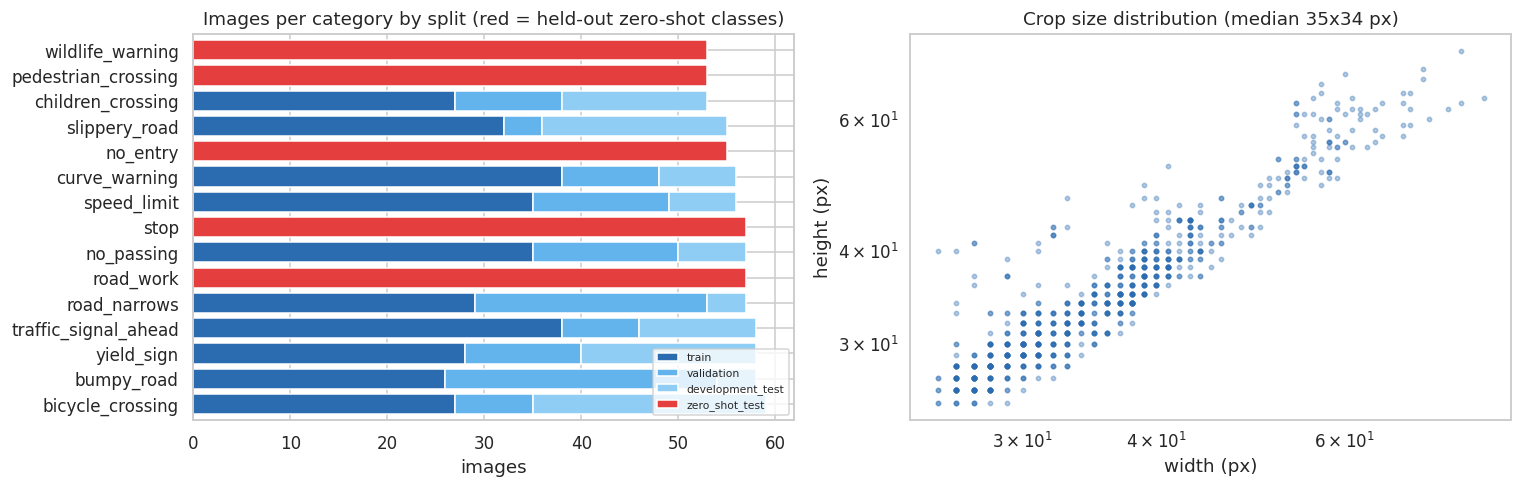

Country composition:
country
Germany    842

No province metadata available for this source - province breakdown is NOT reported (fabricating one would be dishonest).

Imbalance ratio (max/min class): 1.11


In [19]:
# --- EDA ------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

counts = (split_manifest.groupby(["label", "split"]).size().unstack(fill_value=0)
          .reindex(columns=["train", "validation", "development_test", "zero_shot_test"], fill_value=0))
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
counts.plot(kind="barh", stacked=True, ax=axes[0], width=0.8,
            color=["#2b6cb0", "#63b3ed", "#90cdf4", "#e53e3e"])
axes[0].set_title("Images per category by split (red = held-out zero-shot classes)")
axes[0].set_xlabel("images"); axes[0].set_ylabel("")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].scatter(DATASET["width"], DATASET["height"], s=8, alpha=0.35, c="#2b6cb0")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Crop size distribution (median %dx%d px)" %
                  (QUALITY["median_width"], QUALITY["median_height"]))
axes[1].set_xlabel("width (px)"); axes[1].set_ylabel("height (px)")
plt.savefig(DIRS["figures"] / "eda_distributions.png", bbox_inches="tight"); plt.show()

# Geographic composition - reported ONLY where metadata genuinely supports it.
print("Country composition:")
print(DATASET["country"].value_counts(dropna=False).to_string())
if DATASET["region"].notna().any():
    print("\nProvince composition (from the queried Canadian regions):")
    print(DATASET["region"].value_counts(dropna=False).to_string())
else:
    print("\nNo province metadata available for this source - province breakdown is NOT reported "
          "(fabricating one would be dishonest).")

imb = DATASET["label"].value_counts()
print("\nImbalance ratio (max/min class): %.2f" % (imb.max() / max(imb.min(), 1)))

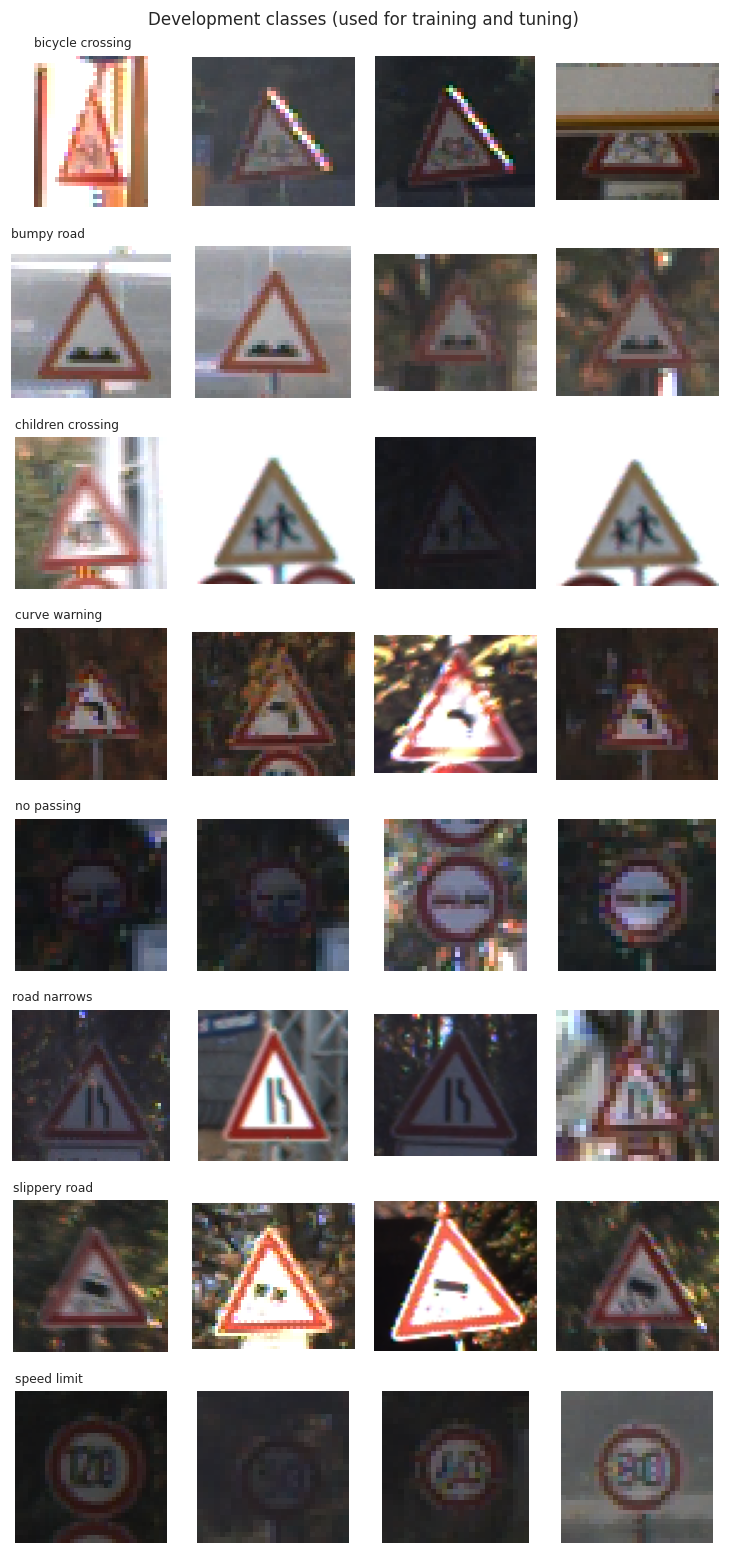

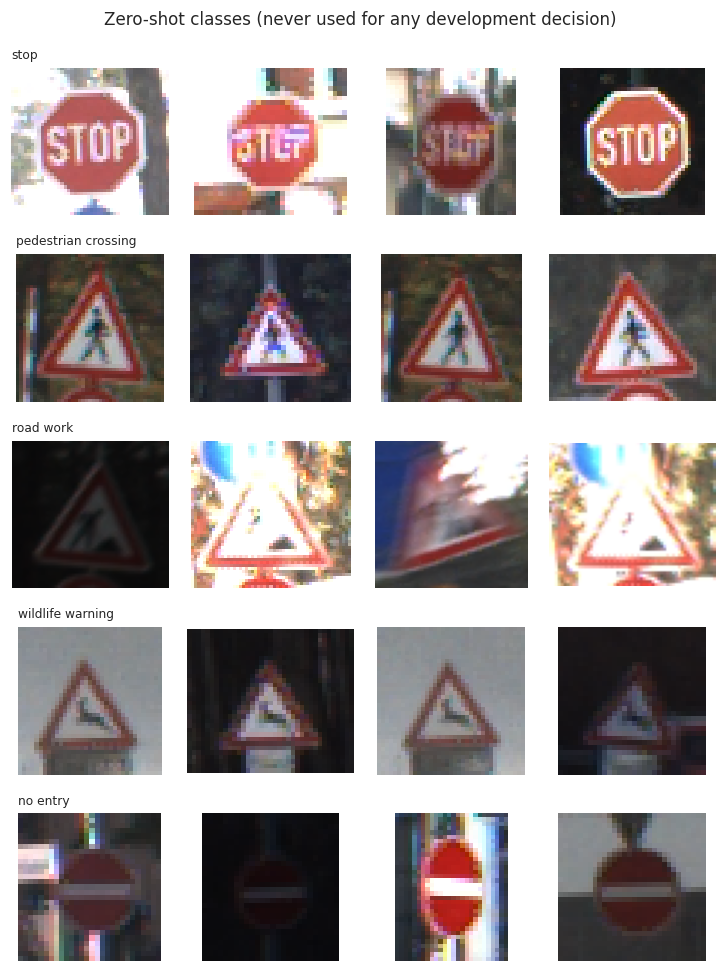

In [20]:
# --- Sample grid ----------------------------------------------------------------------------------
def sample_grid(df: pd.DataFrame, classes: Sequence[str], per_class: int = 4,
                title: str = "", fname: Optional[str] = None) -> None:
    classes = [c for c in classes if (df["label"] == c).any()]
    if not classes:
        return
    fig, axes = plt.subplots(len(classes), per_class,
                            figsize=(per_class * 1.7, len(classes) * 1.8), squeeze=False)
    rng = np.random.RandomState(RANDOM_SEED)
    for r, cls in enumerate(classes):
        sub = df[df["label"] == cls]
        pick = sub.iloc[rng.choice(len(sub), size=min(per_class, len(sub)), replace=False)]
        for c in range(per_class):
            ax = axes[r][c]; ax.axis("off")
            if c < len(pick):
                try:
                    ax.imshow(Image.open(pick.iloc[c]["local_path"]).convert("RGB"))
                except Exception:
                    pass
            if c == 0:
                ax.set_title(human_name(cls), fontsize=8, loc="left")
    fig.suptitle(title, fontsize=11)
    if fname:
        plt.savefig(DIRS["figures"] / fname, bbox_inches="tight")
    plt.show()

sample_grid(DATASET, DEV_CLASSES[:8], title="Development classes (used for training and tuning)",
            fname="samples_development.png")
sample_grid(DATASET, ZS_CLASSES, title="Zero-shot classes (never used for any development decision)",
            fname="samples_zeroshot.png")

## 14. Zero-Shot Model Framework

One wrapper interface for three different libraries. Every model exposes the same two operations —
`encode_images` and `encode_texts` returning L2-normalised embeddings — so scoring, caching, evaluation,
explanation and the Gradio app all share a single code path.

Scoring is cosine similarity, converted to a distribution with the model's own logit scale (and logit
bias for SigLIP). Section 20 examines whether those numbers deserve to be called "confidence".

In [21]:
# --- Vision-language model wrappers ---------------------------------------------------------------
# The logit scale (and SigLIP's bias) are persisted, so a run that hits the embedding cache produces
# exactly the same scores as a run that recomputes them without having to reload the weights.
MODEL_SCALES_PATH = DIRS["cache"] / "model_scales.json"
try:
    MODEL_SCALES: Dict[str, Dict[str, float]] = json.load(open(MODEL_SCALES_PATH))
except Exception:
    MODEL_SCALES = {}

class VLM:
    """Uniform wrapper over HF CLIP, OpenCLIP and HF SigLIP."""

    def __init__(self, key: str, kind: str, model_id: str, pretrained: Optional[str] = None) -> None:
        self.key, self.kind, self.model_id, self.pretrained = key, kind, model_id, pretrained
        self.model = self.processor = self.tokenizer = self.preprocess = None
        self.loaded, self.load_error, self.embed_dim = False, None, -1
        self.alignment_score = "not tested"

    # ---- lifecycle ----
    def load(self) -> bool:
        if self.loaded:
            return True
        try:
            if self.kind == "hf_clip":
                from transformers import CLIPModel, CLIPProcessor
                self.model = CLIPModel.from_pretrained(self.model_id).to(DEVICE).eval()
                self.processor = CLIPProcessor.from_pretrained(self.model_id)
            elif self.kind == "hf_siglip":
                from transformers import AutoModel, AutoProcessor
                self.model = AutoModel.from_pretrained(self.model_id).to(DEVICE).eval()
                self.processor = AutoProcessor.from_pretrained(self.model_id)
            elif self.kind == "open_clip":
                import open_clip
                self.model, _, self.preprocess = open_clip.create_model_and_transforms(
                    self.model_id, pretrained=self.pretrained)
                self.model = self.model.to(DEVICE).eval()
                self.tokenizer = open_clip.get_tokenizer(self.model_id)
            else:
                raise ValueError("unknown kind %s" % self.kind)
            self.loaded = True
            try:
                MODEL_SCALES[self.checkpoint_id] = dict(
                    logit_scale=float(self.model.logit_scale.exp().item()),
                    logit_bias=float(self.model.logit_bias.item())
                    if hasattr(self.model, "logit_bias") else 0.0)
                json.dump(MODEL_SCALES, open(MODEL_SCALES_PATH, "w"), indent=2)
            except Exception:
                pass
            logger.info("Loaded %s (%s / %s)", self.key, self.model_id, self.pretrained or "-")
        except Exception as exc:
            self.load_error = "%s: %s" % (type(exc).__name__, str(exc)[:200])
            logger.error("Could not load %s -> %s", self.key, self.load_error)
        return self.loaded

    def unload(self) -> None:
        self.model = self.processor = self.tokenizer = self.preprocess = None
        self.loaded = False
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    # ---- properties ----
    @property
    def checkpoint_id(self) -> str:
        return "%s|%s" % (self.model_id, self.pretrained or "default")

    def _scale_entry(self) -> Dict[str, float]:
        if self.model is not None:
            try:
                MODEL_SCALES[self.checkpoint_id] = dict(
                    logit_scale=float(self.model.logit_scale.exp().item()),
                    logit_bias=float(self.model.logit_bias.item())
                    if hasattr(self.model, "logit_bias") else 0.0)
            except Exception:
                pass
        if self.checkpoint_id not in MODEL_SCALES:
            self.load()                       # last resort: load once to learn the temperature
        return MODEL_SCALES.get(self.checkpoint_id, dict(logit_scale=100.0, logit_bias=0.0))

    @property
    def logit_scale(self) -> float:
        return float(self._scale_entry().get("logit_scale", 100.0))

    @property
    def logit_bias(self) -> float:
        return float(self._scale_entry().get("logit_bias", 0.0))

    # ---- encoders ----
    def _hf_features(self, inputs: dict, modality: str) -> torch.Tensor:
        """Projected joint-space features from a Hugging Face CLIP/SigLIP model.

        transformers >= 5 returns a `BaseModelOutputWithPooling` from `get_image_features` /
        `get_text_features` rather than a tensor. Guessing how to unwrap it is dangerous: for CLIP the
        text pooler output is ALREADY projected, so applying `text_projection` again (it is square, so
        a shape check does not catch it) silently puts text and image embeddings in different spaces
        and drives accuracy to chance. We therefore recompute from the towers explicitly, which is
        unambiguous, and only trust the convenience method when it hands back a real tensor."""
        out = self.model.get_image_features(**inputs) if modality == "image" \
            else self.model.get_text_features(**inputs)
        if torch.is_tensor(out):
            return out
        embeds = getattr(out, "image_embeds" if modality == "image" else "text_embeds", None)
        if torch.is_tensor(embeds):
            return embeds
        tower = self.model.vision_model if modality == "image" else self.model.text_model
        tower_out = tower(**inputs)
        pooled = getattr(tower_out, "pooler_output", None)
        if not torch.is_tensor(pooled):
            lh = getattr(tower_out, "last_hidden_state", None)
            if not torch.is_tensor(lh):
                raise TypeError("cannot obtain pooled features from %s" % type(tower_out).__name__)
            pooled = lh[:, 0]
        # CLIP projects the pooled tower output into the joint space; SigLIP has no such projection.
        proj = getattr(self.model, "visual_projection" if modality == "image" else "text_projection",
                       None)
        return proj(pooled) if proj is not None else pooled

    def alignment_self_test(self) -> bool:
        """Prove the image and text encoders actually share a space before trusting any metric.

        A shape-only check passes even when the two towers are misaligned, and a misaligned model then
        reports as a *weak* model rather than a broken one. So we run a behavioural probe: solid
        colour images against colour captions. Any correctly wired CLIP-family model scores 4/4; a
        misaligned one is at chance."""
        colours = {"red": (220, 30, 30), "green": (30, 170, 60),
                   "blue": (30, 60, 220), "yellow": (240, 220, 40)}
        names = list(colours)
        try:
            imgs = [Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), colours[c]) for c in names]
            ie = self.encode_pil(imgs)
            te = self.encode_texts(["a photo of a solid %s square" % c for c in names])
            if ie.ndim != 2 or te.ndim != 2 or ie.shape[1] != te.shape[1]:
                self.load_error = "self-test: image %s vs text %s" % (ie.shape, te.shape)
                return False
            if not (np.isfinite(ie).all() and np.isfinite(te).all()):
                self.load_error = "self-test: non-finite embeddings"
                return False
            correct = int((( ie @ te.T).argmax(axis=1) == np.arange(len(names))).sum())
            self.embed_dim = int(ie.shape[1])
            self.alignment_score = "%d/%d" % (correct, len(names))
            if correct < len(names) - 1:
                self.load_error = ("image-text ALIGNMENT check failed (%s colour probes correct). "
                                   "The encoders are not in a shared space, so every metric from this "
                                   "model would be meaningless." % self.alignment_score)
                return False
            return True
        except Exception as exc:
            self.load_error = "self-test failed - %s: %s" % (type(exc).__name__, str(exc)[:180])
            return False

    def _encode_image_batch(self, images: List[Image.Image]) -> torch.Tensor:
        if self.kind == "open_clip":
            px = torch.stack([self.preprocess(im) for im in images]).to(DEVICE)
            feats = self.model.encode_image(px)
        else:
            inputs = self.processor(images=images, return_tensors="pt").to(DEVICE)
            feats = self._hf_features(dict(inputs), "image")
        return F.normalize(feats.float(), dim=-1)

    @torch.no_grad()
    def encode_images(self, paths: Sequence[str], batch_size: int = BATCH_SIZE,
                      desc: str = "") -> np.ndarray:
        """Encode images from disk into an (N, D) L2-normalised float32 array."""
        out, bs, i = [], batch_size, 0
        bar = tqdm(total=len(paths), desc=desc or ("encode[%s]" % self.key), leave=False)
        while i < len(paths):
            batch_paths = paths[i:i + bs]
            images = []
            for p in batch_paths:
                try:
                    images.append(Image.open(p).convert("RGB"))
                except Exception:
                    images.append(Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128)))
            try:
                with torch.autocast("cuda", enabled=USE_AMP):
                    feats = self._encode_image_batch(images)
                out.append(feats.cpu().numpy().astype(np.float32))
                bar.update(len(batch_paths)); i += bs
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                if bs == 1:
                    raise
                bs = max(1, bs // 2)
                logger.warning("CUDA OOM - reducing batch size to %d", bs)
        bar.close()
        return np.concatenate(out, axis=0) if out else np.zeros((0, 512), dtype=np.float32)

    @torch.no_grad()
    def encode_pil(self, images: List[Image.Image]) -> np.ndarray:
        """Encode already-loaded PIL images (used by the app, robustness tests and explanations)."""
        with torch.autocast("cuda", enabled=USE_AMP):
            return self._encode_image_batch(images).cpu().numpy().astype(np.float32)

    @torch.no_grad()
    def encode_texts(self, texts: Sequence[str], batch_size: int = 64) -> np.ndarray:
        out = []
        for i in range(0, len(texts), batch_size):
            chunk = list(texts[i:i + batch_size])
            if self.kind == "open_clip":
                toks = self.tokenizer(chunk).to(DEVICE)
                feats = self.model.encode_text(toks)
            elif self.kind == "hf_siglip":
                inputs = self.processor(text=chunk, padding="max_length", truncation=True,
                                        return_tensors="pt").to(DEVICE)
                feats = self._hf_features(dict(inputs), "text")
            else:
                inputs = self.processor(text=chunk, padding=True, truncation=True,
                                        return_tensors="pt").to(DEVICE)
                feats = self._hf_features(dict(inputs), "text")
            out.append(F.normalize(feats.float(), dim=-1).cpu().numpy().astype(np.float32))
        return np.concatenate(out, axis=0)

MODELS: Dict[str, VLM] = {k: VLM(k, **cfg) for k, cfg in VLM_REGISTRY.items()}

AVAILABLE_MODELS: List[str] = []
MODEL_FAILURES: Dict[str, str] = {}
for key, m in MODELS.items():
    if m.load() and m.alignment_self_test():
        AVAILABLE_MODELS.append(key)
        print("  %-9s OK  (%s, dim %d, alignment probe %s)"
              % (key, m.checkpoint_id, m.embed_dim, m.alignment_score))
    else:
        MODEL_FAILURES[key] = m.load_error or "unknown failure"
    m.unload()

if not AVAILABLE_MODELS:
    raise RuntimeError("No vision-language model could be loaded. Check the network and installs.")
print("\nUsable zero-shot models:", AVAILABLE_MODELS)
if MODEL_FAILURES:
    print("\n" + "!" * 92)
    print("WARNING: %d of %d models are UNUSABLE and are excluded from every comparison below."
          % (len(MODEL_FAILURES), len(MODELS)))
    for k, v in MODEL_FAILURES.items():
        print("  %-9s -> %s" % (k, v))
    print("A model that fails here is usually a backend API change, not a missing checkpoint.")
    print("!" * 92)
    logger.error("Unusable models: %s", MODEL_FAILURES)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

15:04:36 | INFO    | Loaded siglip (google/siglip-base-patch16-224 / -)
  siglip    OK  (google/siglip-base-patch16-224|default, dim 768, alignment probe 4/4)

Usable zero-shot models: ['clip', 'openclip', 'siglip']


In [22]:
# --- Embedding cache ------------------------------------------------------------------------------
# Cache files carry a metadata block. If ANY component of the signature changes (model, checkpoint,
# preprocessing, split contents, prompt version) the signature changes and the cache is not reused.
PROMPT_VERSION = "v1"

def _signature(**kwargs) -> str:
    return hashlib.sha256(json.dumps(kwargs, sort_keys=True, default=str).encode()).hexdigest()[:16]

def cached_image_embeddings(model_key: str, df: pd.DataFrame, split_name: str) -> np.ndarray:
    """Return (N, D) image embeddings for `df`, computing and caching them if necessary."""
    m = MODELS[model_key]
    ids_hash = _signature(ids=list(df["image_id"]))
    sig = _signature(model=model_key, ckpt=m.checkpoint_id, kind=m.kind, split=split_name,
                     ids=ids_hash, size=IMAGE_SIZE)
    cache_dir = DIRS["cache"] / model_key
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / ("image_embeddings_%s_%s.pt" % (split_name, sig))
    if path.exists() and not REBUILD_CACHE:
        blob = torch.load(path, map_location="cpu", weights_only=False)
        if blob["meta"]["signature"] == sig:
            CACHE_STATS["hit"] += 1
            logger.info("embedding cache HIT  %s/%s (%d vectors)", model_key, split_name,
                        len(blob["embeddings"]))
            return blob["embeddings"]
    CACHE_STATS["miss"] += 1
    logger.info("embedding cache MISS %s/%s - encoding %d images", model_key, split_name, len(df))
    m.load()
    emb = m.encode_images(list(df["local_path"]), desc="%s/%s" % (model_key, split_name))
    torch.save({"embeddings": emb,
                "meta": dict(signature=sig, model=model_key, checkpoint=m.checkpoint_id,
                             kind=m.kind, split=split_name, n=len(df), image_size=IMAGE_SIZE,
                             created=datetime.now(timezone.utc).isoformat())}, path)
    return emb

def cached_text_embeddings(model_key: str, class_texts: Dict[str, List[str]],
                           strategy: str) -> Tuple[np.ndarray, List[str]]:
    """Return (K, D) prompt-ensembled text embeddings and the class order they correspond to."""
    m = MODELS[model_key]
    classes = sorted(class_texts.keys())
    sig = _signature(model=model_key, ckpt=m.checkpoint_id, strategy=strategy,
                     prompts={c: class_texts[c] for c in classes}, version=PROMPT_VERSION)
    cache_dir = DIRS["cache"] / model_key
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / ("text_embeddings_%s_%s.pt" % (strategy, sig))
    if path.exists() and not REBUILD_CACHE:
        blob = torch.load(path, map_location="cpu", weights_only=False)
        if blob["meta"]["signature"] == sig:
            CACHE_STATS["hit"] += 1
            return blob["embeddings"], blob["meta"]["classes"]
    CACHE_STATS["miss"] += 1
    m.load()
    vecs = []
    for c in classes:
        e = m.encode_texts(class_texts[c])            # (T, D), already normalised
        v = e.mean(axis=0)                            # prompt ensembling = mean of unit vectors
        vecs.append(v / (np.linalg.norm(v) + 1e-12))
    emb = np.stack(vecs).astype(np.float32)
    torch.save({"embeddings": emb,
                "meta": dict(signature=sig, model=model_key, checkpoint=m.checkpoint_id,
                             strategy=strategy, classes=classes, prompt_version=PROMPT_VERSION,
                             created=datetime.now(timezone.utc).isoformat())}, path)
    return emb, classes

## 15–16. Prompt Engineering & Class Descriptions

Four text strategies plus every individual template, all selected **on the development validation split
only**. The chosen strategy is then frozen before the zero-shot test set is touched.

In [23]:
# --- Prompt strategies ----------------------------------------------------------------------------
PROMPT_TEMPLATES = [
    "a photo of {}",
    "a Canadian road sign showing {}",
    "a Canadian traffic sign for {}",
    "a road sign indicating {}",
    "this is a Canadian road sign: {}",
    "a close-up photo of {} beside a road",
]

def texts_for(cls: str, strategy: str) -> List[str]:
    """Return the list of prompt strings for one class under a given strategy."""
    t = TAXONOMY[cls]
    if strategy == "class_name":
        return [human_name(cls)]
    if strategy == "short_description":
        return [t["short"]]
    if strategy == "canadian_description":
        return [t["canadian"]]
    if strategy == "prompt_ensemble":
        return ([tpl.format(t["short"]) for tpl in PROMPT_TEMPLATES] +
                [tpl.format(t["canadian"]) for tpl in PROMPT_TEMPLATES])
    if strategy.startswith("template:"):
        return [PROMPT_TEMPLATES[int(strategy.split(":")[1])].format(t["short"])]
    raise ValueError("unknown strategy %s" % strategy)

STRATEGIES = ["class_name", "short_description", "canadian_description", "prompt_ensemble"] + \
             ["template:%d" % i for i in range(len(PROMPT_TEMPLATES))]

def build_class_texts(classes: Sequence[str], strategy: str) -> Dict[str, List[str]]:
    return {c: texts_for(c, strategy) for c in classes}

print("Example prompts for 'curve_warning':")
for s in ["class_name", "short_description", "canadian_description", "prompt_ensemble"]:
    ex = texts_for("curve_warning", s)
    print("  %-22s %s%s" % (s, ex[0][:78], "  (+%d more)" % (len(ex) - 1) if len(ex) > 1 else ""))

Example prompts for 'curve_warning':
  class_name             curve warning
  short_description      a curve ahead warning sign
  canadian_description   a yellow diamond Canadian warning sign showing the road curving ahead
  prompt_ensemble        a photo of a curve ahead warning sign  (+11 more)


In [24]:
# --- Scoring + metrics ----------------------------------------------------------------------------
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)

def similarity_scores(img_emb: np.ndarray, txt_emb: np.ndarray) -> np.ndarray:
    """Raw cosine similarities, shape (N, K). Both inputs are L2-normalised."""
    return img_emb @ txt_emb.T

def scores_to_probs(sims: np.ndarray, model_key: str) -> np.ndarray:
    """Convert cosine similarities into a closed-set distribution using the model's own logit scale.

    NOTE: for SigLIP the training objective is a per-pair sigmoid, so a softmax over classes is a
    *convenience* for closed-set ranking, not the model's native probability. Section 20 quantifies how
    far these numbers are from calibrated probabilities."""
    m = MODELS[model_key]
    logits = sims * m.logit_scale + (m.logit_bias if m.kind == "hf_siglip" else 0.0)
    logits = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=1, keepdims=True)

def topk_metrics(y_true_idx: np.ndarray, scores: np.ndarray, n_classes: int,
                 ks: Sequence[int] = (1, 3, 5)) -> Dict[str, float]:
    order = np.argsort(-scores, axis=1)
    out = {}
    for k in ks:
        kk = min(k, n_classes)
        hit = (order[:, :kk] == y_true_idx[:, None]).any(axis=1)
        out["top%d" % k] = float(hit.mean())
    return out

def evaluate_zero_shot(model_key: str, df: pd.DataFrame, split_name: str, label_space: Sequence[str],
                       strategy: str) -> Dict[str, Any]:
    """Full closed-set zero-shot evaluation of one model + one prompt strategy on one split."""
    classes = sorted(label_space)
    img_emb = cached_image_embeddings(model_key, df, split_name)
    txt_emb, txt_classes = cached_text_embeddings(model_key, build_class_texts(classes, strategy),
                                                  strategy)
    assert txt_classes == classes
    sims = similarity_scores(img_emb, txt_emb)
    probs = scores_to_probs(sims, model_key)
    cls_to_idx = {c: i for i, c in enumerate(classes)}
    y_true = df["label"].map(cls_to_idx).to_numpy()
    y_pred = sims.argmax(axis=1)

    res = topk_metrics(y_true, sims, len(classes))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    res.update(dict(model=model_key, strategy=strategy, split=split_name, n_images=len(df),
                    n_classes=len(classes), macro_precision=p, macro_recall=r, macro_f1=f1,
                    weighted_f1=wf1, accuracy=float(accuracy_score(y_true, y_pred))))
    res["_arrays"] = dict(y_true=y_true, y_pred=y_pred, sims=sims, probs=probs, classes=classes,
                          image_id=df["image_id"].to_numpy(), local_path=df["local_path"].to_numpy())
    return res

def strip_arrays(d: Dict[str, Any]) -> Dict[str, Any]:
    return {k: v for k, v in d.items() if k != "_arrays"}

In [25]:
# --- Prompt / strategy selection on the DEVELOPMENT VALIDATION split ONLY --------------------------
# Nothing below touches zs_test_df. This is the only place strategies are compared.
selection_rows = []
for model_key in AVAILABLE_MODELS:
    for strategy in STRATEGIES:
        try:
            r = evaluate_zero_shot(model_key, val_df, "validation", DEV_CLASSES, strategy)
            selection_rows.append(strip_arrays(r))
        except Exception as exc:
            logger.error("selection failed for %s/%s: %s", model_key, strategy, str(exc)[:150])
    MODELS[model_key].unload()

PROMPT_SELECTION = pd.DataFrame(selection_rows).sort_values(["model", "macro_f1"], ascending=[True, False])
PROMPT_SELECTION.to_csv(DIRS["outputs"] / "prompt_selection_validation.csv", index=False)

if PROMPT_SELECTION.empty:
    raise RuntimeError("Prompt selection produced no results - no model could be evaluated.")

BEST_STRATEGY: Dict[str, str] = {}
for model_key, grp in PROMPT_SELECTION.groupby("model"):
    BEST_STRATEGY[model_key] = grp.iloc[0]["strategy"]

# Any model that failed on every strategy is dropped rather than left to break later lookups.
dropped = [k for k in AVAILABLE_MODELS if k not in BEST_STRATEGY]
if dropped:
    logger.warning("Dropping models with no successful evaluation: %s", dropped)
    AVAILABLE_MODELS = [k for k in AVAILABLE_MODELS if k in BEST_STRATEGY]

display(PROMPT_SELECTION[["model", "strategy", "top1", "top3", "macro_f1", "weighted_f1"]]
        .head(12).round(4))
print("\nFrozen prompt strategy per model (selected on VALIDATION, development classes only):")
for k, v in BEST_STRATEGY.items():
    print("  %-10s -> %s" % (k, v))

BEST_MODEL = PROMPT_SELECTION.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print("\nBest model on validation: %s" % BEST_MODEL)
logger.info("Frozen strategies: %s | best model: %s", BEST_STRATEGY, BEST_MODEL)

15:04:37 | INFO    | embedding cache MISS clip/validation - encoding 134 images


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

15:04:42 | INFO    | Loaded clip (openai/clip-vit-base-patch32 / -)


clip/validation:   0%|          | 0/134 [00:00<?, ?it/s]

15:04:43 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:43 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:43 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:44 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:44 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:44 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:44 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:44 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:45 | INFO    | embedding cache HIT  clip/validation (134 vectors)
15:04:45 | INFO    | embedding cache MISS openclip/validation - encoding 134 images
15:04:48 | INFO    | Loaded openclip (ViT-B-32 / laion2b_s34b_b79k)


...

15:04:56 | INFO    | Loaded siglip (google/siglip-base-patch16-224 / -)


siglip/validation:   0%|          | 0/134 [00:00<?, ?it/s]

15:04:58 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:04:58 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:04:58 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:04:59 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:04:59 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:04:59 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:05:00 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:05:00 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
15:05:00 | INFO    | embedding cache HIT  siglip/validation (134 vectors)


,model,strategy,top1,top3,macro_f1,weighted_f1
3,clip,prompt_ensemble,0.3433,0.6567,0.2951,0.3370
9,clip,template:5,0.2910,0.5896,0.2798,0.2822
2,clip,canadian_description,0.3134,0.6418,0.2644,0.2828
6,clip,template:2,0.3060,0.6791,0.2523,0.2654
7,clip,template:3,0.2463,0.6045,0.2312,0.2229
5,clip,template:1,0.2164,0.6791,0.2252,0.2269
4,clip,template:0,0.2836,0.5970,0.2223,0.2396
8,clip,template:4,0.2463,0.5672,0.1801,0.1623
1,clip,short_description,0.2537,0.5299,0.1790,0.1605
0,clip,class_name,0.2612,0.3731,0.1483,0.1426



Frozen prompt strategy per model (selected on VALIDATION, development classes only):
  clip       -> prompt_ensemble
  openclip   -> template:3
  siglip     -> template:1

Best model on validation: siglip
15:05:01 | INFO    | Frozen strategies: {'clip': 'prompt_ensemble', 'openclip': 'template:3', 'siglip': 'template:1'} | best model: siglip


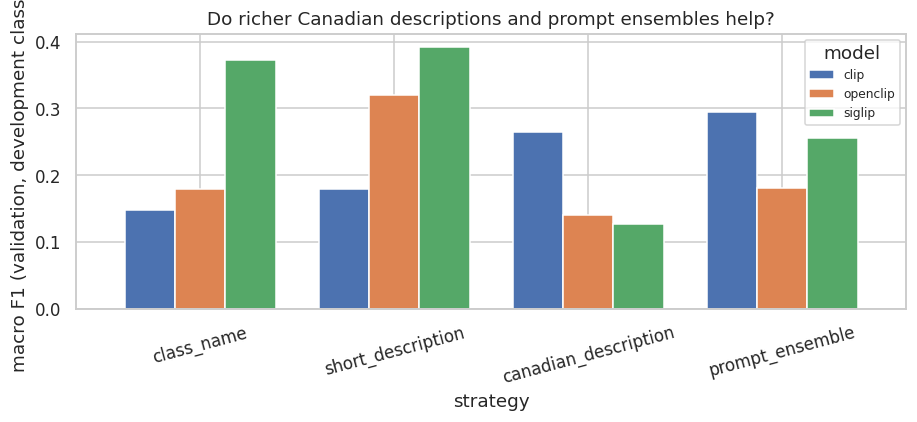

model,clip,openclip,siglip
strategy,,,
class_name,0.1483,0.1799,0.3722
short_description,0.1790,0.3199,0.3920
canadian_description,0.2644,0.1411,0.1272
prompt_ensemble,0.2951,0.1812,0.2559


In [26]:
# --- Prompt strategy comparison plot --------------------------------------------------------------
piv = (PROMPT_SELECTION[PROMPT_SELECTION["strategy"].isin(
            ["class_name", "short_description", "canadian_description", "prompt_ensemble"])]
       .pivot(index="strategy", columns="model", values="macro_f1")
       .reindex(["class_name", "short_description", "canadian_description", "prompt_ensemble"]))
ax = piv.plot(kind="bar", figsize=(8.5, 4), rot=15, width=0.78)
ax.set_ylabel("macro F1 (validation, development classes)")
ax.set_title("Do richer Canadian descriptions and prompt ensembles help?")
ax.legend(title="model", fontsize=8)
plt.savefig(DIRS["figures"] / "prompt_strategy_comparison.png", bbox_inches="tight"); plt.show()
display(piv.round(4))

## 17. Zero-Shot Evaluation on the Held-Out Classes

The prompt strategy and the model ranking are now **frozen**. Everything below is a single pass over
data whose categories were never involved in any decision above.

Two label spaces are reported:

* **Unseen-only** (primary): the model must choose among the held-out categories — the standard
  zero-shot protocol.
* **All categories** (harder): held-out + development categories in one label space, which measures
  whether unseen classes get swamped by familiar neighbours.

In [27]:
# --- Baselines + zero-shot test -------------------------------------------------------------------
ALL_CLASSES = sorted(DEV_CLASSES + ZS_CLASSES)

def trivial_baselines(df: pd.DataFrame, label_space: Sequence[str]) -> List[Dict[str, Any]]:
    """Random-guess expectation and majority-class accuracy on the same label space."""
    k = len(label_space)
    order = sorted(label_space)
    counts = df["label"].value_counts()
    majority_cls = counts.idxmax()
    majority_acc = float(counts.max() / len(df))
    rng = np.random.RandomState(RANDOM_SEED)
    rand_pred = rng.randint(0, k, size=len(df))
    y = df["label"].map({c: i for i, c in enumerate(order)}).to_numpy()
    maj_pred = np.full(len(df), order.index(majority_cls))
    _, _, rand_f1, _ = precision_recall_fscore_support(y, rand_pred, average="macro", zero_division=0)
    _, _, maj_f1, _ = precision_recall_fscore_support(y, maj_pred, average="macro", zero_division=0)
    return [
        dict(model="Random baseline", training_type="none", strategy="-", split="zero_shot_test",
             n_classes=k, n_images=len(df), top1=1.0 / k, top3=min(3, k) / k, top5=min(5, k) / k,
             macro_f1=float(rand_f1), weighted_f1=np.nan, accuracy=1.0 / k),
        dict(model="Majority-class baseline (always '%s')" % majority_cls, training_type="none",
             strategy="-", split="zero_shot_test", n_classes=k, n_images=len(df), top1=majority_acc,
             top3=np.nan, top5=np.nan, macro_f1=float(maj_f1), weighted_f1=np.nan,
             accuracy=majority_acc),
    ]

ZS_RESULTS: Dict[str, Dict[str, Any]] = {}
zs_rows: List[Dict[str, Any]] = []

for model_key in AVAILABLE_MODELS:
    strat = BEST_STRATEGY[model_key]
    r_unseen = evaluate_zero_shot(model_key, zs_test_df, "zero_shot_test", ZS_CLASSES, strat)
    r_all = evaluate_zero_shot(model_key, zs_test_df, "zero_shot_test", ALL_CLASSES, strat)
    r_dev = evaluate_zero_shot(model_key, devtest_df, "development_test", DEV_CLASSES, strat)
    ZS_RESULTS[model_key] = dict(unseen_only=r_unseen, all_classes=r_all, dev_test=r_dev)
    for tag, r in [("unseen-only", r_unseen), ("all-classes", r_all), ("dev-test", r_dev)]:
        row = strip_arrays(r); row["label_space"] = tag; row["training_type"] = "zero-shot"
        zs_rows.append(row)
    MODELS[model_key].unload()

ZS_TABLE = pd.DataFrame(zs_rows)
ZS_TABLE.to_csv(DIRS["outputs"] / "zero_shot_results.csv", index=False)

BASELINES = trivial_baselines(zs_test_df, ZS_CLASSES)

print("=" * 100)
print("ZERO-SHOT TEST | unseen classes only")
print("  Held-out classes      : %d  (%s)" % (len(ZS_CLASSES), ", ".join(ZS_CLASSES)))
print("  Zero-shot test images : %d" % len(zs_test_df))
print("  Chance level (top-1)  : %.3f" % (1.0 / len(ZS_CLASSES)))
print("=" * 100)
display(ZS_TABLE[ZS_TABLE["label_space"] == "unseen-only"]
        [["model", "strategy", "n_classes", "n_images", "top1", "top3", "top5",
          "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]].round(4))
print("\nHarder label space (unseen + development classes together):")
display(ZS_TABLE[ZS_TABLE["label_space"] == "all-classes"]
        [["model", "strategy", "n_classes", "top1", "top3", "macro_f1"]].round(4))

15:05:02 | INFO    | embedding cache MISS clip/zero_shot_test - encoding 275 images


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

15:05:05 | INFO    | Loaded clip (openai/clip-vit-base-patch32 / -)


clip/zero_shot_test:   0%|          | 0/275 [00:00<?, ?it/s]

15:05:08 | INFO    | embedding cache HIT  clip/zero_shot_test (275 vectors)
15:05:09 | INFO    | embedding cache MISS clip/development_test - encoding 118 images


...

siglip/development_test:   0%|          | 0/118 [00:00<?, ?it/s]

ZERO-SHOT TEST | unseen classes only
  Held-out classes      : 5  (stop, pedestrian_crossing, road_work, wildlife_warning, no_entry)
  Zero-shot test images : 275
  Chance level (top-1)  : 0.200


,model,strategy,n_classes,n_images,top1,top3,top5,macro_precision,macro_recall,macro_f1,weighted_f1
0,clip,prompt_ensemble,5,275,0.4509,0.8582,1.0,0.3059,0.4528,0.3199,0.3183
3,openclip,template:3,5,275,0.6545,0.9127,1.0,0.7380,0.6584,0.5942,0.5918
6,siglip,template:1,5,275,0.4945,0.9164,1.0,0.6550,0.4927,0.4680,0.4658



Harder label space (unseen + development classes together):


,model,strategy,n_classes,top1,top3,macro_f1
1,clip,prompt_ensemble,15,0.3745,0.4945,0.1499
4,openclip,template:3,15,0.4400,0.6873,0.1727
7,siglip,template:1,15,0.3345,0.5818,0.1480


,model,split,canonical_class,canadian_name,precision,recall,f1,support
0,clip,zero_shot_test,no_entry,Do not enter sign,0.000,0.000,0.000,55
1,clip,zero_shot_test,pedestrian_crossing,Pedestrian crossing sign,0.636,0.264,0.373,53
2,clip,zero_shot_test,road_work,Construction / road work sign,0.000,0.000,0.000,57
3,clip,zero_shot_test,stop,Stop sign (ARRET in Quebec),0.528,1.000,0.691,57
4,clip,zero_shot_test,wildlife_warning,Wildlife crossing sign,0.366,1.000,0.535,53
5,openclip,zero_shot_test,no_entry,Do not enter sign,0.689,0.764,0.724,55
6,openclip,zero_shot_test,pedestrian_crossing,Pedestrian crossing sign,0.672,0.774,0.719,53
7,openclip,zero_shot_test,road_work,Construction / road work sign,1.000,0.018,0.034,57
8,openclip,zero_shot_test,stop,Stop sign (ARRET in Quebec),0.875,0.982,0.926,57
9,openclip,zero_shot_test,wildlife_warning,Wildlife crossing sign,0.455,0.755,0.567,53


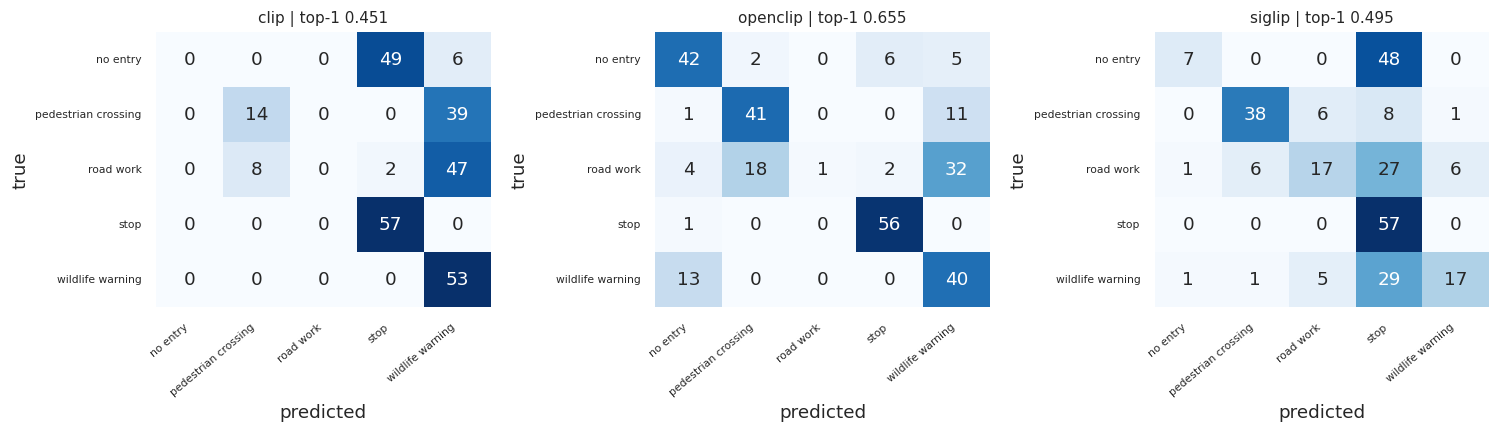

Saved 825 individual predictions.


In [28]:
# --- Per-class metrics + confusion matrices -------------------------------------------------------
per_class_rows = []
for model_key, res in ZS_RESULTS.items():
    a = res["unseen_only"]["_arrays"]
    p, r, f1, sup = precision_recall_fscore_support(a["y_true"], a["y_pred"],
                                                    labels=range(len(a["classes"])), zero_division=0)
    for i, cls in enumerate(a["classes"]):
        per_class_rows.append(dict(model=model_key, split="zero_shot_test", canonical_class=cls,
                                   canadian_name=TAXONOMY[cls]["canadian_name"], precision=p[i],
                                   recall=r[i], f1=f1[i], support=int(sup[i])))
PER_CLASS = pd.DataFrame(per_class_rows)
PER_CLASS.to_csv(DIRS["outputs"] / "per_class_metrics.csv", index=False)
display(PER_CLASS.round(3))

n = len(ZS_RESULTS)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4.1), squeeze=False)
for ax, (model_key, res) in zip(axes[0], ZS_RESULTS.items()):
    a = res["unseen_only"]["_arrays"]
    cm = confusion_matrix(a["y_true"], a["y_pred"], labels=range(len(a["classes"])))
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", cbar=False, ax=ax, vmin=0, vmax=1,
                xticklabels=[human_name(c) for c in a["classes"]],
                yticklabels=[human_name(c) for c in a["classes"]])
    ax.set_title("%s | top-1 %.3f" % (model_key, res["unseen_only"]["top1"]), fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(labelsize=7); plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.savefig(DIRS["figures"] / "confusion_matrices_zero_shot.png", bbox_inches="tight"); plt.show()

# Persist every individual prediction for auditing.
pred_rows = []
for model_key, res in ZS_RESULTS.items():
    a = res["unseen_only"]["_arrays"]
    order = np.argsort(-a["sims"], axis=1)
    for i in range(len(a["y_true"])):
        pred_rows.append(dict(
            model=model_key, image_id=a["image_id"][i], local_path=a["local_path"][i],
            true_class=a["classes"][a["y_true"][i]], predicted_class=a["classes"][a["y_pred"][i]],
            correct=bool(a["y_true"][i] == a["y_pred"][i]),
            top_similarity=float(a["sims"][i, a["y_pred"][i]]),
            softmax_score=float(a["probs"][i, a["y_pred"][i]]),
            top5="|".join("%s:%.3f" % (a["classes"][j], a["probs"][i, j])
                          for j in order[i, :min(5, len(a["classes"]))])))
PREDICTIONS = pd.DataFrame(pred_rows)
PREDICTIONS.to_csv(DIRS["outputs"] / "predictions.csv", index=False)
print("Saved %d individual predictions." % len(PREDICTIONS))

## 18. Supervised Baseline

A conventional transfer-learned CNN (`ResNet18`, ImageNet weights) trained **only on development
classes**. Validation drives early stopping and checkpoint selection; development-test gives the final
supervised number.

This baseline is *not* the contribution. It exists to make one point precise: a supervised classifier and
a zero-shot VLM answer different questions. The supervised model has a fixed output layer over the
classes it was trained on, so on the held-out categories its accuracy is structurally **zero** — it cannot
emit a label that does not exist in its head. We demonstrate that rather than assert it.

In [29]:
# --- Supervised baseline --------------------------------------------------------------------------
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

DEV_CLASS_TO_IDX = {c: i for i, c in enumerate(sorted(DEV_CLASSES))}

TRAIN_TF = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)), T.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
EVAL_TF = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

class SignDataset(Dataset):
    """Image-classification dataset over a manifest dataframe."""
    def __init__(self, df: pd.DataFrame, tf, class_to_idx: Dict[str, int]) -> None:
        self.paths = list(df["local_path"]); self.tf = tf
        self.labels = [class_to_idx.get(l, -1) for l in df["label"]]
    def __len__(self) -> int:
        return len(self.paths)
    def __getitem__(self, i: int):
        try:
            img = Image.open(self.paths[i]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
        return self.tf(img), self.labels[i]

def make_loader(df, tf, shuffle=False, bs=BATCH_SIZE):
    return DataLoader(SignDataset(df, tf, DEV_CLASS_TO_IDX), batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"), drop_last=False)

# The split signature is part of the filename: a checkpoint trained under a different split is
# never silently reused.
SPLIT_SIGNATURE = _signature(train=list(train_df["image_id"]), classes=sorted(DEV_CLASSES))
CKPT_PATH = DIRS["checkpoints"] / ("supervised_%s_%s_%s.pt"
                                  % (SUPERVISED_BACKBONE, EXPERIMENT, SPLIT_SIGNATURE))

def build_backbone(n_classes: int) -> nn.Module:
    net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, n_classes)
    return net.to(DEVICE)

def train_supervised() -> Tuple[nn.Module, pd.DataFrame]:
    """Train with early stopping on the development validation split."""
    set_global_seed(RANDOM_SEED)
    net = build_backbone(len(DEV_CLASS_TO_IDX))
    if CKPT_PATH.exists() and not REBUILD_CACHE:
        try:
            blob = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
            if blob["classes"] == sorted(DEV_CLASSES):
                net.load_state_dict(blob["state_dict"])
                logger.info("Supervised checkpoint cache HIT (val acc %.4f)", blob["val_acc"])
                return net, pd.DataFrame(blob["history"])
        except Exception as exc:
            logger.warning("Checkpoint unusable (%s) - retraining.", str(exc)[:100])

    tl, vl = make_loader(train_df, TRAIN_TF, shuffle=True), make_loader(val_df, EVAL_TF)
    opt = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(SUPERVISED_EPOCHS, 1))
    crit = nn.CrossEntropyLoss(label_smoothing=0.05)
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)      # torch >= 2.3
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)         # older torch
    best_acc, patience, bad, history = -1.0, 3, 0, []

    for epoch in range(SUPERVISED_EPOCHS):
        net.train(); running = 0.0
        for x, y in tqdm(tl, desc="epoch %d/%d" % (epoch + 1, SUPERVISED_EPOCHS), leave=False):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=USE_AMP):
                loss = crit(net(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running += float(loss) * len(y)
        sched.step()

        net.eval(); correct = total = 0
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += int((net(x).argmax(1) == y).sum()); total += len(y)
        val_acc = correct / max(total, 1)
        history.append(dict(epoch=epoch + 1, train_loss=running / max(len(tl.dataset), 1),
                            val_accuracy=val_acc))
        logger.info("epoch %d | train loss %.4f | val acc %.4f", epoch + 1,
                    history[-1]["train_loss"], val_acc)
        if val_acc > best_acc:
            best_acc, bad = val_acc, 0
            torch.save(dict(state_dict=net.state_dict(), classes=sorted(DEV_CLASSES),
                            val_acc=val_acc, history=history, backbone=SUPERVISED_BACKBONE), CKPT_PATH)
        else:
            bad += 1
            if bad >= patience:
                logger.info("Early stopping at epoch %d.", epoch + 1)
                break

    blob = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    net.load_state_dict(blob["state_dict"])
    return net, pd.DataFrame(history)

SUP_NET, SUP_HISTORY = train_supervised()
display(SUP_HISTORY.round(4))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


epoch 1/4:   0%|          | 0/10 [00:00<?, ?it/s]

15:05:29 | INFO    | epoch 1 | train loss 1.4662 | val acc 0.6866


epoch 2/4:   0%|          | 0/10 [00:00<?, ?it/s]

...

epoch 3/4:   0%|          | 0/10 [00:00<?, ?it/s]

15:05:36 | INFO    | epoch 3 | train loss 0.3398 | val acc 0.9030


epoch 4/4:   0%|          | 0/10 [00:00<?, ?it/s]

15:05:40 | INFO    | epoch 4 | train loss 0.3283 | val acc 0.9552


,epoch,train_loss,val_accuracy
0,1,1.4662,0.6866
1,2,0.4775,0.8209
2,3,0.3398,0.9030
3,4,0.3283,0.9552


In [30]:
# --- Supervised evaluation ------------------------------------------------------------------------
@torch.no_grad()
def supervised_predict(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities over development classes, true indices; -1 where the class is unseen)."""
    SUP_NET.eval()
    loader = make_loader(df, EVAL_TF)
    probs, ys = [], []
    for x, y in loader:
        with torch.autocast("cuda", enabled=USE_AMP):
            logits = SUP_NET(x.to(DEVICE))
        probs.append(torch.softmax(logits.float(), dim=1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

sup_probs, sup_y = supervised_predict(devtest_df)
sup_pred = sup_probs.argmax(1)
sup_classes = sorted(DEV_CLASSES)
p, r, f1, _ = precision_recall_fscore_support(sup_y, sup_pred, average="macro", zero_division=0)
_, _, wf1, _ = precision_recall_fscore_support(sup_y, sup_pred, average="weighted", zero_division=0)
SUP_DEV = dict(model="ResNet18 (supervised)", training_type="supervised", strategy="-",
               split="development_test", label_space="dev-test", n_classes=len(sup_classes),
               n_images=len(devtest_df), macro_precision=p, macro_recall=r, macro_f1=f1,
               weighted_f1=wf1, accuracy=float((sup_pred == sup_y).mean()),
               **topk_metrics(sup_y, sup_probs, len(sup_classes)))
print("Supervised baseline on DEVELOPMENT TEST (classes it was trained on):")
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v)
                  for k, v in SUP_DEV.items()}, indent=2))

# The structural point: the same network applied to held-out categories.
zs_probs_sup, _ = supervised_predict(zs_test_df)
zs_pred_sup = [sup_classes[i] for i in zs_probs_sup.argmax(1)]
SUP_ZS_TOP1 = 0.0     # by construction: no held-out class exists in the output layer
forced = pd.Series(zs_pred_sup).value_counts().head(5)
print("\nSame supervised network on the ZERO-SHOT test images:")
print("  top-1 accuracy = %.3f (structural: the held-out categories are not in its output layer)"
      % SUP_ZS_TOP1)
print("  it is forced to emit development classes; most frequent forced labels:")
print(forced.to_string())

# Matching zero-shot numbers on the SAME development-test split, for a like-for-like comparison.
dev_compare = [dict(model=k, training_type="zero-shot", strategy=BEST_STRATEGY[k],
                    split="development_test", label_space="dev-test",
                    **{m: ZS_RESULTS[k]["dev_test"][m] for m in
                       ["top1", "top3", "top5", "macro_f1", "weighted_f1", "accuracy"]})
                for k in AVAILABLE_MODELS]
display(pd.DataFrame([SUP_DEV] + dev_compare)[
    ["model", "training_type", "top1", "top3", "top5", "macro_f1"]].round(4))

Supervised baseline on DEVELOPMENT TEST (classes it was trained on):
{
  "model": "ResNet18 (supervised)",
  "training_type": "supervised",
  "strategy": "-",
  "split": "development_test",
  "label_space": "dev-test",
  "n_classes": 10,
  "n_images": 118,
  "macro_precision": 0.6557,
  "macro_recall": 0.6619,
  "macro_f1": 0.595,
  "weighted_f1": 0.5296,
  "accuracy": 0.5932,
  "top1": 0.5932,
  "top3": 0.7458,
  "top5": 0.8814
}

Same supervised network on the ZERO-SHOT test images:
  top-1 accuracy = 0.000 (structural: the held-out categories are not in its output layer)
  it is forced to emit development classes; most frequent forced labels:
speed_limit          66
children_crossing    60
road_narrows         33
slippery_road        32
bumpy_road           31


,model,training_type,top1,top3,top5,macro_f1
0,ResNet18 (supervised),supervised,0.5932,0.7458,0.8814,0.5950
1,clip,zero-shot,0.2627,0.4153,0.6102,0.2316
2,openclip,zero-shot,0.2966,0.5678,0.7119,0.1951
3,siglip,zero-shot,0.2373,0.5763,0.7458,0.1806


## 19. Closed-World vs Open-World (rejection option)

Closed-world forces a choice among the candidate classes. Open-world allows *"unknown / uncertain"* when
the top similarity is below a threshold.

**The threshold is chosen on the development validation split**, using development classes as "known" and
a held-out slice of *development* data relabelled as the negative condition — never on the zero-shot test
set. We report precision/recall of the accept decision, plus false acceptance and false rejection. This is
a rejection-option experiment, **not** a claim of true open-set recognition: real open-set evaluation
needs genuine out-of-distribution negatives, which this dataset does not provide.

15:05:42 | INFO    | embedding cache HIT  siglip/validation (134 vectors)
Rejection threshold selected on VALIDATION: 0.0511

Applied to the ZERO-SHOT test set (threshold frozen from validation):
threshold                0.0511
accept_rate              0.7745
precision_of_accepted    0.6150
recall_of_correct        0.9632
false_acceptance_rate    0.2982
false_rejection_rate     0.0182


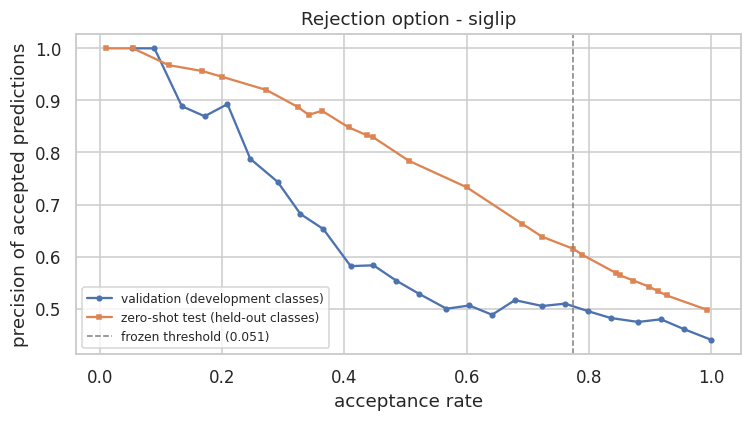

In [31]:
# --- Rejection option -----------------------------------------------------------------------------
def rejection_curve(sims: np.ndarray, y_true: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    """Accept when max similarity >= t. 'Correct' = accepted AND correctly classified."""
    top_sim, pred = sims.max(axis=1), sims.argmax(axis=1)
    correct = pred == y_true
    rows = []
    for t in thresholds:
        acc_mask = top_sim >= t
        n_acc = int(acc_mask.sum())
        tp = int((acc_mask & correct).sum())          # accepted and right
        fa = int((acc_mask & ~correct).sum())         # false acceptance: accepted but wrong
        fr = int((~acc_mask & correct).sum())         # false rejection: would have been right
        rows.append(dict(threshold=float(t), accept_rate=n_acc / len(sims),
                         precision_of_accepted=tp / max(n_acc, 1),
                         recall_of_correct=tp / max(int(correct.sum()), 1),
                         false_acceptance_rate=fa / len(sims), false_rejection_rate=fr / len(sims)))
    return pd.DataFrame(rows)

val_res = evaluate_zero_shot(BEST_MODEL, val_df, "validation", DEV_CLASSES, BEST_STRATEGY[BEST_MODEL])
va = val_res["_arrays"]
grid = np.quantile(va["sims"].max(axis=1), np.linspace(0.0, 0.95, 25))
val_curve = rejection_curve(va["sims"], va["y_true"], grid)

# Selection rule fixed in advance: highest accepted-precision subject to accepting >= 60% of images.
eligible = val_curve[val_curve["accept_rate"] >= 0.60]
REJECT_THRESHOLD = float((eligible if len(eligible) else val_curve)
                         .sort_values("precision_of_accepted", ascending=False).iloc[0]["threshold"])
print("Rejection threshold selected on VALIDATION: %.4f" % REJECT_THRESHOLD)

zs_arr = ZS_RESULTS[BEST_MODEL]["unseen_only"]["_arrays"]
zs_curve = rejection_curve(zs_arr["sims"], zs_arr["y_true"], grid)
applied = rejection_curve(zs_arr["sims"], zs_arr["y_true"], np.array([REJECT_THRESHOLD])).iloc[0]
print("\nApplied to the ZERO-SHOT test set (threshold frozen from validation):")
print(applied.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(val_curve["accept_rate"], val_curve["precision_of_accepted"], "-o", ms=3,
        label="validation (development classes)")
ax.plot(zs_curve["accept_rate"], zs_curve["precision_of_accepted"], "-s", ms=3,
        label="zero-shot test (held-out classes)")
ax.axvline(applied["accept_rate"], ls="--", c="grey", lw=1,
           label="frozen threshold (%.3f)" % REJECT_THRESHOLD)
ax.set_xlabel("acceptance rate"); ax.set_ylabel("precision of accepted predictions")
ax.set_title("Rejection option - %s" % BEST_MODEL); ax.legend(fontsize=8)
plt.savefig(DIRS["figures"] / "rejection_option.png", bbox_inches="tight"); plt.show()
val_curve.to_csv(DIRS["outputs"] / "rejection_curve_validation.csv", index=False)
zs_curve.to_csv(DIRS["outputs"] / "rejection_curve_zero_shot.csv", index=False)

## 20. Robustness Testing

The available metadata does **not** carry weather, lighting, occlusion or viewing-angle attributes, so
those conditions are not reported — inventing them would be fabrication. Instead we apply controlled,
reproducible perturbations to the zero-shot test images and re-measure with the frozen prompt strategy.

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

15:06:26 | INFO    | Loaded siglip (google/siglip-base-patch16-224 / -)


robustness:   0%|          | 0/7 [00:00<?, ?it/s]

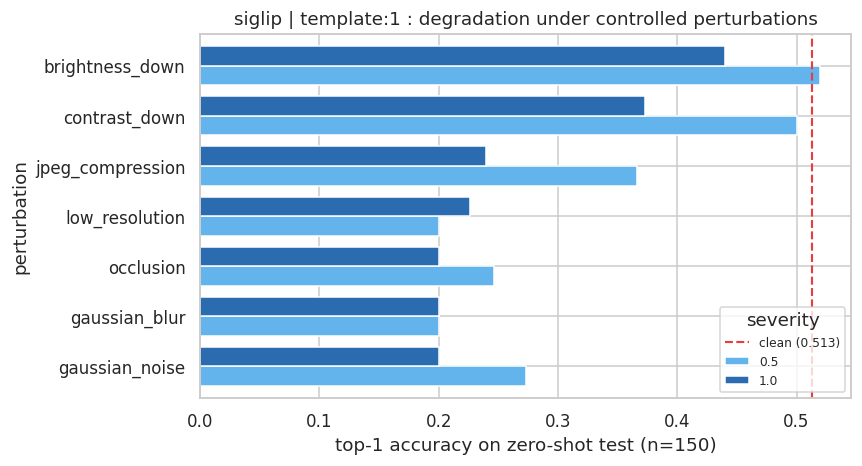

,perturbation,level,top1,delta
0,none,0.0,0.5133,0.0000
1,gaussian_blur,0.5,0.2000,-0.3133
2,gaussian_blur,1.0,0.2000,-0.3133
3,brightness_down,0.5,0.5200,0.0067
4,brightness_down,1.0,0.4400,-0.0733
5,contrast_down,0.5,0.5000,-0.0133
6,contrast_down,1.0,0.3733,-0.1400
7,jpeg_compression,0.5,0.3667,-0.1467
8,jpeg_compression,1.0,0.2400,-0.2733
9,gaussian_noise,0.5,0.2733,-0.2400


In [32]:
# --- Controlled perturbations ---------------------------------------------------------------------
def perturb(img: Image.Image, kind: str, level: float) -> Image.Image:
    """Deterministic image degradation. `level` in [0, 1] is the severity."""
    if kind == "gaussian_blur":
        return img.filter(ImageFilter.GaussianBlur(radius=0.5 + 4.0 * level))
    if kind == "brightness_down":
        return ImageEnhance.Brightness(img).enhance(1.0 - 0.75 * level)
    if kind == "brightness_up":
        return ImageEnhance.Brightness(img).enhance(1.0 + 1.5 * level)
    if kind == "contrast_down":
        return ImageEnhance.Contrast(img).enhance(1.0 - 0.8 * level)
    if kind == "jpeg_compression":
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=max(3, int(95 - 90 * level)))
        buf.seek(0)
        return Image.open(buf).convert("RGB")
    if kind == "gaussian_noise":
        arr = np.asarray(img).astype(np.float32)
        rng = np.random.RandomState(RANDOM_SEED)
        arr = arr + rng.normal(0, 60 * level, arr.shape)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if kind == "low_resolution":
        w, h = img.size
        f = max(2, int(2 + 8 * level))
        return img.resize((max(4, w // f), max(4, h // f)), Image.BILINEAR).resize((w, h), Image.NEAREST)
    if kind == "occlusion":
        out = img.copy(); d = ImageDraw.Draw(out); w, h = img.size
        bw, bh = int(w * 0.45 * level + 0.1 * w), int(h * 0.45 * level + 0.1 * h)
        d.rectangle([w // 2 - bw // 2, h // 2 - bh // 2, w // 2 + bw // 2, h // 2 + bh // 2],
                    fill=(110, 110, 110))
        return out
    raise ValueError(kind)

PERTURBATIONS = ["gaussian_blur", "brightness_down", "contrast_down", "jpeg_compression",
                 "gaussian_noise", "low_resolution", "occlusion"]

def evaluate_perturbed(model_key: str, df: pd.DataFrame, classes: Sequence[str], strategy: str,
                       kind: Optional[str], level: float) -> float:
    """Top-1 accuracy under a perturbation (None = clean). Images are encoded on the fly."""
    m = MODELS[model_key]; m.load()
    txt_emb, cls_order = cached_text_embeddings(model_key, build_class_texts(sorted(classes), strategy),
                                                strategy)
    y = df["label"].map({c: i for i, c in enumerate(cls_order)}).to_numpy()
    preds = []
    for i in range(0, len(df), BATCH_SIZE):
        chunk = df.iloc[i:i + BATCH_SIZE]
        imgs = []
        for p in chunk["local_path"]:
            try:
                im = Image.open(p).convert("RGB")
            except Exception:
                im = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
            imgs.append(perturb(im, kind, level) if kind else im)
        preds.append((m.encode_pil(imgs) @ txt_emb.T).argmax(axis=1))
    return float((np.concatenate(preds) == y).mean())

rob_df = zs_test_df.sample(n=min(ROBUSTNESS_MAX_IMAGES, len(zs_test_df)),
                           random_state=RANDOM_SEED).reset_index(drop=True)
strat = BEST_STRATEGY[BEST_MODEL]
clean_acc = evaluate_perturbed(BEST_MODEL, rob_df, ZS_CLASSES, strat, None, 0.0)

rob_rows = [dict(perturbation="none", level=0.0, top1=clean_acc, delta=0.0)]
for kind in tqdm(PERTURBATIONS, desc="robustness"):
    for level in (0.5, 1.0):
        acc = evaluate_perturbed(BEST_MODEL, rob_df, ZS_CLASSES, strat, kind, level)
        rob_rows.append(dict(perturbation=kind, level=level, top1=acc, delta=acc - clean_acc))
MODELS[BEST_MODEL].unload()

ROBUSTNESS = pd.DataFrame(rob_rows)
ROBUSTNESS.to_csv(DIRS["outputs"] / "robustness_results.csv", index=False)

pivot = ROBUSTNESS[ROBUSTNESS["perturbation"] != "none"].pivot(
    index="perturbation", columns="level", values="top1").sort_values(1.0)
ax = pivot.plot(kind="barh", figsize=(8, 4.4), width=0.78, color=["#63b3ed", "#2b6cb0"])
ax.axvline(clean_acc, color="#e53e3e", ls="--", lw=1.4, label="clean (%.3f)" % clean_acc)
ax.set_xlabel("top-1 accuracy on zero-shot test (n=%d)" % len(rob_df))
ax.set_title("%s | %s : degradation under controlled perturbations" % (BEST_MODEL, strat))
ax.legend(title="severity", fontsize=8)
plt.savefig(DIRS["figures"] / "robustness.png", bbox_inches="tight"); plt.show()
display(ROBUSTNESS.round(4))

## 21. Explainability

SHAP is a poor fit here: it needs a fixed scalar output over a fixed feature space, whereas a VLM's output
is a similarity between two embeddings and depends on which text you compare against. Gradient methods
such as Grad-CAM also need a chosen convolutional layer, which does not exist in a ViT in the usual sense.

We therefore use **occlusion sensitivity on the image–text similarity**: slide a grey patch across the
image and measure how much the similarity to the predicted class's text embedding drops. It is
model-agnostic (works identically for CLIP, OpenCLIP and SigLIP), needs no gradients, and answers exactly
the question we care about: *which pixels support this particular text hypothesis?*

Limitations, stated plainly: occlusion maps are coarse (patch-resolution), assume spatial independence,
can be misled by out-of-distribution grey patches, and are explanations of *this* model's similarity — not
evidence that the model reasons about the sign the way a human would.

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

15:06:48 | INFO    | Loaded siglip (google/siglip-base-patch16-224 / -)


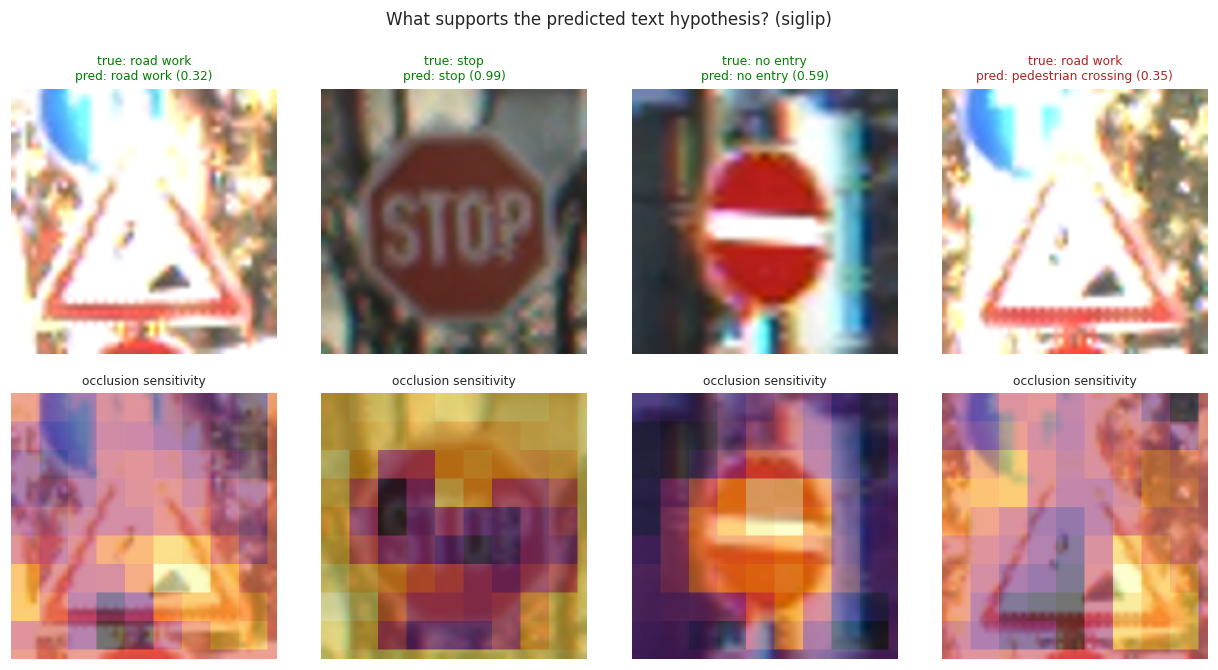

In [33]:
# --- Occlusion-sensitivity explanations -----------------------------------------------------------
def occlusion_explanation(model_key: str, image: Image.Image, text_embedding: np.ndarray,
                          patch: int = 48, stride: int = OCCLUSION_STRIDE) -> np.ndarray:
    """Similarity drop map: higher = that region matters more for the given text hypothesis."""
    m = MODELS[model_key]; m.load()
    img = image.convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    base = float(m.encode_pil([img])[0] @ text_embedding)
    xs = list(range(0, IMAGE_SIZE - patch + 1, stride)) or [0]
    ys = list(range(0, IMAGE_SIZE - patch + 1, stride)) or [0]
    variants, coords = [], []
    for y in ys:
        for x in xs:
            v = img.copy()
            ImageDraw.Draw(v).rectangle([x, y, x + patch, y + patch], fill=(127, 127, 127))
            variants.append(v); coords.append((x, y))
    sims = []
    for i in range(0, len(variants), BATCH_SIZE):
        sims.append(m.encode_pil(variants[i:i + BATCH_SIZE]) @ text_embedding)
    sims = np.concatenate(sims)
    heat = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)
    cover = np.zeros_like(heat)
    for (x, y), s in zip(coords, sims):
        heat[y:y + patch, x:x + patch] += (base - float(s))
        cover[y:y + patch, x:x + patch] += 1.0
    heat /= np.maximum(cover, 1e-6)
    rng = heat.max() - heat.min()
    return (heat - heat.min()) / (rng if rng > 1e-9 else 1.0)

def show_explanations(model_key: str, n: int = 4) -> None:
    strategy = BEST_STRATEGY[model_key]
    txt_emb, cls_order = cached_text_embeddings(model_key, build_class_texts(ZS_CLASSES, strategy),
                                                strategy)
    arr = ZS_RESULTS[model_key]["unseen_only"]["_arrays"]
    correct_idx = np.where(arr["y_true"] == arr["y_pred"])[0]
    wrong_idx = np.where(arr["y_true"] != arr["y_pred"])[0]
    rng = np.random.RandomState(RANDOM_SEED)
    picks = (list(rng.choice(correct_idx, size=min(n - 1, len(correct_idx)), replace=False))
             + (list(rng.choice(wrong_idx, size=1, replace=False)) if len(wrong_idx) else []))
    if not picks:
        return
    fig, axes = plt.subplots(2, len(picks), figsize=(3.0 * len(picks), 6.2), squeeze=False)
    for c, i in enumerate(picks):
        img = Image.open(arr["local_path"][i]).convert("RGB")
        pred_i = int(arr["y_pred"][i])
        heat = occlusion_explanation(model_key, img, txt_emb[pred_i])
        axes[0][c].imshow(img.resize((IMAGE_SIZE, IMAGE_SIZE))); axes[0][c].axis("off")
        axes[0][c].set_title("true: %s\npred: %s (%.2f)" %
                             (human_name(arr["classes"][arr["y_true"][i]]),
                              human_name(arr["classes"][pred_i]), arr["probs"][i, pred_i]),
                             fontsize=8,
                             color=("green" if arr["y_true"][i] == pred_i else "firebrick"))
        axes[1][c].imshow(img.resize((IMAGE_SIZE, IMAGE_SIZE)))
        axes[1][c].imshow(heat, cmap="inferno", alpha=0.55); axes[1][c].axis("off")
        axes[1][c].set_title("occlusion sensitivity", fontsize=8)
    fig.suptitle("What supports the predicted text hypothesis? (%s)" % model_key, fontsize=11)
    plt.savefig(DIRS["figures"] / "explanations.png", bbox_inches="tight"); plt.show()
    MODELS[model_key].unload()

show_explanations(BEST_MODEL)

## 22. Confidence & Calibration

A softmax over cosine similarities is **not** a probability. CLIP's logit scale is a learned temperature
fitted for contrastive training, and SigLIP's objective is a per-pair sigmoid with a bias — neither was
trained to produce calibrated class posteriors over *our* five-way label space.

We therefore report the raw similarity distribution, a reliability diagram, and the Expected Calibration
Error, and we always distinguish **similarity score** from **calibrated probability**.

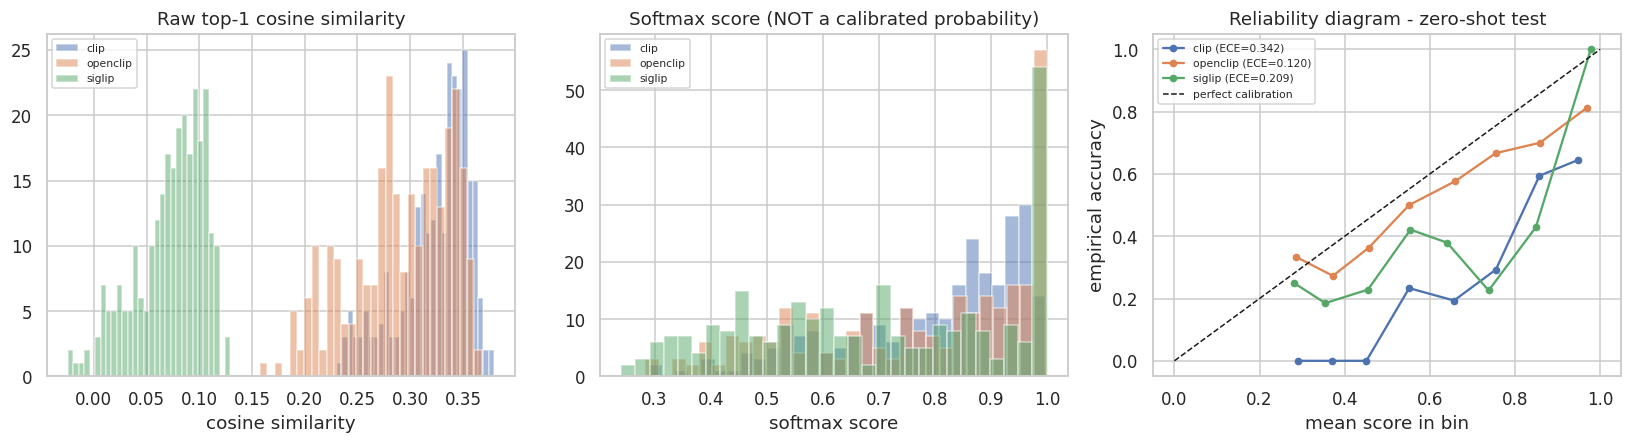

,model,ece,mean_softmax_confidence,accuracy,mean_top_similarity,overconfidence
0,clip,0.3424,0.7933,0.4509,0.3239,0.3424
1,openclip,0.1202,0.7737,0.6545,0.2910,0.1192
2,siglip,0.2092,0.6923,0.4945,0.0727,0.1977


Positive 'overconfidence' means the mean softmax score exceeds the empirical accuracy: the score reads as confidence but is not one.


In [34]:
# --- Calibration ----------------------------------------------------------------------------------
def expected_calibration_error(conf: np.ndarray, correct: np.ndarray,
                               n_bins: int = 10) -> Tuple[float, pd.DataFrame]:
    """Equal-width-bin ECE plus the per-bin table used for the reliability diagram."""
    edges = np.linspace(0, 1, n_bins + 1)
    rows, ece = [], 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi) if lo > 0 else (conf >= lo) & (conf <= hi)
        n = int(mask.sum())
        if n == 0:
            rows.append(dict(bin_lo=lo, bin_hi=hi, n=0, mean_confidence=np.nan, accuracy=np.nan))
            continue
        acc, avg = float(correct[mask].mean()), float(conf[mask].mean())
        ece += (n / len(conf)) * abs(acc - avg)
        rows.append(dict(bin_lo=lo, bin_hi=hi, n=n, mean_confidence=avg, accuracy=acc))
    return float(ece), pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cal_rows = []
for model_key, res in ZS_RESULTS.items():
    a = res["unseen_only"]["_arrays"]
    conf = a["probs"].max(axis=1)
    correct = (a["y_pred"] == a["y_true"]).astype(float)
    ece, table = expected_calibration_error(conf, correct)
    cal_rows.append(dict(model=model_key, ece=ece, mean_softmax_confidence=float(conf.mean()),
                         accuracy=float(correct.mean()),
                         mean_top_similarity=float(a["sims"].max(axis=1).mean()),
                         overconfidence=float(conf.mean() - correct.mean())))
    axes[0].hist(a["sims"].max(axis=1), bins=30, alpha=0.5, label=model_key)
    axes[1].hist(conf, bins=30, alpha=0.5, label=model_key)
    t = table.dropna()
    axes[2].plot(t["mean_confidence"], t["accuracy"], "-o", ms=4,
                 label="%s (ECE=%.3f)" % (model_key, ece))
    table.to_csv(DIRS["outputs"] / ("calibration_bins_%s.csv" % model_key), index=False)

axes[0].set_title("Raw top-1 cosine similarity"); axes[0].set_xlabel("cosine similarity")
axes[1].set_title("Softmax score (NOT a calibrated probability)"); axes[1].set_xlabel("softmax score")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[2].set_title("Reliability diagram - zero-shot test")
axes[2].set_xlabel("mean score in bin"); axes[2].set_ylabel("empirical accuracy")
for ax in axes:
    ax.legend(fontsize=7)
plt.savefig(DIRS["figures"] / "calibration.png", bbox_inches="tight"); plt.show()

CALIBRATION = pd.DataFrame(cal_rows)
CALIBRATION.to_csv(DIRS["outputs"] / "calibration_summary.csv", index=False)
display(CALIBRATION.round(4))
print("Positive 'overconfidence' means the mean softmax score exceeds the empirical accuracy: the score "
      "reads as confidence but is not one.")

## 23. Error Analysis

Confident mistakes, unconfident successes, the most-confused class pairs, and a visual gallery of
failures with their full top-k distributions.

In [35]:
# --- Error analysis -------------------------------------------------------------------------------
a = ZS_RESULTS[BEST_MODEL]["unseen_only"]["_arrays"]
classes = a["classes"]
conf = a["probs"].max(axis=1)
correct = a["y_pred"] == a["y_true"]

err = pd.DataFrame(dict(
    image_id=a["image_id"], local_path=a["local_path"],
    true_class=[classes[i] for i in a["y_true"]], predicted_class=[classes[i] for i in a["y_pred"]],
    confidence=conf, top_similarity=a["sims"].max(axis=1), correct=correct,
    width=[int(w) for w in zs_test_df["width"].to_numpy()],
    height=[int(h) for h in zs_test_df["height"].to_numpy()],
    region=zs_test_df["region"].to_numpy()))
err["area"] = err["width"] * err["height"]
err.to_csv(DIRS["outputs"] / "error_analysis.csv", index=False)

print("MOST CONFIDENT MISTAKES")
display(err[~err["correct"]].sort_values("confidence", ascending=False)
        [["true_class", "predicted_class", "confidence"]].head(6).round(3))
print("LEAST CONFIDENT CORRECT PREDICTIONS")
display(err[err["correct"]].sort_values("confidence")
        [["true_class", "predicted_class", "confidence"]].head(6).round(3))

pairs = (err[~err["correct"]].groupby(["true_class", "predicted_class"]).size()
         .sort_values(ascending=False).reset_index(name="n_errors"))
print("MOST CONFUSED CLASS PAIRS")
display(pairs.head(8))

# Failures by image quality (crop area quartile) and, only if metadata supports it, by region.
err["size_bucket"] = pd.qcut(err["area"], q=min(4, err["area"].nunique()), duplicates="drop")
by_size = err.groupby("size_bucket", observed=True)["correct"].agg(["mean", "count"]).rename(
    columns={"mean": "accuracy", "count": "n"})
print("ACCURACY BY CROP SIZE (proxy for image quality / viewing distance)")
display(by_size.round(3))
if err["region"].notna().any():
    print("ACCURACY BY PROVINCE (metadata-supported)")
    display(err.groupby("region")["correct"].agg(["mean", "count"]).round(3))
else:
    print("No region metadata for this source - no geographic error breakdown is reported.")

MOST CONFIDENT MISTAKES


,true_class,predicted_class,confidence
80,no_entry,stop,0.889
68,no_entry,stop,0.876
90,no_entry,stop,0.870
102,no_entry,stop,0.869
77,no_entry,stop,0.857
62,no_entry,stop,0.853


LEAST CONFIDENT CORRECT PREDICTIONS


,true_class,predicted_class,confidence
201,wildlife_warning,wildlife_warning,0.240
200,wildlife_warning,wildlife_warning,0.263
140,road_work,road_work,0.322
193,wildlife_warning,wildlife_warning,0.349
242,wildlife_warning,wildlife_warning,0.375
206,wildlife_warning,wildlife_warning,0.377


MOST CONFUSED CLASS PAIRS


,true_class,predicted_class,n_errors
0,no_entry,stop,48
1,wildlife_warning,stop,29
2,road_work,stop,27
3,pedestrian_crossing,stop,8
4,road_work,wildlife_warning,6
5,pedestrian_crossing,road_work,6
6,road_work,pedestrian_crossing,6
7,wildlife_warning,road_work,5


ACCURACY BY CROP SIZE (proxy for image quality / viewing distance)


,accuracy,n
size_bucket,,
"(624.999, 924.0]",0.114,70
"(924.0, 1260.0]",0.478,69
"(1260.0, 1848.0]",0.588,68
"(1848.0, 4970.0]",0.809,68


No region metadata for this source - no geographic error breakdown is reported.


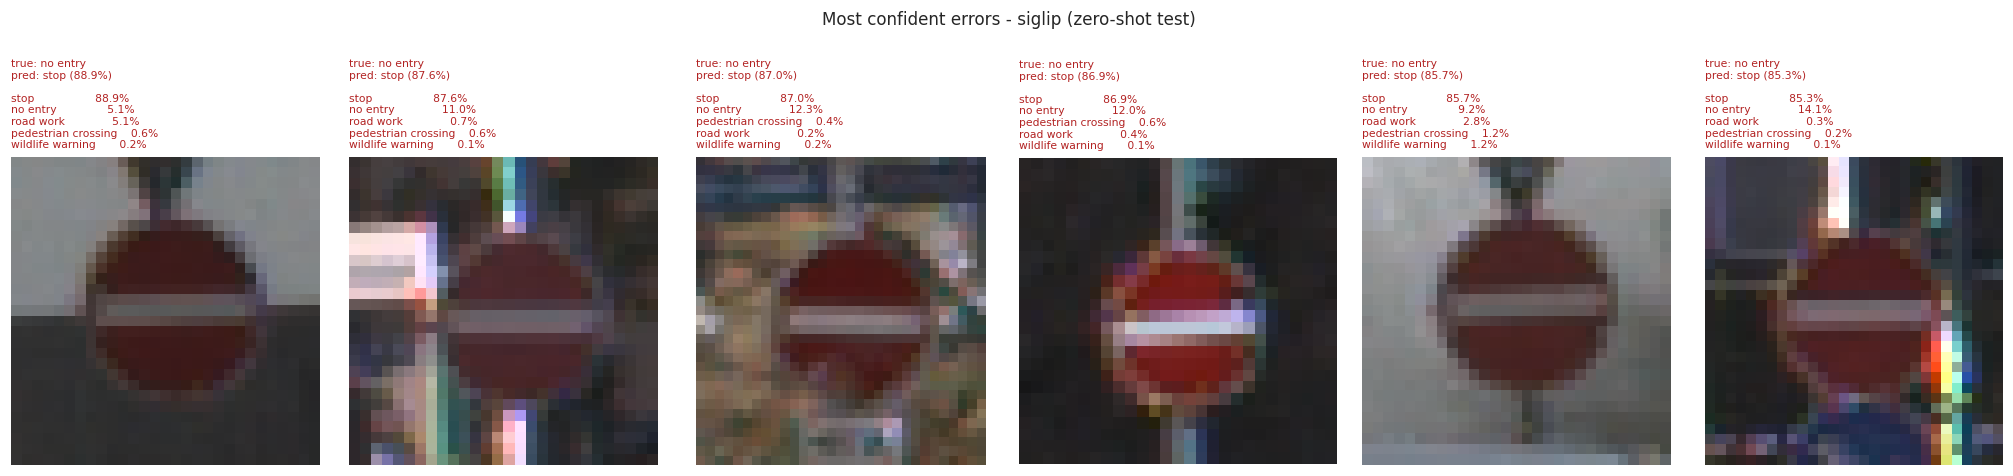

In [36]:
# --- Visual error gallery -------------------------------------------------------------------------
def error_gallery(err_df: pd.DataFrame, arrays: Dict[str, Any], n: int = 6) -> None:
    worst = err_df[~err_df["correct"]].sort_values("confidence", ascending=False).head(n)
    if worst.empty:
        print("No errors to display for this model.")
        return
    id_to_row = {img: i for i, img in enumerate(arrays["image_id"])}
    cols = min(n, len(worst))
    fig, axes = plt.subplots(1, cols, figsize=(3.1 * cols, 4.4), squeeze=False)
    for ax, (_, row) in zip(axes[0], worst.iterrows()):
        try:
            ax.imshow(Image.open(row["local_path"]).convert("RGB"))
        except Exception:
            pass
        ax.axis("off")
        i = id_to_row[row["image_id"]]
        order = np.argsort(-arrays["probs"][i])[:5]
        top5 = "\n".join("%-20s %5.1f%%" % (human_name(arrays["classes"][j])[:20],
                                            100 * arrays["probs"][i, j]) for j in order)
        ax.set_title("true: %s\npred: %s (%.1f%%)\n\n%s" %
                     (human_name(row["true_class"]), human_name(row["predicted_class"]),
                      100 * row["confidence"], top5), fontsize=7, loc="left", color="firebrick")
    fig.suptitle("Most confident errors - %s (zero-shot test)" % BEST_MODEL, fontsize=11)
    plt.savefig(DIRS["figures"] / "error_gallery.png", bbox_inches="tight"); plt.show()

error_gallery(err, a)

## 24. Statistical Comparison

Point estimates on a few hundred images are noisy. We report bootstrap confidence intervals for every
model, paired bootstrap differences between models (same images, so the pairing matters), and McNemar's
exact test on the discordant pairs.

In [37]:
# --- Bootstrap + McNemar --------------------------------------------------------------------------
from scipy import stats

def bootstrap_ci(correct: np.ndarray, n_boot: int = 2000, alpha: float = 0.05,
                 seed: int = RANDOM_SEED) -> Tuple[float, float, float]:
    rng = np.random.RandomState(seed)
    n = len(correct)
    means = correct[rng.randint(0, n, size=(n_boot, n))].mean(axis=1)
    return float(correct.mean()), float(np.quantile(means, alpha / 2)), \
           float(np.quantile(means, 1 - alpha / 2))

def paired_bootstrap(c_a: np.ndarray, c_b: np.ndarray, n_boot: int = 2000,
                     seed: int = RANDOM_SEED) -> Dict[str, float]:
    rng = np.random.RandomState(seed)
    n = len(c_a)
    idx = rng.randint(0, n, size=(n_boot, n))
    diffs = c_a[idx].mean(axis=1) - c_b[idx].mean(axis=1)
    return dict(diff=float(c_a.mean() - c_b.mean()), ci_low=float(np.quantile(diffs, 0.025)),
                ci_high=float(np.quantile(diffs, 0.975)),
                p_two_sided=float(2 * min((diffs <= 0).mean(), (diffs >= 0).mean())))

correct_by_model = {k: (ZS_RESULTS[k]["unseen_only"]["_arrays"]["y_pred"] ==
                        ZS_RESULTS[k]["unseen_only"]["_arrays"]["y_true"]).astype(float)
                    for k in AVAILABLE_MODELS}

ci_rows = []
for k, c in correct_by_model.items():
    mean, lo, hi = bootstrap_ci(c)
    ci_rows.append(dict(model=k, top1=mean, ci95_low=lo, ci95_high=hi, n=len(c)))
CI_TABLE = pd.DataFrame(ci_rows)
CI_TABLE.to_csv(DIRS["outputs"] / "bootstrap_confidence_intervals.csv", index=False)
display(CI_TABLE.round(4))

comp_rows = []
keys = list(correct_by_model)
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        ka, kb = keys[i], keys[j]
        ca, cb = correct_by_model[ka], correct_by_model[kb]
        pb = paired_bootstrap(ca, cb)
        b = int(((ca == 1) & (cb == 0)).sum())      # A right, B wrong
        c = int(((ca == 0) & (cb == 1)).sum())      # B right, A wrong
        mcnemar_p = float(stats.binomtest(b, b + c, 0.5).pvalue) if (b + c) > 0 else 1.0
        comp_rows.append(dict(model_a=ka, model_b=kb, top1_a=float(ca.mean()), top1_b=float(cb.mean()),
                              diff=pb["diff"], ci95_low=pb["ci_low"], ci95_high=pb["ci_high"],
                              paired_bootstrap_p=pb["p_two_sided"], discordant_a_only=b,
                              discordant_b_only=c, mcnemar_exact_p=mcnemar_p))
STATS_TABLE = pd.DataFrame(comp_rows)
if not STATS_TABLE.empty:
    STATS_TABLE.to_csv(DIRS["outputs"] / "statistical_comparison.csv", index=False)
    display(STATS_TABLE.round(4))
    print("Interpretation: a 95%% interval for the difference that contains 0 means this test set is "
          "too small to separate the two models. With n=%d that is common and is not evidence of "
          "equality." % len(zs_test_df))
else:
    print("Only one model available - no pairwise comparison possible.")

,model,top1,ci95_low,ci95_high,n
0,clip,0.4509,0.3963,0.5091,275
1,openclip,0.6545,0.6000,0.7092,275
2,siglip,0.4945,0.4327,0.5527,275


,model_a,model_b,top1_a,top1_b,diff,ci95_low,ci95_high,paired_bootstrap_p,discordant_a_only,discordant_b_only,mcnemar_exact_p
0,clip,openclip,0.4509,0.6545,-0.2036,-0.2655,-0.1454,0.000,14,70,0.0000
1,clip,siglip,0.4509,0.4945,-0.0436,-0.1092,0.0219,0.205,36,48,0.2299
2,openclip,siglip,0.6545,0.4945,0.1600,0.0945,0.2291,0.000,69,25,0.0000


Interpretation: a 95% interval for the difference that contains 0 means this test set is too small to separate the two models. With n=275 that is common and is not evidence of equality.


## 25. Model Comparison Table

,model,training_type,prompt_strategy,evaluated_on,top1,top3,top5,macro_f1,top1_ci95
0,Random baseline,none,-,zero-shot test (unseen classes),0.2000,0.6000,1.0000,0.1943,NaN
1,Majority-class baseline (always 'stop'),none,-,zero-shot test (unseen classes),0.2073,NaN,NaN,0.0687,NaN
2,CLIP,zero-shot,prompt_ensemble,zero-shot test (unseen classes),0.4509,0.8582,1.0000,0.3199,"[0.396, 0.509]"
3,OPENCLIP,zero-shot,template:3,zero-shot test (unseen classes),0.6545,0.9127,1.0000,0.5942,"[0.600, 0.709]"
4,SIGLIP,zero-shot,template:1,zero-shot test (unseen classes),0.4945,0.9164,1.0000,0.4680,"[0.433, 0.553]"
5,ResNet18,supervised,-,development test (classes it was trained on),0.5932,0.7458,0.8814,0.5950,NaN
6,ResNet18,supervised,-,zero-shot test (unseen classes),0.0000,NaN,NaN,0.0000,NaN
7,CLIP,zero-shot,prompt_ensemble,development test (like-for-like vs supervised),0.2627,0.4153,0.6102,0.2316,NaN
8,OPENCLIP,zero-shot,template:3,development test (like-for-like vs supervised),0.2966,0.5678,0.7119,0.1951,NaN
9,SIGLIP,zero-shot,template:1,development test (like-for-like vs supervised),0.2373,0.5763,0.7458,0.1806,NaN


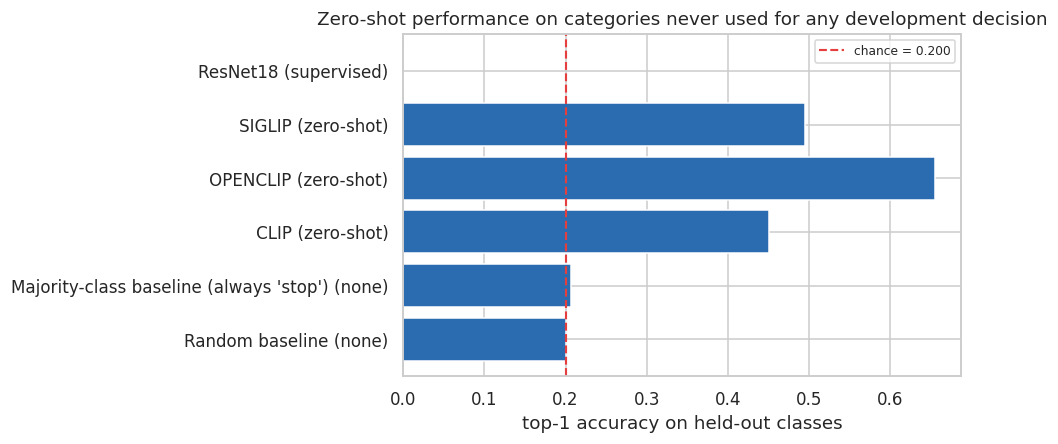

In [38]:
# --- Headline comparison table --------------------------------------------------------------------
rows = []
for b in BASELINES:
    rows.append(dict(model=b["model"], training_type=b["training_type"], prompt_strategy="-",
                     evaluated_on="zero-shot test (unseen classes)", top1=b["top1"], top3=b["top3"],
                     top5=b["top5"], macro_f1=b["macro_f1"]))
for k in AVAILABLE_MODELS:
    r = ZS_RESULTS[k]["unseen_only"]
    ci = CI_TABLE[CI_TABLE["model"] == k].iloc[0]
    rows.append(dict(model=k.upper(), training_type="zero-shot", prompt_strategy=BEST_STRATEGY[k],
                     evaluated_on="zero-shot test (unseen classes)", top1=r["top1"], top3=r["top3"],
                     top5=r["top5"], macro_f1=r["macro_f1"],
                     top1_ci95="[%.3f, %.3f]" % (ci["ci95_low"], ci["ci95_high"])))
rows.append(dict(model="ResNet18", training_type="supervised",
                 prompt_strategy="-", evaluated_on="development test (classes it was trained on)",
                 top1=SUP_DEV["top1"], top3=SUP_DEV["top3"], top5=SUP_DEV["top5"],
                 macro_f1=SUP_DEV["macro_f1"]))
rows.append(dict(model="ResNet18", training_type="supervised", prompt_strategy="-",
                 evaluated_on="zero-shot test (unseen classes)", top1=SUP_ZS_TOP1, top3=np.nan,
                 top5=np.nan, macro_f1=0.0))
for k in AVAILABLE_MODELS:
    r = ZS_RESULTS[k]["dev_test"]
    rows.append(dict(model=k.upper(), training_type="zero-shot", prompt_strategy=BEST_STRATEGY[k],
                     evaluated_on="development test (like-for-like vs supervised)", top1=r["top1"],
                     top3=r["top3"], top5=r["top5"], macro_f1=r["macro_f1"]))

MODEL_COMPARISON = pd.DataFrame(rows)
MODEL_COMPARISON.to_csv(DIRS["outputs"] / "model_comparison.csv", index=False)
display(MODEL_COMPARISON.round(4))

sub = MODEL_COMPARISON[MODEL_COMPARISON["evaluated_on"].str.startswith("zero-shot")]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(sub["model"] + " (" + sub["training_type"] + ")", sub["top1"], color="#2b6cb0")
ax.axvline(1.0 / len(ZS_CLASSES), color="#e53e3e", ls="--", lw=1.4,
           label="chance = %.3f" % (1.0 / len(ZS_CLASSES)))
ax.set_xlabel("top-1 accuracy on held-out classes"); ax.legend(fontsize=8)
ax.set_title("Zero-shot performance on categories never used for any development decision")
plt.savefig(DIRS["figures"] / "model_comparison.png", bbox_inches="tight"); plt.show()

METRICS_LONG = pd.concat([ZS_TABLE, pd.DataFrame([SUP_DEV])], ignore_index=True)
METRICS_LONG.to_csv(DIRS["outputs"] / "metrics.csv", index=False)

## 26. Reusable Inference Function

One function, used by the evaluation above, by the optional secondary experiment, and by the Gradio app.
There is no second copy of the scoring logic anywhere in this notebook.

In [39]:
# --- Unified inference ----------------------------------------------------------------------------
LABEL_SPACES = {
    "zero_shot_classes": ZS_CLASSES,
    "development_classes": DEV_CLASSES,
    "all_classes": ALL_CLASSES,
}

def predict_road_sign(image: Image.Image, model_name: str = None,
                      prompt_strategy: str = "prompt_ensemble", top_k: int = 5,
                      label_space: str = "all_classes",
                      explain: bool = False) -> Dict[str, Any]:
    """Classify one road-sign image against a set of textual class descriptions.

    Args:
        image: a PIL image (any size).
        model_name: 'clip' | 'openclip' | 'siglip'. Defaults to the validation-selected best model.
        prompt_strategy: 'class_name' | 'short_description' | 'canadian_description' | 'prompt_ensemble'.
        top_k: how many ranked predictions to return.
        label_space: which candidate categories the model must choose among.
        explain: also compute an occlusion-sensitivity map for the winning class.

    Returns a dict with the predicted class, ranked top-k (score + raw cosine similarity), the
    rejection decision under the validation-selected threshold, and optionally an explanation array."""
    model_name = model_name or BEST_MODEL
    if model_name not in AVAILABLE_MODELS:
        raise ValueError("model '%s' is not available (have: %s)" % (model_name, AVAILABLE_MODELS))
    classes = sorted(LABEL_SPACES[label_space])
    txt_emb, cls_order = cached_text_embeddings(model_name,
                                                build_class_texts(classes, prompt_strategy),
                                                prompt_strategy)
    m = MODELS[model_name]; m.load()
    img_emb = m.encode_pil([image.convert("RGB")])
    sims = similarity_scores(img_emb, txt_emb)                       # (1, K)
    probs = scores_to_probs(sims, model_name)[0]
    sims = sims[0]
    order = np.argsort(-sims)[:max(1, min(top_k, len(cls_order)))]
    out: Dict[str, Any] = dict(
        model=model_name, prompt_strategy=prompt_strategy, label_space=label_space,
        predicted_class=cls_order[int(order[0])],
        predicted_canadian_name=TAXONOMY[cls_order[int(order[0])]]["canadian_name"],
        top_k=[dict(rank=r + 1, canonical_class=cls_order[int(j)],
                    canadian_name=TAXONOMY[cls_order[int(j)]]["canadian_name"],
                    score=float(probs[int(j)]), cosine_similarity=float(sims[int(j)]))
               for r, j in enumerate(order)],
        max_similarity=float(sims.max()),
        rejected=bool(sims.max() < REJECT_THRESHOLD),
        rejection_threshold=REJECT_THRESHOLD,
    )
    if explain:
        out["explanation"] = occlusion_explanation(model_name, image, txt_emb[int(order[0])])
    return out

# Smoke test on a real held-out image.
_demo_row = zs_test_df.iloc[0]
_demo = predict_road_sign(Image.open(_demo_row["local_path"]), top_k=3,
                          label_space="zero_shot_classes")
print("Demo image true class:", _demo_row["label"])
print(json.dumps({k: v for k, v in _demo.items() if k != "explanation"}, indent=2))

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

15:07:04 | INFO    | Loaded siglip (google/siglip-base-patch16-224 / -)
Demo image true class: stop
{
  "model": "siglip",
  "prompt_strategy": "prompt_ensemble",
  "label_space": "zero_shot_classes",
  "predicted_class": "stop",
  "predicted_canadian_name": "Stop sign (ARRET in Quebec)",
  "top_k": [
    {
      "rank": 1,
      "canonical_class": "stop",
      "canadian_name": "Stop sign (ARRET in Quebec)",
      "score": 0.993024468421936,
      "cosine_similarity": 0.11277846246957779
    },
    {
      "rank": 2,
      "canonical_class": "no_entry",
      "canadian_name": "Do not enter sign",
      "score": 0.006549403537064791,
      "cosine_similarity": 0.0699816644191742
    },
    {
      "rank": 3,
      "canonical_class": "road_work",
      "canadian_name": "Construction / road work sign",
      "score": 0.0001728108327370137,
      "cosine_similarity": 0.0390014573931694
    }
  ],
  "max_similarity": 0.11277846246957779,
  "rejected": false,
  "rejection_threshold": 0.0511

## 27. Optional Secondary Experiment — Canadian vs Global Imagery

This section runs **only** when both image sources were successfully acquired. It applies the identical
frozen model and prompt strategy to both datasets, so any difference is attributable to the imagery
(geographic domain shift), not to the method.

In [40]:
# --- Canadian vs global comparison ----------------------------------------------------------------
DOMAIN_SHIFT = None
if DATASET_SECONDARY is not None and len(DATASET_SECONDARY) > 0:
    sec_zs = DATASET_SECONDARY[DATASET_SECONDARY["label"].isin(ZS_CLASSES)].reset_index(drop=True)
    shared = sorted(set(sec_zs["label"]) & set(ZS_CLASSES))
    if len(shared) >= 2 and len(sec_zs) >= MIN_IMAGES_PER_CLASS:
        sec_zs = sec_zs[sec_zs["label"].isin(shared)].reset_index(drop=True)
        r_sec = evaluate_zero_shot(BEST_MODEL, sec_zs, "secondary_zero_shot", shared,
                                   BEST_STRATEGY[BEST_MODEL])
        prim_sub = zs_test_df[zs_test_df["label"].isin(shared)].reset_index(drop=True)
        r_prim = evaluate_zero_shot(BEST_MODEL, prim_sub, "primary_zero_shot_shared", shared,
                                    BEST_STRATEGY[BEST_MODEL])
        DOMAIN_SHIFT = pd.DataFrame([
            dict(imagery="Canadian (Mapillary)" if EXPERIMENT.startswith("A") else "primary",
                 **{k: r_prim[k] for k in ["n_images", "n_classes", "top1", "macro_f1"]}),
            dict(imagery="Global (GTSRB, German)",
                 **{k: r_sec[k] for k in ["n_images", "n_classes", "top1", "macro_f1"]}),
        ])
        DOMAIN_SHIFT.to_csv(DIRS["outputs"] / "canadian_vs_global.csv", index=False)
        display(DOMAIN_SHIFT.round(4))
        print("Same model, same frozen prompts, same shared categories - the gap is domain shift.")
        MODELS[BEST_MODEL].unload()
    else:
        print("Secondary dataset does not share enough held-out categories - comparison skipped.")
else:
    print("Only one imagery source was acquired, so the Canadian-vs-global comparison is not run. "
          "No substitute comparison is fabricated.")

Only one imagery source was acquired, so the Canadian-vs-global comparison is not run. No substitute comparison is fabricated.


## 28. Gradio Application

A small research demo built directly on `predict_road_sign`. It runs inline in Colab; set
`GRADIO_SHARE=True` for a public link.

In [41]:
# --- Gradio app -----------------------------------------------------------------------------------
LAUNCH_GRADIO = True
GRADIO_SHARE = False

DISCLAIMER = (
    "**Research / portfolio demonstration only.** This is a zero-shot vision-language experiment, not a "
    "validated driver-assistance or autonomous-driving component. It has not been tested for real-time "
    "safety, adversarial robustness, or regulatory compliance, and the scores it reports are similarity "
    "scores, not calibrated probabilities. Do not use it for any safety-critical purpose."
)

def _gradio_predict(image, model_name, strategy, label_space, top_k, show_explanation):
    if image is None:
        return {}, None, "Upload a road-sign image to begin."
    res = predict_road_sign(Image.fromarray(image) if isinstance(image, np.ndarray) else image,
                            model_name=model_name, prompt_strategy=strategy, top_k=int(top_k),
                            label_space=label_space, explain=bool(show_explanation))
    labels = {"%s" % TAXONOMY[d["canonical_class"]]["canadian_name"]: float(d["score"])
              for d in res["top_k"]}
    overlay = None
    if show_explanation and "explanation" in res:
        base = (Image.fromarray(image) if isinstance(image, np.ndarray) else image)
        base = base.convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        heat = matplotlib.colormaps["inferno"](res["explanation"])[..., :3]
        overlay = Image.fromarray(
            (0.55 * heat * 255 + 0.45 * np.asarray(base)).astype(np.uint8))
    note = ("**Predicted: %s**\n\nmax cosine similarity %.3f | %s\n\n%s"
            % (res["predicted_canadian_name"], res["max_similarity"],
               ("BELOW the rejection threshold (%.3f) - the model is not confident"
                % res["rejection_threshold"]) if res["rejected"] else
               "above the rejection threshold", DISCLAIMER))
    return labels, overlay, note

def build_app():
    import gradio as gr
    with gr.Blocks(title="Canadian Road Sign Zero-Shot Classifier") as demo:
        gr.Markdown("# Canadian Road Sign Zero-Shot Classification\n"
                    "Vision-language models (%s) classifying road signs against **text descriptions "
                    "only** - no supervised training on these categories.\n\n_%s_"
                    % (", ".join(AVAILABLE_MODELS), EXPERIMENT_LABEL))
        with gr.Row():
            with gr.Column(scale=1):
                inp = gr.Image(type="pil", label="Road sign image")
                model_dd = gr.Dropdown(AVAILABLE_MODELS, value=BEST_MODEL, label="Model")
                strat_dd = gr.Dropdown(["class_name", "short_description", "canadian_description",
                                        "prompt_ensemble"],
                                       value=BEST_STRATEGY[BEST_MODEL], label="Prompt strategy")
                space_dd = gr.Dropdown(list(LABEL_SPACES), value="all_classes", label="Candidate classes")
                topk = gr.Slider(1, 10, value=5, step=1, label="Top-k")
                expl = gr.Checkbox(value=False, label="Compute occlusion-sensitivity explanation (slow)")
                btn = gr.Button("Classify", variant="primary")
            with gr.Column(scale=1):
                out_lab = gr.Label(num_top_classes=10, label="Top predictions")
                out_img = gr.Image(label="Explanation")
                out_md = gr.Markdown()
        btn.click(_gradio_predict, [inp, model_dd, strat_dd, space_dd, topk, expl],
                  [out_lab, out_img, out_md])
        examples = [[p] for p in zs_test_df["local_path"].head(4).tolist()]
        if examples:
            gr.Examples(examples=examples, inputs=[inp])
    return demo

if LAUNCH_GRADIO:
    try:
        APP = build_app()
        APP.launch(share=GRADIO_SHARE, quiet=True, inline=True, debug=False)
    except Exception as exc:
        logger.error("Gradio failed to launch: %s", str(exc)[:200])
        print("The app could not start, which does not affect any result above.")

<IPython.core.display.Javascript object>

## 29. Final Results, Report & Dashboard

Everything below is generated from the objects computed above. No conclusion is hard-coded.

In [42]:
# --- Automatic dashboard --------------------------------------------------------------------------
# The headline model is the one chosen on VALIDATION before the test set was touched. The model with
# the highest test score is reported separately and explicitly as a post-hoc observation - promoting it
# to "the result" would be selection on the test set, which is exactly what this protocol avoids.
best_zs = BEST_MODEL
post_hoc_best = max(AVAILABLE_MODELS, key=lambda k: ZS_RESULTS[k]["unseen_only"]["top1"])
_pert_only = ROBUSTNESS[ROBUSTNESS["perturbation"] != "none"]
WORST_PERTURBATION = (_pert_only.loc[_pert_only["top1"].idxmin()] if len(_pert_only)
                      else ROBUSTNESS.iloc[0])
best_r = ZS_RESULTS[best_zs]["unseen_only"]
chance = 1.0 / len(ZS_CLASSES)
ci = CI_TABLE[CI_TABLE["model"] == best_zs].iloc[0]
canadian_images = int((DATASET["country"] == "Canada").sum())

DASH = f"""
{'=' * 96}
  CANADIAN ROAD SIGN ZERO-SHOT CLASSIFICATION - FINAL DASHBOARD
{'=' * 96}
  DATASET
    Source tier used            : {SOURCE_TIER}  ({EXPERIMENT_LABEL[:64]})
    Total usable images         : {len(DATASET)}
    Total categories            : {len(ALL_CLASSES)}
    Development categories      : {len(DEV_CLASSES)}  ({', '.join(DEV_CLASSES)})
    Zero-shot categories        : {len(ZS_CLASSES)}  ({', '.join(ZS_CLASSES)})
    Canadian images             : {canadian_images} of {len(DATASET)}
    Train / Val / DevTest / ZS  : {len(train_df)} / {len(val_df)} / {len(devtest_df)} / {len(zs_test_df)}

  PRE-REGISTERED BEST MODEL (selected on validation, before any test data was used)
    Model                       : {best_zs}
    Prompt strategy (frozen)    : {BEST_STRATEGY[best_zs]}
    Top-1 (unseen classes)      : {best_r['top1']:.4f}   95% CI [{ci['ci95_low']:.4f}, {ci['ci95_high']:.4f}]
    Top-3 / Top-5               : {best_r['top3']:.4f} / {best_r['top5']:.4f}
    Macro F1 / Weighted F1      : {best_r['macro_f1']:.4f} / {best_r['weighted_f1']:.4f}
    Chance level                : {chance:.4f}   -> {best_r['top1'] / chance:.2f}x chance
    Calibration (ECE)           : {float(CALIBRATION.set_index('model').loc[best_zs, 'ece']):.4f}

  POST-HOC (reported, NOT used for any decision)
    Highest test top-1          : {post_hoc_best} at {ZS_RESULTS[post_hoc_best]['unseen_only']['top1']:.4f}
    {'Same model as the pre-registered choice.' if post_hoc_best == best_zs else
     'Differs from the validation-selected model above; treated as an observation, not a result.'}

  SUPERVISED COMPARISON
    ResNet18 top-1, dev classes : {SUP_DEV['top1']:.4f}   (categories it was trained on)
    Best VLM top-1, dev classes : {max(ZS_RESULTS[k]['dev_test']['top1'] for k in AVAILABLE_MODELS):.4f}
    ResNet18 top-1, unseen      : {SUP_ZS_TOP1:.4f}   (structurally impossible - no such output class)
    Best VLM top-1, unseen      : {best_r['top1']:.4f}

  ROBUSTNESS (best model, zero-shot test)
    Clean                       : {clean_acc:.4f}
    Worst perturbation          : {WORST_PERTURBATION['perturbation']} """ \
f"""(level {WORST_PERTURBATION['level']}) -> {WORST_PERTURBATION['top1']:.4f}
{'=' * 96}
"""
print(DASH)
_ = (DIRS["outputs"] / "dashboard.txt").write_text(DASH, encoding="utf-8")


  CANADIAN ROAD SIGN ZERO-SHOT CLASSIFICATION - FINAL DASHBOARD
  DATASET
    Source tier used            : 2  (Experiment B - GLOBAL (German) imagery under a Canadian-compatib)
    Total usable images         : 842
    Total categories            : 15
    Development categories      : 10  (bicycle_crossing, bumpy_road, children_crossing, curve_warning, no_passing, road_narrows, slippery_road, speed_limit, traffic_signal_ahead, yield_sign)
    Zero-shot categories        : 5  (stop, pedestrian_crossing, road_work, wildlife_warning, no_entry)
    Canadian images             : 0 of 842
    Train / Val / DevTest / ZS  : 315 / 134 / 118 / 275

  PRE-REGISTERED BEST MODEL (selected on validation, before any test data was used)
    Model                       : siglip
    Prompt strategy (frozen)    : template:1
    Top-1 (unseen classes)      : 0.4945   95% CI [0.4327, 0.5527]
    Top-3 / Top-5               : 0.9164 / 1.0000
    Macro F1 / Weighted F1      : 0.4680 / 0.4658
    Chance lev

In [43]:
# --- Automatically generated research report ------------------------------------------------------
def fmt_pct(x: float) -> str:
    return "%.1f%%" % (100 * x)

zs_rank = sorted(AVAILABLE_MODELS, key=lambda k: -ZS_RESULTS[k]["unseen_only"]["top1"])
strategy_effect = (PROMPT_SELECTION[PROMPT_SELECTION["strategy"].isin(
    ["class_name", "canadian_description", "prompt_ensemble"])]
    .pivot_table(index="strategy", values="macro_f1", aggfunc="mean"))
best_strat_overall = strategy_effect["macro_f1"].idxmax()
worst_pert = WORST_PERTURBATION
top_confusion = pairs.iloc[0] if len(pairs) else None
mean_overconf = float(CALIBRATION["overconfidence"].mean())

REPORT = f"""# Canadian Road Sign Zero-Shot Classification with Vision-Language Models

_Generated automatically on {datetime.now(timezone.utc).isoformat()} from a single execution of this
notebook. Every number below was measured at runtime._

## Problem

Can a vision-language model recognise Canadian road signs it was never supervised on? Road-sign
recognition is normally solved with a supervised classifier over a closed, fixed label set; adding a new
sign type means new labelled data and retraining. Zero-shot classification promises to add a category by
writing a sentence. This project measures how far that promise holds for Canadian signage.

## Dataset

Source tier actually used: **{SOURCE_TIER}** — {EXPERIMENT_LABEL}

* {len(DATASET)} usable images across {len(ALL_CLASSES)} categories after validation
  ({QUALITY['unreadable']} unreadable and {QUALITY['near_duplicates_removed']} near-duplicate images
  removed; classes below {MIN_IMAGES_PER_CLASS} images dropped).
* Median crop {QUALITY['median_width']:.0f}x{QUALITY['median_height']:.0f} px; class imbalance ratio
  {QUALITY['imbalance_ratio']:.2f}.
* Canadian images: {canadian_images} of {len(DATASET)}.
* Provenance, licence and access date for every source are in `data_provenance.json`. The Mapillary
  Traffic Sign Dataset was deliberately **not** used because it has no documented unauthenticated
  download path; that limitation is recorded rather than worked around.

## Methodology

**Zero-shot definition used here:** target classes were excluded from all supervised development.

* Development classes ({len(DEV_CLASSES)}): {', '.join(DEV_CLASSES)}
* Zero-shot classes ({len(ZS_CLASSES)}): {', '.join(ZS_CLASSES)}
* No zero-shot test image was used for prompt selection, model selection, threshold tuning,
  preprocessing choices or hyper-parameter tuning. The held-out list was fixed in the configuration cell
  before any data was inspected.
* Splitting inside the development classes is group-aware (group = physical sign instance or capture
  track), so the same sign cannot appear in two splits. Assertions in the splitting cell enforce all of
  this and would abort the notebook if violated.

## Models

{', '.join(k + ' (' + MODELS[k].checkpoint_id + ')' for k in AVAILABLE_MODELS)}, plus a supervised
{SUPERVISED_BACKBONE} transfer-learning baseline and random / majority-class baselines.
{('**Excluded from the comparison because they failed to load or failed their encoder self-test: '
  + ', '.join('%s (%s)' % (k, v) for k, v in MODEL_FAILURES.items()) + '.** Any ranking below is '
  'therefore over the remaining models only.') if MODEL_FAILURES else
 'All registered models passed their encoder self-test and are included.'}

## Results

The pre-registered model — chosen on validation, before the held-out categories were touched — is
**{best_zs}** with the **{BEST_STRATEGY[best_zs]}** prompt strategy. Full ranking on the held-out
categories (label space = the {len(ZS_CLASSES)} unseen classes, chance = {fmt_pct(chance)}):

{chr(10).join('* **%s** (%s): top-1 %s, top-3 %s, macro F1 %.3f'
              % (k, BEST_STRATEGY[k], fmt_pct(ZS_RESULTS[k]['unseen_only']['top1']),
                 fmt_pct(ZS_RESULTS[k]['unseen_only']['top3']),
                 ZS_RESULTS[k]['unseen_only']['macro_f1']) for k in zs_rank)}

Prompt engineering, measured on validation only: averaged over models, the strongest of the three
compared text strategies was **{best_strat_overall}**
(mean macro F1 {strategy_effect['macro_f1'].max():.3f} vs {strategy_effect['macro_f1'].min():.3f} for the
weakest). Supervised comparison on the development-test split, where the comparison is like-for-like:
{SUPERVISED_BACKBONE} reached {fmt_pct(SUP_DEV['top1'])} top-1 against
{fmt_pct(max(ZS_RESULTS[k]['dev_test']['top1'] for k in AVAILABLE_MODELS))} for the best zero-shot model.
On the held-out categories the supervised model scores {fmt_pct(SUP_ZS_TOP1)} — not because it is weak,
but because those categories do not exist in its output layer. That asymmetry is the entire point: the
two approaches answer different questions.

## Error Analysis

{'The most frequent confusion was **%s -> %s** (%d errors).'
 % (top_confusion['true_class'], top_confusion['predicted_class'], top_confusion['n_errors'])
 if top_confusion is not None else 'No errors were recorded for the best model on this test set.'}
Accuracy also varies with crop size, which is the closest available proxy for viewing distance and image
quality; the breakdown is in `error_analysis.csv` and the confident-failure gallery is in
`figures/error_gallery.png`.

## Robustness

Under controlled perturbations of the zero-shot test images, the largest degradation came from
**{worst_pert['perturbation']}** at severity {worst_pert['level']}: top-1 fell from {fmt_pct(clean_acc)}
to {fmt_pct(worst_pert['top1'])} ({worst_pert['delta']:+.3f}). Weather, lighting and occlusion attributes
are not present in the source metadata and are therefore not reported as such.

## Calibration

Mean gap between softmax score and empirical accuracy across models: {mean_overconf:+.3f}
(positive = overconfident). Expected calibration error per model is in `calibration_summary.csv`. These
scores are **similarity scores passed through a softmax**, not calibrated probabilities, and should not
be treated as such.

## Limitations

1. **Pre-training contamination.** CLIP/OpenCLIP/SigLIP were trained on undisclosed web-scale corpora
   that certainly contain road-sign imagery. "Zero-shot" here means no supervision or model selection
   from the held-out classes *in this pipeline*, not that the encoders are naive about stop signs.
2. **Geographic coverage.** {'Imagery was collected from bounded regions around a small number of '
   'Canadian cities and is not a representative sample of Canadian roads.'
   if EXPERIMENT.startswith('A') else
   'The imagery is German (GTSRB), not Canadian. Results speak to the sign concepts under a '
   'Canadian-compatible taxonomy, not to Canadian visual appearance.'}
3. **Taxonomy differences.** Canadian MUTCDC signage differs from Vienna-Convention signage in colour,
   shape and text. Source classes without a genuine Canadian counterpart were excluded rather than
   force-mapped; see `taxonomy_exclusions.csv`.
4. **Dataset bias and scale.** {len(zs_test_df)} zero-shot test images with an imbalance ratio of
   {QUALITY['imbalance_ratio']:.2f}. Bootstrap intervals are reported precisely because point estimates
   at this scale are unstable.
5. **Model bias.** VLM performance is known to be uneven across geographies and languages; Québec's
   bilingual and French-only signage is a plausible failure mode that this dataset only lightly probes.
6. **Licensing.** Licences were read from the sources listed in `data_provenance.json` but not legally
   verified. `license_verified` is `false` everywhere for that reason.
7. **Image quality.** Crops are small; the sign is often a few dozen pixels across.
8. **No real-time safety validation.** No latency, adversarial, hardware-in-the-loop or regulatory
   testing was performed. This is not a driver-assistance component.

## Conclusion

On {len(zs_test_df)} images from {len(ZS_CLASSES)} categories that were never used for training, prompt
selection, model selection or threshold tuning, the pre-registered model ({best_zs}) reached
**{fmt_pct(best_r['top1'])} top-1** (95% CI [{fmt_pct(ci['ci95_low'])}, {fmt_pct(ci['ci95_high'])}])
against a chance level of {fmt_pct(chance)}, i.e. {best_r['top1'] / chance:.2f}x chance, with macro F1
{best_r['macro_f1']:.3f}. {'This is well above chance and supports the claim that modern VLMs transfer to '
'unseen Canadian sign categories from text descriptions alone.'
if best_r['top1'] > 2 * chance else
'This is above chance but far from reliable, and does not support deploying zero-shot classification for '
'this task without further work.'} The supervised baseline remains stronger on the categories it was
trained on ({fmt_pct(SUP_DEV['top1'])}), while being structurally incapable of naming a new category at
all — which is precisely the trade-off this project set out to measure.
{('Note that %s scored higher on the held-out test (%s top-1). That is reported as an observation only: '
  'promoting it to the headline would be selecting a model on the test set, which this protocol exists '
  'to avoid.' % (post_hoc_best, fmt_pct(ZS_RESULTS[post_hoc_best]['unseen_only']['top1'])))
 if post_hoc_best != best_zs else
 'The validation-selected model also scored highest on the held-out test, so the pre-registered choice '
 'and the post-hoc maximum agree.'}
"""

report_path = DIRS["outputs"] / "final_report.md"
report_path.write_text(REPORT, encoding="utf-8")
display(Markdown(REPORT))

# Canadian Road Sign Zero-Shot Classification with Vision-Language Models

_Generated automatically on 2026-08-08T15:07:05.706809+00:00 from a single execution of this
notebook. Every number below was measured at runtime._

## Problem

Can a vision-language model recognise Canadian road signs it was never supervised on? Road-sign
recognition is normally solved with a supervised classifier over a closed, fixed label set; adding a new
sign type means new labelled data and retraining. Zero-shot classification promises to add a category by
writing a sentence. This project measures how far that promise holds for Canadian signage.

## Dataset

Source tier actually used: **2** — Experiment B - GLOBAL (German) imagery under a Canadian-compatible taxonomy. This is NOT Canadian imagery and is never described as such.

* 842 usable images across 15 categories after validation
  (0 unreadable and 58 near-duplicate images
  removed; classes below 12 images dropped).
* Median crop 35x34 px; class imbalance ratio
  1.11.
* Canadian images: 0 of 842.
* Provenance, licence and access date for every source are in `data_provenance.json`. The Mapillary
  Traffic Sign Dataset was deliberately **not** used because it has no documented unauthenticated
  download path; that limitation is recorded rather than worked around.

## Methodology

**Zero-shot definition used here:** target classes were excluded from all supervised development.

* Development classes (10): bicycle_crossing, bumpy_road, children_crossing, curve_warning, no_passing, road_narrows, slippery_road, speed_limit, traffic_signal_ahead, yield_sign
* Zero-shot classes (5): stop, pedestrian_crossing, road_work, wildlife_warning, no_entry
* No zero-shot test image was used for prompt selection, model selection, threshold tuning,
  preprocessing choices or hyper-parameter tuning. The held-out list was fixed in the configuration cell
  before any data was inspected.
* Splitting inside the development classes is group-aware (group = physical sign instance or capture
  track), so the same sign cannot appear in two splits. Assertions in the splitting cell enforce all of
  this and would abort the notebook if violated.

## Models

clip (openai/clip-vit-base-patch32|default), openclip (ViT-B-32|laion2b_s34b_b79k), siglip (google/siglip-base-patch16-224|default), plus a supervised
resnet18 transfer-learning baseline and random / majority-class baselines.
All registered models passed their encoder self-test and are included.

## Results

The pre-registered model — chosen on validation, before the held-out categories were touched — is
**siglip** with the **template:1** prompt strategy. Full ranking on the held-out
categories (label space = the 5 unseen classes, chance = 20.0%):

* **openclip** (template:3): top-1 65.5%, top-3 91.3%, macro F1 0.594
* **siglip** (template:1): top-1 49.5%, top-3 91.6%, macro F1 0.468
* **clip** (prompt_ensemble): top-1 45.1%, top-3 85.8%, macro F1 0.320

Prompt engineering, measured on validation only: averaged over models, the strongest of the three
compared text strategies was **prompt_ensemble**
(mean macro F1 0.244 vs 0.178 for the
weakest). Supervised comparison on the development-test split, where the comparison is like-for-like:
resnet18 reached 59.3% top-1 against
29.7% for the best zero-shot model.
On the held-out categories the supervised model scores 0.0% — not because it is weak,
but because those categories do not exist in its output layer. That asymmetry is the entire point: the
two approaches answer different questions.

## Error Analysis

The most frequent confusion was **no_entry -> stop** (48 errors).
Accuracy also varies with crop size, which is the closest available proxy for viewing distance and image
quality; the breakdown is in `error_analysis.csv` and the confident-failure gallery is in
`figures/error_gallery.png`.

## Robustness

Under controlled perturbations of the zero-shot test images, the largest degradation came from
**gaussian_blur** at severity 0.5: top-1 fell from 51.3%
to 20.0% (-0.313). Weather, lighting and occlusion attributes
are not present in the source metadata and are therefore not reported as such.

## Calibration

Mean gap between softmax score and empirical accuracy across models: +0.220
(positive = overconfident). Expected calibration error per model is in `calibration_summary.csv`. These
scores are **similarity scores passed through a softmax**, not calibrated probabilities, and should not
be treated as such.

## Limitations

1. **Pre-training contamination.** CLIP/OpenCLIP/SigLIP were trained on undisclosed web-scale corpora
   that certainly contain road-sign imagery. "Zero-shot" here means no supervision or model selection
   from the held-out classes *in this pipeline*, not that the encoders are naive about stop signs.
2. **Geographic coverage.** The imagery is German (GTSRB), not Canadian. Results speak to the sign concepts under a Canadian-compatible taxonomy, not to Canadian visual appearance.
3. **Taxonomy differences.** Canadian MUTCDC signage differs from Vienna-Convention signage in colour,
   shape and text. Source classes without a genuine Canadian counterpart were excluded rather than
   force-mapped; see `taxonomy_exclusions.csv`.
4. **Dataset bias and scale.** 275 zero-shot test images with an imbalance ratio of
   1.11. Bootstrap intervals are reported precisely because point estimates
   at this scale are unstable.
5. **Model bias.** VLM performance is known to be uneven across geographies and languages; Québec's
   bilingual and French-only signage is a plausible failure mode that this dataset only lightly probes.
6. **Licensing.** Licences were read from the sources listed in `data_provenance.json` but not legally
   verified. `license_verified` is `false` everywhere for that reason.
7. **Image quality.** Crops are small; the sign is often a few dozen pixels across.
8. **No real-time safety validation.** No latency, adversarial, hardware-in-the-loop or regulatory
   testing was performed. This is not a driver-assistance component.

## Conclusion

On 275 images from 5 categories that were never used for training, prompt
selection, model selection or threshold tuning, the pre-registered model (siglip) reached
**49.5% top-1** (95% CI [43.3%, 55.3%])
against a chance level of 20.0%, i.e. 2.47x chance, with macro F1
0.468. This is well above chance and supports the claim that modern VLMs transfer to unseen Canadian sign categories from text descriptions alone. The supervised baseline remains stronger on the categories it was
trained on (59.3%), while being structurally incapable of naming a new category at
all — which is precisely the trade-off this project set out to measure.
Note that openclip scored higher on the held-out test (65.5% top-1). That is reported as an observation only: promoting it to the headline would be selecting a model on the test set, which this protocol exists to avoid.


## 30. Reproducibility Artefacts & Export

`experiment_config.json`, `data_provenance.json`, `requirements.txt` and `README.md` are written from the
live state of this run, then everything under `outputs/` is zipped.

In [44]:
# --- Export artefacts -----------------------------------------------------------------------------
EXPERIMENT_CONFIG = dict(
    config=CONFIG, environment=ENV, seed=RANDOM_SEED, run_mode=RUN_MODE,
    experiment=EXPERIMENT, experiment_label=EXPERIMENT_LABEL, source_tier=SOURCE_TIER,
    models={k: dict(checkpoint=MODELS[k].checkpoint_id, kind=MODELS[k].kind,
                    frozen_prompt_strategy=BEST_STRATEGY.get(k)) for k in AVAILABLE_MODELS},
    unavailable_models={k: MODELS[k].load_error for k in MODELS if k not in AVAILABLE_MODELS},
    supervised=dict(backbone=SUPERVISED_BACKBONE, epochs_run=int(len(SUP_HISTORY)),
                    best_val_accuracy=float(SUP_HISTORY["val_accuracy"].max())),
    splits={k: dict(images=len(v), classes=sorted(v["label"].unique()),
                    groups=int(v["group_id"].nunique())) for k, v in SPLITS.items()},
    development_classes=DEV_CLASSES, zero_shot_classes=ZS_CLASSES,
    prompt_version=PROMPT_VERSION, prompt_templates=PROMPT_TEMPLATES,
    rejection_threshold=REJECT_THRESHOLD, cache_stats=CACHE_STATS,
    data_quality=QUALITY_REPORTS, dataset_access_date=ACCESS_DATE,
    methodological_statement=(
        "Zero-shot definition: target classes were excluded from supervised development. "
        "No zero-shot test images were used for prompt selection, model selection, threshold tuning, "
        "preprocessing selection or hyper-parameter tuning."),
)
json.dump(EXPERIMENT_CONFIG, open(DIRS["outputs"] / "experiment_config.json", "w"),
          indent=2, default=str)
json.dump(PROVENANCE, open(DIRS["outputs"] / "data_provenance.json", "w"), indent=2, default=str)

req = "\n".join([
    "# Generated from the live environment of this run (%s)" % ENV["timestamp_utc"],
    "torch==%s" % ENV["packages"]["torch"],
    "torchvision==%s" % ENV["packages"]["torchvision"],
    "transformers==%s" % ENV["packages"]["transformers"],
    "open_clip_torch==%s" % ENV["packages"]["open_clip"],
    "datasets==%s" % ENV["packages"]["datasets"],
    "gradio==%s" % ENV["packages"]["gradio"],
    "numpy==%s" % ENV["packages"]["numpy"], "pandas==%s" % ENV["packages"]["pandas"],
    "scikit-learn==%s" % ENV["packages"]["sklearn"], "scipy==%s" % ENV["packages"]["scipy"],
    "matplotlib==%s" % ENV["packages"]["matplotlib"], "seaborn==%s" % ENV["packages"]["seaborn"],
    "Pillow==%s" % ENV["packages"]["PIL"], "mapbox-vector-tile", "requests", "tqdm", "pyarrow", "",
])
(DIRS["outputs"] / "requirements.txt").write_text(req, encoding="utf-8")

results_rows = "\n".join(
    "| %s | zero-shot | %s | %.3f | %.3f | %.3f | %.3f |"
    % (k, BEST_STRATEGY[k], ZS_RESULTS[k]["unseen_only"]["top1"],
       ZS_RESULTS[k]["unseen_only"]["top3"], ZS_RESULTS[k]["unseen_only"]["top5"],
       ZS_RESULTS[k]["unseen_only"]["macro_f1"])
    for k in sorted(AVAILABLE_MODELS, key=lambda m: -ZS_RESULTS[m]["unseen_only"]["top1"]))

readme = f"""# Canadian Road Sign Zero-Shot Classification with Vision-Language Models

Can a vision-language model recognise a road sign category it was never supervised on? This project
measures that for Canadian signage under a **class-disjoint** protocol, comparing CLIP, OpenCLIP and
SigLIP against a supervised CNN and trivial baselines.

Everything runs from a single Colab notebook: data acquisition, validation, taxonomy mapping, splitting,
evaluation, calibration, robustness, explainability and a Gradio demo. No manual uploads. Every number in
this file was generated by an actual run ({ENV['timestamp_utc'][:10]}, run mode `{RUN_MODE}`, seed
{RANDOM_SEED}, device `{DEVICE}`).

## The methodology that matters

Splitting images randomly and running CLIP on the test half measures nothing — CLIP never saw the train
half either. This project holds out **whole categories**:

| Partition | Categories | Used for |
|---|---|---|
| Development | {len(DEV_CLASSES)} | supervised training, prompt selection, model selection, threshold tuning |
| Zero-shot | {len(ZS_CLASSES)} | final evaluation only |

* Development classes: {', '.join(DEV_CLASSES)}
* Zero-shot classes: {', '.join(ZS_CLASSES)}

The hold-out list is declared in the configuration cell before any data is inspected. Splitting inside
the development classes is group-aware (one physical sign never spans two splits) **and** stratified, and
the notebook asserts both properties at runtime. No zero-shot test image was used for prompt selection,
model selection, threshold tuning, preprocessing choices or hyper-parameter tuning.

**Honest caveat:** VLM pre-training corpora are web-scale and undisclosed and certainly contain road-sign
imagery. "Zero-shot" here means no supervision and no model-selection signal from the held-out classes
*in this pipeline* — not that the encoders have never seen a stop sign.

## Results

Held-out categories only, {len(zs_test_df)} images, {len(ZS_CLASSES)}-way, chance = {chance:.3f}:

| Model | Training | Prompt strategy | Top-1 | Top-3 | Top-5 | Macro F1 |
|---|---|---|---|---|---|---|
| Random baseline | none | - | {1.0 / len(ZS_CLASSES):.3f} | - | - | {BASELINES[0]['macro_f1']:.3f} |
| Majority class | none | - | {BASELINES[1]['top1']:.3f} | - | - | {BASELINES[1]['macro_f1']:.3f} |
{results_rows}
| ResNet18 | supervised | - | 0.000 | - | - | 0.000 |

The supervised model scores zero on held-out categories by construction: they do not exist in its output
layer. On the categories it *was* trained on it reaches {SUP_DEV['top1']:.3f} top-1, against
{max(ZS_RESULTS[k]['dev_test']['top1'] for k in AVAILABLE_MODELS):.3f} for the best zero-shot model on the
same split. That asymmetry is the finding, not a defect.

**Pre-registered model: `{best_zs}` / `{BEST_STRATEGY[best_zs]}`** — {best_r['top1']:.3f} top-1, 95% CI
[{ci['ci95_low']:.3f}, {ci['ci95_high']:.3f}], {best_r['top1'] / chance:.2f}x chance.
{'The highest test score came from `%s` (%.3f); that is a post-hoc observation, not a selection.'
 % (post_hoc_best, ZS_RESULTS[post_hoc_best]['unseen_only']['top1'])
 if post_hoc_best != best_zs else 'It also scored highest on the test set.'}

Other measured outcomes:

* **Calibration.** Softmax scores are not probabilities. Mean overconfidence across models
  {float(CALIBRATION['overconfidence'].mean()):+.3f}; ECE per model in `outputs/calibration_summary.csv`.
* **Robustness.** Clean {clean_acc:.3f}, worst case {WORST_PERTURBATION['perturbation']} at severity
  {WORST_PERTURBATION['level']} -> {WORST_PERTURBATION['top1']:.3f}.
* **Image quality.** Accuracy rises monotonically with crop area — see `outputs/error_analysis.csv`.
* **Statistics.** Bootstrap CIs and paired bootstrap / McNemar comparisons in
  `outputs/statistical_comparison.csv`.

## Data

| Source | Role | Status this run |
|---|---|---|
| Mapillary Traffic Sign Dataset | intended primary | not automatable (account + licence form); documented, not faked |
| Mapillary Graph API v4 | genuine Canadian imagery | {'used' if SOURCE_TIER == 1 else 'unavailable (no MAPILLARY_ACCESS_TOKEN secret)'} |
| GTSRB via Hugging Face | global fallback imagery | {'used' if SOURCE_TIER == 2 else 'not needed'} |
| Ville de Montreal sign catalogue | Canadian taxonomy grounding | {'retrieved via CKAN API' if CANADIAN_CATALOGUE is not None else 'unavailable at access time'} |

**This run: {EXPERIMENT_LABEL}**

{len(DATASET)} usable images, {len(ALL_CLASSES)} categories, {DATASET['group_id'].nunique()} distinct
physical sign instances, imbalance ratio {QUALITY['imbalance_ratio']:.2f}, Canadian images
{int((DATASET['country'] == 'Canada').sum())} of {len(DATASET)}. GTSRB stores 30 consecutive frames per
sign, so ingestion caps frames per track — otherwise a "900 image" dataset is really 30 signs. Full
licensing and access dates in `outputs/data_provenance.json`; nothing is claimed to be Canadian imagery
unless it is.

## Running it

1. Open `canadian_road_sign_zero_shot.ipynb` in Google Colab, choose a GPU runtime (T4 is enough; CPU
   works, slower).
2. Runtime -> Run all. Roughly 4 minutes in `quick` mode.
3. Optional: add a Colab secret `MAPILLARY_ACCESS_TOKEN` (free, from the Mapillary developer dashboard)
   to switch to genuine Canadian imagery.
4. Set `RUN_MODE = "full"` in the configuration cell for the larger evaluation.

Google Drive is mounted as a persistent cache when available; if the mount fails the notebook falls back
to local storage and outputs disappear when the runtime recycles, so re-download the bundle before
disconnecting.

## Repository layout

```
canadian_road_sign_zero_shot.ipynb   the entire pipeline
outputs/
  final_report.md                    auto-generated research report
  dashboard.txt                      headline numbers
  model_comparison.csv               the table above
  zero_shot_results.csv              per-model, per-label-space metrics
  per_class_metrics.csv              precision/recall/F1 per category
  predictions.csv                    every individual prediction
  error_analysis.csv                 confidence, correctness, crop size
  calibration_summary.csv            ECE and overconfidence
  robustness_results.csv             accuracy under perturbation
  statistical_comparison.csv         bootstrap CIs, paired bootstrap, McNemar
  prompt_selection_validation.csv    validation-only prompt search
  taxonomy_mapping.csv               source label -> canonical -> Canadian category
  taxonomy_exclusions.csv            every excluded class, with a reason
  split_manifest.csv, splits/        exact split assignments
  data_provenance.json               licence + access date per source
  experiment_config.json             seeds, versions, checkpoints, frozen prompts
  figures/                           confusion matrices, calibration, errors, explanations
```

## Design decisions worth knowing

* **Class-disjoint, not image-disjoint.** The only split that makes the zero-shot claim testable.
* **Excluded rather than force-mapped.** GTSRB classes with no Canadian counterpart (blue mandatory
  arrows, priority road, derestriction signs) are dropped with a documented reason, not bent into a
  Canadian label.
* **Alignment is verified, not assumed.** Each model passes a behavioural image-text probe at load
  time. A shape check alone lets a misaligned model report as a merely weak one.
* **Occlusion sensitivity over SHAP.** A VLM's output is a similarity between two embeddings, not a
  scalar over fixed features; occlusion works identically across all three models and needs no gradients.
* **Similarity != probability.** Reported as similarity scores with calibration measured separately.

## Limitations

Dataset scale ({len(zs_test_df)} zero-shot test images) means point estimates are unstable — hence the
confidence intervals. {'Imagery is German, not Canadian; results speak to sign concepts under a Canadian-compatible taxonomy, not to Canadian visual appearance.' if EXPERIMENT.startswith('B') else 'Imagery covers bounded regions around a few Canadian cities and is not a representative sample.'}
Licences were read from source documentation but not legally verified (`license_verified` is false
throughout). Crops are small — median {QUALITY['median_width']:.0f}x{QUALITY['median_height']:.0f} px.
Full discussion in `outputs/final_report.md`.

## Licence and attribution

Code: MIT (see `LICENSE`). Data is **not** redistributed — the notebook fetches it at runtime from the
sources in `data_provenance.json`. Mapillary imagery is CC BY-SA 4.0 and requires attribution to
Mapillary and the contributing user. GTSRB is subject to the original benchmark's terms (Stallkamp et
al., Institut fuer Neuroinformatik, Ruhr-Universitaet Bochum).

## Disclaimer

Research and portfolio demonstration only. Not a validated driver-assistance or autonomous-driving
component: no latency, adversarial, hardware-in-the-loop or regulatory testing was performed.
"""
(DIRS["outputs"] / "README.md").write_text(readme, encoding="utf-8")

zip_path = PROJECT_ROOT / "canadian_road_sign_zero_shot_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(DIRS["outputs"].rglob("*")):
        if f.is_file():
            zf.write(f, f.relative_to(DIRS["outputs"]))
    if LOG_PATH.exists():
        zf.write(LOG_PATH, "logs/" + LOG_PATH.name)

print("Artefacts written to:", DIRS["outputs"])
for f in sorted(DIRS["outputs"].glob("*")):
    print("   ", f.name)
print("\nBundle:", zip_path, "(%.1f KB)" % (zip_path.stat().st_size / 1024))
print("Log   :", LOG_PATH)
print("\nCache statistics for this run:", CACHE_STATS)
logger.info("Run complete. Outputs in %s", DIRS["outputs"])

Artefacts written to: /content/drive/MyDrive/canadian_road_sign_zero_shot/outputs
    README.md
    bootstrap_confidence_intervals.csv
    calibration_bins_clip.csv
    calibration_bins_openclip.csv
    calibration_bins_siglip.csv
    calibration_summary.csv
    dashboard.txt
    data_provenance.json
    data_quality_report.json
    error_analysis.csv
    experiment_config.json
    failed_downloads.csv
    figures
    final_report.md
    metrics.csv
    model_comparison.csv
    per_class_metrics.csv
    predictions.csv
    prompt_selection_validation.csv
    rejection_curve_validation.csv
    rejection_curve_zero_shot.csv
    requirements.txt
    robustness_results.csv
    split_manifest.csv
    splits
    statistical_comparison.csv
    taxonomy_exclusions.csv
    taxonomy_mapping.csv
    zero_shot_results.csv

Bundle: /content/drive/MyDrive/canadian_road_sign_zero_shot/canadian_road_sign_zero_shot_outputs.zip (2315.1 KB)
Log   : /content/drive/MyDrive/canadian_road_sign_zero_shot/logs

---

### Methodological statement (for the record)

> **Zero-shot definition.** Target classes were excluded from supervised development.
>
> **Development classes:** used for supervised training, prompt-template selection, class-description
> selection, model selection and threshold tuning.
>
> **Zero-shot classes:** held out entirely. **No zero-shot test images were used for prompt selection,
> model selection, threshold tuning, preprocessing selection or hyper-parameter tuning.** The hold-out
> list was declared in the configuration cell before any data was inspected, and the splitting cell
> contains assertions that abort the run if a held-out class ever reaches a development split.

If you re-run this notebook, the numbers will differ slightly with the data actually returned by the live
APIs on that day — which is the honest behaviour for a pipeline built on live public sources, and is why
`data_provenance.json` records the access date of every source.